In [2]:
import os
# import gdown
import pandas as pd
import re
import os
import gc
from tqdm import tqdm
import numpy as np
import pyarrow.parquet as pq
import polars as pl

work_dir = os.getcwd()
print("Текущая директория:", os.getcwd())

Текущая директория: /Users/eduard/Documents/Code_projects/ML4RV/ML


In [6]:
source_files_dir = '/Users/eduard/Documents/Code_projects/ML4RV/for_git_Dec_25/parquet_output/'

### Скачиваем паркет и переименовываем названия колонок

In [218]:
# Целевые колонки
ttm_cols = ['bs_period_label',
 'bs_accounts_payable',
 'bs_accounts_receivable',
 'bs_accrued_expenses',
 'bs_additional_paid_in_capital',
 'bs_book_value_per_share',
 'bs_buildings',
 'bs_cash_equivalents',
 'bs_cash_growth',
 'bs_cash_short_term_investments',
 'bs_common_stock',
 'bs_comprehensive_income_other',
 'bs_construction_in_progress',
 'bs_current_income_taxes_payable',
 'bs_current_portion_of_leases',
 'bs_current_portion_of_long_term_debt',
 'bs_current_unearned_revenue',
 'bs_filing_date_shares_outstanding',
 'bs_goodwill',
 'bs_inventory',
 'bs_land',
 'bs_long_term_debt',
 'bs_long_term_deferred_charges',
 'bs_long_term_deferred_tax_assets',
 'bs_long_term_deferred_tax_liabilities',
 'bs_long_term_investments',
 'bs_long_term_leases',
 'bs_machinery',
 'bs_minority_interest',
 'bs_net_cash_debt',
 'bs_net_cash_per_share',
 'bs_other_current_assets',
 'bs_other_current_liabilities',
 'bs_other_intangible_assets',
 'bs_other_long_term_assets',
 'bs_other_long_term_liabilities',
 'bs_other_receivables',
 'bs_period',
 'bs_prepaid_expenses',
 'bs_property_plant_equipment',
 'bs_receivables',
 'report_date',
 'bs_retained_earnings',
 'bs_shareholders_equity',
 'bs_short_term_debt',
 'bs_short_term_investments',
 'bs_tangible_book_value',
 'bs_tangible_book_value_per_share',
 'bs_total_assets',
 'bs_total_common_equity',
 'bs_total_common_shares_outstanding',
 'bs_total_current_assets',
 'bs_total_current_liabilities',
 'bs_total_debt',
 'bs_total_liabilities',
 'bs_total_liabilities_equity',
 'bs_working_capital',
 'bs_url',
 'ticker',
 'exchange',
 'bs_currency',
 'bs_dimension',
 'bs_source_file',
 'bs_restricted_cash',
 'bs_trading_asset_securities',
 'bs_long_term_unearned_revenue',
 'bs_order_backlog',
 'bs_pension_post_retirement_benefits',
 'bs_leasehold_improvements',
 'bs_long_term_accounts_receivable',
 'bs_net_cash_growth',
 'bs_treasury_stock',
 'bs_accrued_interest_receivable',
 'bs_allowance_for_loan_losses',
 'bs_federal_home_loan_bank_debt_long_term',
 'bs_gross_loans',
 'bs_institutional_deposits',
 'bs_interest_bearing_deposits',
 'bs_investment_securities',
 'bs_loans_held_for_sale',
 'bs_mortgage_backed_securities',
 'bs_net_loans',
 'bs_non_interest_bearing_deposits',
 'bs_other_adjustments_to_gross_loans',
 'bs_other_real_estate_owned_foreclosed',
 'bs_short_term_borrowings',
 'bs_total_deposits',
 'bs_total_investments',
 'bs_trust_preferred_securities',
 'bs_deferred_long_term_tax_assets',
 'bs_investment_in_debt_and_equity_securities',
 'bs_net_cash_debt_growth',
 'bs_loans_receivable_current',
 'bs_loans_lease_receivables',
 'bs_finance_div_debt_current',
 'bs_finance_div_debt_long_term',
 'bs_finance_div_loans_and_leases',
 'bs_finance_div_loans_and_leases_long_term',
 'bs_finance_div_other_current_assets',
 'bs_finance_div_other_current_liabilities',
 'bs_finance_div_other_long_term_liabilities',
 'bs_investments_in_real_estate',
 'bs_preferred_stock_convertible',
 'bs_accrued_interest_payable',
 'bs_net_nuclear_fuel',
 'bs_deferred_policy_acquisition_cost',
 'bs_investments_in_debt_securities',
 'bs_investments_in_equity_preferred_securities',
 'bs_other_investments',
 'bs_unearned_premiums',
 'bs_unpaid_claims',
 'bs_deferred_long_term_charges',
 'bs_total_real_estate_assets',
 'bs_preferred_stock_redeemable',
 'bs_cash_cash_equivalents',
 'bs_comprehensive_income',
 'bs_current_debt',
 'bs_debt_growth',
 'bs_deferred_revenue',
 'bs_goodwill_and_intangibles',
 'bs_total_long_term_assets',
 'bs_total_long_term_liabilities',
 'bs_investments_in_debt_equity_securities',
 'bs_long_term_loans_receivable',
 'bs_regulatory_assets',
 'bs_distributions_in_excess_of_earnings',
 'bs_total_preferred_equity',
 'bs_insurance_annuity_liabilities',
 'bs_policy_loans',
 'bs_reinsurance_recoverable',
 'bs_separate_account_assets',
 'bs_separate_account_liability',
 'bs_reinsurance_payable',
 'bs_preferred_stock_non_redeemable',
 'bs_preferred_stock_other',
 'bs_intangible_assets',
 'bs_total_liabilities_and_equity',
 'pl_period_label',
 'pl_amortization_of_goodwill_intangibles',
 'pl_asset_writedown',
 'pl_cost_of_revenue',
 'pl_currency_exchange_gain_loss',
 'pl_d_a_for_ebitda',
 'pl_dividend_per_share',
 'pl_earnings_from_continuing_operations',
 'pl_earnings_from_discontinued_operations',
 'pl_earnings_from_equity_investments',
 'pl_ebit',
 'pl_ebit_margin',
 'pl_ebitda',
 'pl_ebitda_margin',
 'pl_ebt_excluding_unusual_items',
 'pl_effective_tax_rate',
 'pl_eps_basic',
 'pl_eps_diluted',
 'pl_eps_growth',
 'pl_free_cash_flow',
 'pl_free_cash_flow_margin',
 'pl_free_cash_flow_per_share',
 'pl_gain_loss_on_sale_of_assets',
 'pl_gain_loss_on_sale_of_investments',
 'pl_gross_margin',
 'pl_gross_profit',
 'pl_income_tax_expense',
 'pl_interest_expense',
 'pl_interest_investment_income',
 'pl_minority_interest_in_earnings',
 'pl_net_income',
 'pl_net_income_growth',
 'pl_net_income_to_common',
 'pl_net_income_to_company',
 'pl_operating_expenses',
 'pl_operating_income',
 'pl_operating_margin',
 'pl_operating_revenue',
 'pl_other_non_operating_income_expenses',
 'pl_other_operating_expenses',
 'pl_other_revenue',
 'pl_other_unusual_items',
 'pl_period',
 'pl_preferred_dividends_other_adjustments',
 'pl_pretax_income',
 'pl_profit_margin',
 'pl_research_development',
 'pl_revenue',
 'pl_revenue_growth_yoy',
 'pl_selling_general_admin',
 'pl_shares_change_yoy',
 'pl_shares_outstanding_basic',
 'pl_shares_outstanding_diluted',
 'pl_url',
 'pl_currency',
 'pl_dimension',
 'pl_source_file',
 'pl_dividend_growth',
 'pl_advertising_expenses',
 'pl_merger_restructuring_charges',
 'pl_legal_settlements',
 'pl_revenue_as_reported',
 'pl_basic_shares_outstanding',
 'pl_diluted_shares_outstanding',
 'pl_federal_deposit_insurance',
 'pl_gain_loss_on_sale_of_equity_investments',
 'pl_income_from_trading_activities',
 'pl_interest_income_on_investments',
 'pl_interest_income_on_loans',
 'pl_interest_paid_on_borrowings',
 'pl_interest_paid_on_deposits',
 'pl_net_interest_income',
 'pl_net_interest_income_growth_yoy',
 'pl_non_interest_income_growth_yoy',
 'pl_occupancy_expenses',
 'pl_other_non_interest_expense',
 'pl_other_non_interest_income',
 'pl_provision_for_loan_losses',
 'pl_revenues_before_loan_losses',
 'pl_salaries_and_employee_benefits',
 'pl_selling_general_administrative',
 'pl_total_interest_expense',
 'pl_total_interest_income',
 'pl_total_non_interest_expense',
 'pl_total_non_interest_income',
 'pl_trust_income',
 'pl_impairment_of_goodwill',
 'pl_earnings_from_continuing_ops',
 'pl_earnings_from_discontinued_ops',
 'pl_policy_benefits',
 'pl_premiums_annuity_revenue',
 'pl_provision_for_bad_debts',
 'pl_total_interest_dividend_income',
 'pl_total_operating_expenses',
 'pl_total_revenue',
 'pl_allowance_for_equity_funds_for_construction',
 'pl_depreciation_amortization',
 'pl_income_loss_on_equity_investments',
 'pl_interest_income',
 'pl_net_interest_expense',
 'pl_operations_maintenance',
 'pl_total_merger_restructuring_charges',
 'pl_other_non_operating_income',
 'pl_property_expenses',
 'pl_rental_revenue',
 'pl_brokerage_commission',
 'pl_cost_of_services_provided',
 'pl_currency_exchange_gains',
 'pl_interest_and_dividend_income',
 'pl_salaries_employee_benefits',
 'pl_trading_principal_transactions',
 'pl_underwriting_investment_banking_fee',
 'pl_gain_on_sale_of_investments_rev',
 'pl_revenue_before_loan_losses',
 'pl_fuel_purchased_power',
 'pl_mortgage_banking_activities',
 'pl_policy_acquisition_underwriting_costs',
 'pl_reinsurance_income_or_expense',
 'pl_property_management_fees',
 'pl_insurance_settlements',
 'pl_restructuring_charges',
 'pl_gain_loss_on_sale_of_investments_rev',
 'pl_adjusted_funds_from_operations_affo',
 'pl_affo_per_share',
 'pl_ffo_payout_ratio',
 'pl_ffo_per_share',
 'pl_funds_from_operations_ffo',
 'pl_mortgage_banking',
 'pl_asset_management_fee',
 'pl_income_tax',
 'pl_other_expense_income',
 'pl_shares_change',
 'pl_tenant_reimbursements',
 'pl_total_insurance_settlements',
 'pl_total_legal_settlements',
 'pl_commissions_and_fees',
 'pl_allowance_for_borrowed_funds_for_construction',
 'pl_gain_loss_on_sale_of_loans_receivables',
 'pl_non_insurance_activities_revenue',
 'pl_interest_expense_income',
 'pl_gain_loss_on_sale_of_assets_rev',
 'pl_non_insurance_activities_expense',
 'pl_net_income_common',
 'pl_preferred_dividends',
 'cf_period_label',
 'cf_asset_writedown_restructuring_costs',
 'cf_capital_expenditures',
 'cf_cash_acquisitions',
 'cf_change_in_accounts_payable',
 'cf_change_in_accounts_receivable',
 'cf_change_in_inventory',
 'cf_change_in_other_net_operating_assets',
 'cf_change_in_working_capital',
 'cf_depreciation_amortization',
 'cf_financing_cash_flow',
 'cf_foreign_exchange_rate_adjustments',
 'cf_free_cash_flow',
 'cf_free_cash_flow_per_share',
 'cf_investing_cash_flow',
 'cf_issuance_of_common_stock',
 'cf_levered_free_cash_flow',
 'cf_long_term_debt_issued',
 'cf_loss_gain_from_sale_of_investments',
 'cf_miscellaneous_cash_flow_adjustments',
 'cf_net_cash_flow',
 'cf_net_debt_issued_repaid',
 'cf_net_income',
 'cf_operating_cash_flow',
 'cf_other_financing_activities',
 'cf_other_investing_activities',
 'cf_other_operating_activities',
 'cf_period',
 'cf_repurchase_of_common_stock',
 'cf_sale_purchase_of_intangibles',
 'cf_short_term_debt_issued',
 'cf_short_term_debt_repaid',
 'cf_stock_based_compensation',
 'cf_total_debt_issued',
 'cf_total_debt_repaid',
 'cf_unlevered_free_cash_flow',
 'cf_url',
 'cf_currency',
 'cf_dimension',
 'cf_source_file',
 'cf_cash_income_tax_paid',
 'cf_cash_interest_paid',
 'cf_divestitures',
 'cf_free_cash_flow_growth',
 'cf_free_cash_flow_margin',
 'cf_investment_in_securities',
 'cf_long_term_debt_repaid',
 'cf_loss_gain_from_sale_of_assets',
 'cf_loss_gain_on_equity_investments',
 'cf_operating_cash_flow_growth',
 'cf_other_amortization',
 'cf_provision_write_off_of_bad_debts',
 'cf_sale_of_property_plant_equipment',
 'cf_asset_writedown',
 'cf_change_in_unearned_revenue',
 'cf_common_dividends_paid',
 'cf_dividends_paid',
 'cf_loss_gain_on_sale_of_assets',
 'cf_loss_gain_on_sale_of_investments',
 'cf_change_in_income_taxes',
 'cf_acquisition_of_real_estate_assets',
 'cf_cash_acquisition',
 'cf_gain_loss_on_sale_of_investments',
 'cf_income_loss_on_equity_investments',
 'cf_investment_in_marketable_equity_securities',
 'cf_net_sale_acq_of_real_estate_assets',
 'cf_sale_of_real_estate_assets',
 'cf_change_in_trading_asset_securities',
 'cf_net_increase_decrease_in_deposit_accounts',
 'cf_provision_for_credit_losses',
 'cf_purchase_sale_of_intangibles',
 'cf_sale_of_property_plant_and_equipment',
 'cf_total_asset_writedown',
 'cf_depreciation_amortization_total',
 'cf_preferred_dividends_paid',
 'cf_sale_purchase_of_real_estate',
 'cf_gain_loss_on_sale_of_assets',
 'cf_income_loss_equity_investments',
 'cf_accrued_interest_receivable',
 'cf_net_decrease_increase_in_loans_originated_sold_investing',
 'cf_net_decrease_increase_in_loans_originated_sold_operating',
 'cf_contributions_to_nuclear_demissioning_trust',
 'cf_net_cash_from_discontinued_operations',
 'cf_nuclear_fuel_expenditures',
 'cf_restructuring_activities',
 'cf_change_in_insurance_reserves_liabilities',
 'cf_reinsurance_recoverable',
 'cf_repurchases_of_common_stock',
 'cf_total_dividends_paid',
 'cf_purchase_sale_of_intangible_assets',
 'cf_issuance_of_preferred_stock',
 'cf_preferred_share_repurchases',
 'cf_common_preferred_dividends_paid',
 'cf_preferred_stock_issued',
 'cf_repurchases_of_preferred_stock',
 'cf_gain_on_sale_of_loans_receivables',
 'cf_change_in_deferred_taxes',
 'cf_acquisitions',
 'cf_common_stock_issued',
 'cf_share_based_compensation',
 'cf_share_repurchases',
 'cf_change_in_investments',
 'cf_debt_issued_paid',
 'cf_exchange_rate_effect',
 'cf_share_issuance_repurchase',
 'ratio_period_label',
 'ratio_asset_turnover',
 'ratio_buyback_yield_dilution',
 'ratio_current_ratio',
 'ratio_debt_ebitda_ratio',
 'ratio_debt_equity_ratio',
 'ratio_debt_fcf_ratio',
 'ratio_dividend_yield',
 'ratio_earnings_yield',
 'ratio_enterprise_value',
 'ratio_ev_ebit_ratio',
 'ratio_ev_ebitda_ratio',
 'ratio_ev_fcf_ratio',
 'ratio_ev_sales_ratio',
 'ratio_fcf_yield',
 'ratio_forward_pe',
 'ratio_last_close_price',
 'ratio_market_cap_growth',
 'ratio_market_capitalization',
 'ratio_p_fcf_ratio',
 'ratio_p_ocf_ratio',
 'ratio_p_tbv_ratio',
 'ratio_payout_ratio',
 'ratio_pb_ratio',
 'ratio_pe_ratio',
 'ratio_period',
 'ratio_ps_ratio',
 'ratio_quick_ratio',
 'ratio_return_on_assets_roa',
 'ratio_return_on_capital_employed_roce',
 'ratio_return_on_capital_roic',
 'ratio_return_on_equity_roe',
 'ratio_total_shareholder_return',
 'ratio_url',
 'ratio_currency',
 'ratio_dimension',
 'ratio_source_file',
 'ratio_inventory_turnover',
 'ratio_peg_ratio',
 'ratio_price_affo_ratio',
 'ratio_price_ffo_ratio',
 'ratio_interest_coverage']

In [23]:
ttm_combined = pl.read_parquet('data/dec_25/fin_db_with_updated_ru.parquet')

In [24]:
fin_db_cols = ttm_combined.columns

In [25]:
for col_db in fin_db_cols:
    n = 0
    for col_ttm in ttm_cols:
        if col_db in col_ttm:
            n += 1
    if n == 0:
        print(col_db)

period_label_1
period_1
url_1
currency_1
dimension_1
source_file_1
period_label_2
depreciation_amortization_1
free_cash_flow_1
free_cash_flow_margin_1
free_cash_flow_per_share_1
net_income_1
period_2
url_2
currency_2
dimension_2
source_file_2
gain_loss_on_sale_of_assets_1
gain_loss_on_sale_of_investments_1
reinsurance_recoverable_1
asset_writedown_1
income_loss_on_equity_investments_1
accrued_interest_receivable_1
period_label_3
period_3
url_3
currency_3
dimension_3
source_file_3
name
profile_url
sector
industry
sic_code
country
exchange_name
exchange_country
exchange_code
primary_sector
industry_group
broad_group
sub_group
combined_sector
macro_industry


In [26]:
common_desc_cols = ['period_label',
                    'period',
                    'url',
                    'currency',
                    'dimension',
                    'source_file']

In [27]:
bs_cols = [c for c in ttm_cols if 'bs_' in c]
pl_cols = [c for c in ttm_cols if 'pl_' in c]
cf_cols = [c for c in ttm_cols if 'cf_' in c]
ratio_cols = [c for c in ttm_cols if 'ratio_' in c]

In [28]:
bs_cols = list(map(lambda x: x.removeprefix('bs_'), bs_cols))
pl_cols = list(map(lambda x: x.removeprefix('pl_'), pl_cols))
cf_cols = list(map(lambda x: x.removeprefix('cf_'), cf_cols))
ratio_cols = list(map(lambda x: x.removeprefix('ratio_'), ratio_cols))

In [29]:
ttm_combined.columns = ['bs_' + col if col in bs_cols else col for col in ttm_combined.columns]
ttm_combined.columns = ['pl_' + col if col in pl_cols else col for col in ttm_combined.columns]
ttm_combined.columns = ['cf_' + col if col in cf_cols else col for col in ttm_combined.columns]
ttm_combined.columns = ['ratio_' + col if col in ratio_cols else col for col in ttm_combined.columns]

In [30]:
def rename_col(col):
    if col.endswith('_1') and col[:-2] in common_desc_cols:
        return 'pl_' + col[:-2]
    if col.endswith('_2') and col[:-2] in common_desc_cols:
        return 'cf_' + col[:-2]
    if col.endswith('_3') and col[:-2] in common_desc_cols:
        return 'ratio_' + col[:-2]
    return col

ttm_combined.columns = [rename_col(col) for col in ttm_combined.columns]

In [31]:
[col for col in ttm_combined.columns if ((not 'bs_' in col) & (not 'pl_' in col) & (not 'cf_' in col) & (not 'ratio_' in col))]

['ticker',
 'exchange',
 'report_date',
 'depreciation_amortization_1',
 'free_cash_flow_1',
 'free_cash_flow_margin_1',
 'free_cash_flow_per_share_1',
 'net_income_1',
 'gain_loss_on_sale_of_assets_1',
 'gain_loss_on_sale_of_investments_1',
 'reinsurance_recoverable_1',
 'asset_writedown_1',
 'income_loss_on_equity_investments_1',
 'accrued_interest_receivable_1',
 'name',
 'profile_url',
 'sector',
 'industry',
 'sic_code',
 'country',
 'exchange_name',
 'exchange_country',
 'exchange_code',
 'primary_sector',
 'industry_group',
 'broad_group',
 'sub_group',
 'combined_sector',
 'macro_industry']

In [32]:
[c for c in ttm_combined.columns if 'accrued_interest_receivable' in c]

['bs_accrued_interest_receivable', 'accrued_interest_receivable_1']

In [33]:
cols_rename_dict = {'depreciation_amortization_1':'cf_depreciation_amortization',
                   'free_cash_flow_1': 'cf_free_cash_flow',
                   'free_cash_flow_margin_1': 'cf_free_cash_flow_margin',
                   'free_cash_flow_per_share_1': 'cf_free_cash_flow_per_share',
                   'net_income_1': 'cf_net_income',
                   'gain_loss_on_sale_of_assets_1': 'cf_gain_loss_on_sale_of_assets',
                   'gain_loss_on_sale_of_investments_1': 'cf_gain_loss_on_sale_of_investments',
                   'reinsurance_recoverable_1': 'pl_reinsurance_recoverable',
                   'asset_writedown_1': 'cf_asset_writedown',
                   'income_loss_on_equity_investments_1': 'cf_income_loss_on_equity_investments',
                   'accrued_interest_receivable_1': 'pl_accrued_interest_receivable'}

In [34]:
ttm_combined = ttm_combined.rename(cols_rename_dict)

In [35]:
[col for col in ttm_combined.columns if ((not 'bs_' in col) & (not 'pl_' in col) & (not 'cf_' in col) & (not 'ratio_' in col))]

['ticker',
 'exchange',
 'report_date',
 'name',
 'profile_url',
 'sector',
 'industry',
 'sic_code',
 'country',
 'exchange_name',
 'exchange_country',
 'exchange_code',
 'primary_sector',
 'industry_group',
 'broad_group',
 'sub_group',
 'combined_sector',
 'macro_industry']

In [37]:
# # Сохраняем с правильными типами
annual_clean.to_parquet('data/dec_25/ttm_combined_clean.parquet', index=False)

#### Удаляем лишние колонки и строки (дубли в разных отчетах)

In [38]:
annual_clean = pd.read_parquet('data/dec_25/ttm_combined_clean.parquet')

In [40]:
# Удаляем явно ненужные
cols_to_drop = [col for col in annual_clean.columns if '__index_level_' in col]
if cols_to_drop:
    print(f"Удаляем: {cols_to_drop}")
    annual_clean = annual_clean.drop(columns=cols_to_drop)

In [41]:
annual_clean = annual_clean.rename(columns={'report_date':'date'})

In [42]:
# Поиск дубликатов
def find_duplicate_metrics(df, exclude=None, corr_threshold=0.95):
    """
    Находит колонки с одинаковыми базовыми именами из разных источников (pl, bs, cf, ratio),
    вычисляет корреляцию и проверяет идентичность.

    Параметры:
    -----------
    df : pd.DataFrame
        Должен быть уже с конвертированными числовыми колонками.
    exclude : list
        Колонки, которые не участвуют в анализе (например, ['ticker', 'date', 'dimension']).
    corr_threshold : float
        Порог для высокой корреляции.

    Возвращает:
    ------------
    pd.DataFrame с колонками:
        base_name, prefixes, columns, corr, identical, high_corr_not_identical
    """
    if exclude is None:
        exclude = []

    # Фильтруем только анализируемые колонки
    cols_to_analyze = [col for col in df.columns if col not in exclude and '_' in col]
    
    # Группируем по базовому имени
    from collections import defaultdict
    grouped = defaultdict(list)
    for col in cols_to_analyze:
        prefix, base = col.split('_', 1)
        grouped[base].append(col)

    # Только те, что в >1 источнике
    multi_source = {k: v for k, v in grouped.items() if len(set(col.split('_', 1)[0] for col in v)) > 1}

    # Собираем результат
    results = []
    for base, cols in multi_source.items():
        prefixes = '/'.join(sorted(set(col.split('_', 1)[0] for col in cols)))
        
        # Если больше двух — анализируем попарно (берём первую пару для упрощения)
        if len(cols) >= 2:
            col1, col2 = cols[0], cols[1]  # Можно расширить на все пары
            valid = df[[col1, col2]].dropna()
            if len(valid) > 1:
                corr = valid[col1].corr(valid[col2])
                identical = valid[col1].equals(valid[col2])
            else:
                corr = np.nan
                identical = False
        else:
            corr = np.nan
            identical = False

        high_corr_not_identical = (corr >= corr_threshold) and not identical if not pd.isna(corr) else False

        results.append({
            'base_name': base,
            'prefixes': prefixes,
            'columns': cols,
            'example_pair': (col1, col2) if len(cols) >= 2 else None,
            'correlation': corr,
            'identical': identical,
            'high_corr_not_identical': high_corr_not_identical
        })

    return pd.DataFrame(results)

In [43]:
exclude_cols = [
    'ticker', 'dimension', 'date', 'period_type', 'report_date'
    'bs_period_label', 'pl_period_label', 'cf_period_label', 'ratio_period_label',
    'bs_dimension', 'bs_exchange', 'bs_currency', 'bs_created_at', 'bs_source_file',
    'pl_dimension', 'pl_exchange', 'pl_currency', 'pl_created_at', 'pl_source_file',
    'cf_dimension', 'cf_exchange', 'cf_currency', 'cf_created_at', 'cf_source_file',
    'ratio_dimension', 'ratio_exchange', 'ratio_currency', 'ratio_created_at', 'ratio_source_file',
    'bs_url', 'pl_url', 'cf_url', 'ratio_url',
    'name',
 'profile_url',
 'sector',
 'industry',
 'sic_code',
 'country',
 'exchange_name',
 'exchange_country',
 'exchange_code',
 'primary_sector',
 'industry_group',
 'broad_group',
 'sub_group',
 'combined_sector',
 'macro_industry'
]

In [44]:
# 2. Анализируем дубли
dup_report = find_duplicate_metrics(annual_clean, exclude=exclude_cols, corr_threshold=0.95)

/Users/eduard/miniconda3/envs/ml4rv_1/lib/python3.9/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


In [45]:
dup_report.head(51)

,base_name,prefixes,columns,example_pair,correlation,identical,high_corr_not_identical
0,period,bs/cf/pl/ratio,"[bs_period, pl_period, cf_period, ratio_period]","(bs_period, pl_period)",NaN,True,False
1,reinsurance_recoverable,bs/pl,"[bs_reinsurance_recoverable, pl_reinsurance_re...","(bs_reinsurance_recoverable, pl_reinsurance_re...",-0.073382,False,False
2,accrued_interest_receivable,bs/pl,"[bs_accrued_interest_receivable, pl_accrued_in...","(bs_accrued_interest_receivable, pl_accrued_in...",-0.004714,False,False
3,free_cash_flow,cf/pl,"[pl_free_cash_flow, cf_free_cash_flow]","(pl_free_cash_flow, cf_free_cash_flow)",1.000000,False,True
4,free_cash_flow_margin,cf/pl,"[pl_free_cash_flow_margin, cf_free_cash_flow_m...","(pl_free_cash_flow_margin, cf_free_cash_flow_m...",1.000000,False,True
5,free_cash_flow_per_share,cf/pl,"[pl_free_cash_flow_per_share, cf_free_cash_flo...","(pl_free_cash_flow_per_share, cf_free_cash_flo...",1.000000,False,True
6,gain_loss_on_sale_of_assets,cf/pl,"[pl_gain_loss_on_sale_of_assets, cf_gain_loss_...","(pl_gain_loss_on_sale_of_assets, cf_gain_loss_...",-0.037122,False,False
7,gain_loss_on_sale_of_investments,cf/pl,"[pl_gain_loss_on_sale_of_investments, cf_gain_...","(pl_gain_loss_on_sale_of_investments, cf_gain_...",-0.089275,False,False
8,net_income,cf/pl,"[pl_net_income, cf_net_income]","(pl_net_income, cf_net_income)",1.000000,False,True
9,asset_writedown,cf/pl,"[pl_asset_writedown, cf_asset_writedown]","(pl_asset_writedown, cf_asset_writedown)",-0.975985,False,False


In [46]:
# Ищем пары колонок с высокой корреляцией
exact_duplicates = dup_report[abs(dup_report['correlation']) >= 0.95].copy()

cols_to_drop = []

for _, row in exact_duplicates.iterrows():
    prefixes = row['prefixes'].split('/')   # ['pl', 'ratio'] или ['cf', 'pl', 'ratio']
    columns = row['columns']                # ['pl_revenue', 'ratio_revenue']
    
    # Первый префикс — приоритетный (оставляем)
    if 'pl' in prefixes:
        keep_prefix = 'pl'
    else:
        keep_prefix = prefixes[0]
    keep_col = None
    
    # Определяем основную колонку
    for col in columns:
        if col.startswith(keep_prefix + '_'):
            keep_col = col
            break
    
    if keep_col is None:
        continue  # на всякий случай, если что-то пошло не так
    
    # Все остальные колонки объединяем в основную
    for col in columns:
        if col != keep_col:
            annual_clean[keep_col] = annual_clean[keep_col].fillna(annual_clean[col])
            cols_to_drop.append(col)

# Убираем дубли из списка
cols_to_drop = list(set(cols_to_drop))

# Удаляем вспомогательные колонки
annual_clean = annual_clean.drop(columns=cols_to_drop, errors='ignore')

In [47]:
dup_report = find_duplicate_metrics(annual_clean, exclude=exclude_cols, corr_threshold=0.95)

/Users/eduard/miniconda3/envs/ml4rv_1/lib/python3.9/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


In [48]:
dup_report.head(51)

,base_name,prefixes,columns,example_pair,correlation,identical,high_corr_not_identical
0,period,bs/cf/pl/ratio,"[bs_period, pl_period, cf_period, ratio_period]","(bs_period, pl_period)",NaN,True,False
1,reinsurance_recoverable,bs/pl,"[bs_reinsurance_recoverable, pl_reinsurance_re...","(bs_reinsurance_recoverable, pl_reinsurance_re...",-0.073382,False,False
2,accrued_interest_receivable,bs/pl,"[bs_accrued_interest_receivable, pl_accrued_in...","(bs_accrued_interest_receivable, pl_accrued_in...",-0.004714,False,False
3,gain_loss_on_sale_of_assets,cf/pl,"[pl_gain_loss_on_sale_of_assets, cf_gain_loss_...","(pl_gain_loss_on_sale_of_assets, cf_gain_loss_...",-0.037122,False,False
4,gain_loss_on_sale_of_investments,cf/pl,"[pl_gain_loss_on_sale_of_investments, cf_gain_...","(pl_gain_loss_on_sale_of_investments, cf_gain_...",-0.089275,False,False
5,depreciation_amortization,cf/pl,"[pl_depreciation_amortization, cf_depreciation...","(pl_depreciation_amortization, cf_depreciation...",0.102627,False,False
6,income_loss_on_equity_investments,cf/pl,"[pl_income_loss_on_equity_investments, cf_inco...","(pl_income_loss_on_equity_investments, cf_inco...",-0.389682,False,False


In [49]:
# base_col_name = 'income_loss_on_equity_investments'
# prefixes = 'cf,pl'
# ac = annual_clean[['ticker','exchange','date']+[col for col in annual_clean.columns if base_col_name in col]]

# ac[
#     (ac['ticker']!='ticker') &
#     (ac[f'{prefixes.split(",")[0]}_{base_col_name}'].notna()) &
#     (ac[f'{prefixes.split(",")[1]}_{base_col_name}'].notna())
#     # (ac[f'{prefixes.split(",")[0]}_{base_col_name}'].abs() == ac[f'{prefixes.split(",")[1]}_{base_col_name}'].abs())
#     ]

In [50]:
# Ручное удаление с correlation == NaN или конкретные
base_names_to_clean = [
    # 'dividend_growth',
    # 'ebit_margin',
    # 'ebitda_margin',
    # 'eps_growth',
    # 'earnings_from_discontinued_operations',
    # 'effective_tax_rate',
    # 'gross_margin',
    # 'net_income_growth',
    # 'net_income_to_company',
    # 'operating_margin',
    # 'other_revenue',
    # 'preferred_dividends_other_adjustments',
    # 'profit_margin',
    # 'revenue_growth_yoy_',
    # 'shares_change_yoy_'
    'gain_loss_on_sale_of_assets',
    'depreciation_amortization',
]

cols_to_drop_manual = []

for base_name in base_names_to_clean:
    # Находим строку в dup_report
    row = dup_report[dup_report['base_name'] == base_name]
    if row.empty:
        print(f"⚠️ Не найдено: {base_name}")
        continue
    
    row = row.iloc[0]
    prefixes = row['prefixes'].split('/')          # ['pl', 'ratio']
    columns = row['columns']                       # ['pl_x', 'ratio_x']
    
    if 'pl' in prefixes:
        keep_prefix = 'cf'
    else:
        keep_prefix = prefixes[0]
    
    # Удаляем все, кроме начинающихся с keep_prefix + '_'
    for col in columns:
        if not col.startswith(keep_prefix + '_'):
            cols_to_drop_manual.append(col)

In [51]:
# Уникальные и существующие
cols_to_drop_manual = list(set(cols_to_drop_manual))
cols_to_drop_existing = [c for c in cols_to_drop_manual if c in annual_clean.columns]

annual_clean = annual_clean.drop(columns=cols_to_drop_existing, errors='ignore')

In [52]:
dup_report = find_duplicate_metrics(annual_clean, exclude=exclude_cols, corr_threshold=0.95)

/Users/eduard/miniconda3/envs/ml4rv_1/lib/python3.9/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


In [53]:
dup_report.head(51)

,base_name,prefixes,columns,example_pair,correlation,identical,high_corr_not_identical
0,period,bs/cf/pl/ratio,"[bs_period, pl_period, cf_period, ratio_period]","(bs_period, pl_period)",NaN,True,False
1,reinsurance_recoverable,bs/pl,"[bs_reinsurance_recoverable, pl_reinsurance_re...","(bs_reinsurance_recoverable, pl_reinsurance_re...",-0.073382,False,False
2,accrued_interest_receivable,bs/pl,"[bs_accrued_interest_receivable, pl_accrued_in...","(bs_accrued_interest_receivable, pl_accrued_in...",-0.004714,False,False
3,gain_loss_on_sale_of_investments,cf/pl,"[pl_gain_loss_on_sale_of_investments, cf_gain_...","(pl_gain_loss_on_sale_of_investments, cf_gain_...",-0.089275,False,False
4,income_loss_on_equity_investments,cf/pl,"[pl_income_loss_on_equity_investments, cf_inco...","(pl_income_loss_on_equity_investments, cf_inco...",-0.389682,False,False


#### Удаляем тикер "ticker" (ошибки выгрузки)

In [54]:
annual_clean = annual_clean[annual_clean['ticker'] != 'ticker']

In [55]:
annual_clean.shape

(2272332, 436)

In [56]:
annual_clean.to_parquet('data/dec_25/ttm_combined_clean.parquet')

#### Нормализуем колонки (e.g. cash_cash_equavalents и cash_and_equivalents)

In [60]:
annual_clean = pl.read_parquet('data/dec_25/ttm_combined_clean.parquet')

In [62]:
# # Pandas
# def normalize_column_groups(df, column_groups, new_col_name, prefix=None):
#     """
#     Нормализует группы колонок, создавая новую стандартизированную колонку
    
#     Параметры:
    
#     ----------
#     df : pd.DataFrame
#         Исходный датафрейм
#     column_groups : dict
#         Словарь с группами колонок для нормализации, например:
#         {
#             'direct': ['bs_total_cash'],  # Прямые агрегаты (приоритет)
#             'components': ['bs_cash', 'bs_equivalents']  # Компоненты для суммирования
#         }
#     new_col_name : str
#         Имя новой нормализованной колонки
#     prefix : str, optional
#         Префикс для промежуточных колонок (bs_, pl_ и т.д.)
    
#     Возвращает:
#     -----------
#     pd.DataFrame с добавленными колонками
#     """
#     df = df.copy()
    
#     # Сохраняем оригинальный префикс если не указан явно
#     if prefix is None and 'direct' in column_groups and len(column_groups['direct']) > 0:
#         prefix = column_groups['direct'][0].split('_')[0] + '_'
#     elif prefix is None:
#         prefix = ''
    
#     # 1. Нормализация прямых агрегатов (если есть)
#     if 'direct' in column_groups:
#         direct_cols = [col for col in column_groups['direct'] if col in df.columns]
#         if direct_cols:
#             # Исправленная версия без параметра result_type
#             def get_first_non_na(row):
#                 for col in direct_cols:
#                     if pd.notna(row[col]):
#                         return row[col]
#                 return np.nan
            
#             df[f'{prefix}{new_col_name}_direct'] = df[direct_cols].apply(get_first_non_na, axis=1)
    
#     # 2. Нормализация компонентов (если есть)
#     if 'components' in column_groups:
#         comp_cols = [col for col in column_groups['components'] if col in df.columns]
#         if comp_cols:
#             # Преобразуем в числовой формат
#             comp_df = df[comp_cols].apply(pd.to_numeric, errors='coerce')
#             df[f'{prefix}{new_col_name}_components'] = comp_df.sum(axis=1)
#             df[f'{prefix}{new_col_name}_components_count'] = comp_df.notna().sum(axis=1)
    
#     # 3. Создаем итоговую колонку
#     def calculate_final(row):
#         # Приоритет 1: прямой агрегат
#         if f'{prefix}{new_col_name}_direct' in df.columns and pd.notna(row[f'{prefix}{new_col_name}_direct']):
#             return row[f'{prefix}{new_col_name}_direct']
        
#         # Приоритет 2: сумма компонентов (если есть хотя бы один)
#         if f'{prefix}{new_col_name}_components' in df.columns:
#             if (f'{prefix}{new_col_name}_components_count' in df.columns and 
#                 row[f'{prefix}{new_col_name}_components_count'] > 0):
#                 return row[f'{prefix}{new_col_name}_components']
        
#         return np.nan
    
#     df[f'{prefix}{new_col_name}'] = df.apply(calculate_final, axis=1)
    
#     # 4. Добавляем категорию источника
#     def get_source_category(row):
#         if (f'{prefix}{new_col_name}_direct' in df.columns and 
#             pd.notna(row[f'{prefix}{new_col_name}_direct'])):
#             return 'direct'
#         elif (f'{prefix}{new_col_name}_components_count' in df.columns and 
#               row[f'{prefix}{new_col_name}_components_count'] > 0):
#             return 'components'
#         else:
#             return 'missing'
    
#     df[f'{prefix}{new_col_name}_source'] = df.apply(get_source_category, axis=1)
    
#     return df

# Polar
def normalize_column_groups(df, column_groups, new_col_name, prefix=None):
    """
    Нормализует группы колонок в Polars DataFrame.
    Создаёт унифицированное поле с приоритетом: direct > components.
    Совместимо с Polars < 0.18 (без sum_horizontal).
    """
    # Определяем префикс
    if prefix is None:
        if 'direct' in column_groups and column_groups['direct']:
            sample_col = column_groups['direct'][0]
            prefix = sample_col.split('_')[0] + '_'
        else:
            prefix = ''
    
    # Имена новых колонок
    direct_out = f'{prefix}{new_col_name}_direct'
    components_out = f'{prefix}{new_col_name}_components'
    components_count_out = f'{prefix}{new_col_name}_components_count'
    final_out = f'{prefix}{new_col_name}'
    source_out = f'{prefix}{new_col_name}_source'

    result_df = df.clone()

    # Проверяем наличие групп
    has_direct = ('direct' in column_groups and 
                  any(col in df.columns for col in column_groups['direct']))
    has_components = ('components' in column_groups and 
                      any(col in df.columns for col in column_groups['components']))

    # === 1. Прямые значения (direct): берём первое не-null ===
    if has_direct:
        direct_cols = [col for col in column_groups['direct'] if col in df.columns]
        expr = None
        for col in direct_cols:
            c = pl.col(col).cast(pl.Float64, strict=False)
            if expr is None:
                expr = c
            else:
                expr = expr.fill_null(c)  # заполняем null из следующей колонки
        result_df = result_df.with_columns(expr.alias(direct_out))

    # === 2. Компоненты: суммируем и считаем количество не-null ===
    if has_components:
        comp_cols = [col for col in column_groups['components'] if col in df.columns]
        
        # Приводим к float64
        numeric_cols = [pl.col(col).cast(pl.Float64, strict=False) for col in comp_cols]
        result_df = result_df.with_columns(numeric_cols)

        # Сумма по строкам (аналог sum(skipna=True)) через fold
        sum_expr = pl.fold(
            acc=pl.lit(0).cast(pl.Float64),
            function=lambda acc, x: acc + x.fill_null(0),
            exprs=[pl.col(col) for col in comp_cols]
        )

        # Подсчёт числа не-null значений (аналог notna().sum(axis=1))
        count_expr = pl.fold(
            acc=pl.lit(0).cast(pl.UInt32),
            function=lambda acc, x: acc + x.is_not_null().cast(pl.UInt32),
            exprs=[pl.col(col) for col in comp_cols]
        )

        result_df = result_df.with_columns([
            sum_expr.alias(components_out),
            count_expr.alias(components_count_out)
        ])

    # === 3. Финальное значение: приоритет direct → components ===
    final_expr = pl.lit(None).cast(pl.Float64)

    if has_direct and has_components:
        final_expr = (
            pl.when(pl.col(direct_out).is_not_null())
            .then(pl.col(direct_out))
            .when(pl.col(components_count_out).fill_null(0) > 0)
            .then(pl.col(components_out))
            .otherwise(None)
        )
    elif has_direct:
        final_expr = (
            pl.when(pl.col(direct_out).is_not_null())
            .then(pl.col(direct_out))
            .otherwise(None)
        )
    elif has_components:
        final_expr = (
            pl.when(pl.col(components_count_out).fill_null(0) > 0)
            .then(pl.col(components_out))
            .otherwise(None)
        )

    result_df = result_df.with_columns(final_expr.alias(final_out))

    # === 4. Источник данных ===
    source_expr = pl.lit("missing")

    if has_direct and has_components:
        source_expr = (
            pl.when(pl.col(direct_out).is_not_null())
            .then(pl.lit("direct"))
            .when(pl.col(components_count_out).fill_null(0) > 0)
            .then(pl.lit("components"))
            .otherwise(pl.lit("missing"))
        )
    elif has_direct:
        source_expr = (
            pl.when(pl.col(direct_out).is_not_null())
            .then(pl.lit("direct"))
            .otherwise(pl.lit("missing"))
        )
    elif has_components:
        source_expr = (
            pl.when(pl.col(components_count_out).fill_null(0) > 0)
            .then(pl.lit("components"))
            .otherwise(pl.lit("missing"))
        )

    result_df = result_df.with_columns(source_expr.alias(source_out))

    return result_df

##### Cash

In [63]:
annual_clean = normalize_column_groups(
    df=annual_clean,
    column_groups={
        'direct': ['bs_cash_short_term_investments'],
        'components': ['bs_cash_cash_equivalents', 'bs_cash_equivalents', 
                      'bs_short_term_investments', 'bs_short_terminvestments']
    },
    new_col_name='cash_total',
    prefix='bs_'
)

##### Receivables

In [64]:
annual_clean = normalize_column_groups(
    df=annual_clean,
    column_groups={
        'direct': ['bs_receivables'],
        'components': ['bs_accounts_receivable', 'bs_other_receivables']
    },
    new_col_name='receivables_total',
    prefix='bs_'
)

##### Debt

In [65]:
# Сначала нормализуем краткосрочный долг
annual_clean = normalize_column_groups(
    df=annual_clean,
    column_groups={
        'components': [
            'bs_current_debt',
            'bs_current_portion_of_long_term_debt',
            'bs_short_term_borrowings',
            'bs_short_term_debt'
        ]
    },
    new_col_name='short_term_debt',
    prefix='bs_'
)

In [66]:

# Затем общий долг (с учетом лизинга)
# annual_clean['bs_total_debt_prelim'] = annual_clean['bs_short_term_debt'] + annual_clean['bs_long_term_debt'].fillna(0) # pandas

# polar
annual_clean = annual_clean.with_columns(
    (pl.col('bs_short_term_debt') + pl.col('bs_long_term_debt').fill_null(0))
    .alias('bs_total_debt_prelim')
)

annual_clean = normalize_column_groups(
    df=annual_clean,
    column_groups={
        'direct': ['bs_total_debt'],
        'components': ['bs_total_debt_prelim']
    },
    new_col_name='total_debt',
    prefix='bs_'
)

In [67]:
# Добавляем лизинговые обязательства если есть
# pandas
# lease_cols = ['bs_current_portion_of_leases', 'bs_long_term_leases']
# if all(col in annual_clean.columns for col in lease_cols):
#     annual_clean['bs_total_leases'] = annual_clean[lease_cols].sum(axis=1)
#     annual_clean['bs_total_debt_w_leases'] = annual_clean['bs_total_debt'] + annual_clean['bs_total_leases'].fillna(0)
    
    
# polar
lease_cols = ['bs_current_portion_of_leases', 'bs_long_term_leases']

# Проверяем, что обе колонки присутствуют
if all(col in annual_clean.columns for col in lease_cols):
    annual_clean = annual_clean.with_columns([
        # bs_total_leases = сумма двух колонок
        (pl.col('bs_current_portion_of_leases').fill_null(0) + 
         pl.col('bs_long_term_leases').fill_null(0))
        .alias('bs_total_leases'),

        # bs_total_debt_w_leases = bs_total_debt + bs_total_leases (с fill_null(0))
        (pl.col('bs_total_debt') + 
         (pl.col('bs_current_portion_of_leases').fill_null(0) + 
          pl.col('bs_long_term_leases').fill_null(0)))
        .alias('bs_total_debt_w_leases')
    ])

##### Net debt growth

In [68]:
# объединяем 2 схожие колонки с разными названиями
annual_clean = annual_clean.with_columns(
    pl.coalesce([pl.col("bs_net_cash_growth"),
    pl.col("bs_net_cash_debt_growth")]).alias("bs_net_cash_debt_growth")
)

annual_clean = annual_clean.drop('bs_net_cash_growth')

##### Depreciation

In [69]:
# drop cf_other_amortization as it should be included in pl_depreciation_and_amortization
annual_clean = annual_clean.drop(['cf_other_amortization'])

In [70]:
annual_clean = normalize_column_groups(
    df=annual_clean,
    column_groups={
        'direct': ['pl_depreciation_amortization'],
        'components': ['pl_d_a_for_ebitda']
    },
    new_col_name='depreciation_amortization',
    prefix='pl_'
)

##### SGnA

In [71]:
annual_clean = normalize_column_groups(
    df=annual_clean,
    column_groups={
        'direct': ['pl_selling_general_administrative'],
        'components': ['pl_selling_general_admin']
    },
    new_col_name='sga',
    prefix='pl_'
)

##### ROIC

In [72]:
# # объединяем 2 схожие колонки с разными названиями
# annual_clean = annual_clean.with_columns(
#     pl.coalesce([pl.col("ratio_return_on_capital_roic_"),
#     pl.col("ratio_return_on_invested_capital_roic_")]).alias("ratio_return_on_invested_capital_roic_")
# )

# annual_clean = annual_clean.drop('ratio_return_on_capital_roic_')

##### Revenue

In [73]:
# объединяем 2 схожие колонки с разными названиями
annual_clean = annual_clean.with_columns(
    pl.coalesce([pl.col("pl_revenue"),
    pl.col("pl_total_revenue")]).alias("pl_total_revenue")
)

annual_clean = annual_clean.drop('pl_revenue')

In [74]:
# # объединяем 3 схожие колонки с разными названиями
# annual_clean = annual_clean.with_columns(
#     pl.coalesce([pl.col("pl_revenue_growth"),
#     pl.col("pl_revenue_growth_yoy"),
#     pl.col("pl_revenue_growth_yoy_")]).alias("pl_revenue_growth")
# )

# annual_clean = annual_clean.drop(['pl_revenue_growth_yoy','pl_revenue_growth_yoy_'])

##### FCF_Yield

In [75]:
# # ratio_fcf_yield	ratio_free_cash_flow_yield
# # объединяем 2 схожие колонки с разными названиями
# annual_clean = annual_clean.with_columns(
#     pl.coalesce([pl.col("ratio_fcf_yield"),
#     pl.col("ratio_free_cash_flow_yield")]).alias("ratio_fcf_yield")
# )

# annual_clean = annual_clean.drop('ratio_free_cash_flow_yield')

In [76]:
annual_clean.write_parquet(
    "data/dec_25/ttm_combined_clean.parquet",
    compression="zstd",        # Лучший баланс
    # compression="snappy",    # Ещё быстрее, но файл больше
)

#### Ratios

In [77]:
annual_clean = pl.read_parquet('data/dec_25/ttm_combined_clean.parquet', use_pyarrow=True)

In [78]:
# 1. Выведем все ratio-колонки для анализа
ratio_cols = [col for col in annual_clean.columns if col.startswith('ratio_')]
print("Список ratio-колонок для обработки:")
for col in ratio_cols:
    print(f"- {col}")

Список ratio-колонок для обработки:
- ratio_period_label
- ratio_asset_turnover
- ratio_buyback_yield_dilution
- ratio_current_ratio
- ratio_debt_ebitda_ratio
- ratio_debt_equity_ratio
- ratio_debt_fcf_ratio
- ratio_earnings_yield
- ratio_enterprise_value
- ratio_ev_ebit_ratio
- ratio_ev_ebitda_ratio
- ratio_ev_fcf_ratio
- ratio_ev_sales_ratio
- ratio_fcf_yield
- ratio_inventory_turnover
- ratio_last_close_price
- ratio_market_cap_growth
- ratio_market_capitalization
- ratio_p_fcf_ratio
- ratio_p_ocf_ratio
- ratio_p_tbv_ratio
- ratio_pb_ratio
- ratio_pe_ratio
- ratio_period
- ratio_ps_ratio
- ratio_quick_ratio
- ratio_return_on_assets_roa
- ratio_return_on_capital_employed_roce
- ratio_return_on_capital_roic
- ratio_return_on_equity_roe
- ratio_url
- ratio_currency
- ratio_dimension
- ratio_source_file
- ratio_dividend_yield
- ratio_payout_ratio
- ratio_total_shareholder_return
- ratio_forward_pe
- ratio_peg_ratio
- ratio_interest_coverage
- ratio_price_affo_ratio
- ratio_price_ffo_rat

##### Asset_turnover

In [79]:
# 3. Расчет по формуле для оставшихся NA

# # pandas
# if 'ratio_asset_turnover' in annual_clean.columns:
#     missing_mask = annual_clean['ratio_asset_turnover'].isna()
#     print(f"Осталось NA для заполнения формулой: {missing_mask.sum()}")

#     # Проверяем наличие необходимых колонок для формулы
#     if all(col in annual_clean.columns for col in ['pl_revenue', 'bs_total_assets']):
#         # Стандартная формула: Выручка / Средние суммарные активы
#         annual_clean.loc[missing_mask, 'ratio_asset_turnover'] = (
#             annual_clean.loc[missing_mask, 'pl_revenue'] / 
#             annual_clean.loc[missing_mask, 'bs_total_assets'].replace(0, np.nan)
#         )
        
#         print(f"Заполнено по формуле: {annual_clean['ratio_asset_turnover'].notna().sum()} значений")
#     else:
#         print("Не хватает колонок pl_revenue или bs_total_assets для расчета")
        
# polar
if 'ratio_asset_turnover' in annual_clean.columns:
    # n_missing = annual_clean.select(pl.col('ratio_asset_turnover').is_null().sum()).item()
    # print(f"Осталось NA для заполнения формулой: {n_missing}")

    if not {'pl_total_revenue', 'bs_total_assets'}.issubset(annual_clean.columns):
        print("Не хватает колонок pl_total_revenue или bs_total_assets для расчета")
    else:
        # Формула: revenue / assets, но если assets == 0 → null
        formula = pl.col('pl_total_revenue') / pl.col('bs_total_assets')
        # Заменяем деление на 0 → null
        safe_formula = pl.when(pl.col('bs_total_assets') != 0).then(formula).otherwise(None)

        annual_clean = annual_clean.with_columns(
            (safe_formula).alias('ratio_asset_turnover')
        )

        # n_filled = annual_clean.select(pl.col('ratio_asset_turnover').is_not_null().sum()).item()
        # print(f"Заполнено по формуле: {n_filled} значений (всего не-null после обработки)")

##### Debt/Ebitda

In [80]:
# 1. Поиск дублирующих колонок для Debt/EBITDA

# # pandas
# debt_ebitda_synonyms = [
#     'ratio_debt_to_ebitda',
#     'ratio_debt_ebitda',
#     'ratio_leverage_ratio',
#     'ratio_net_debt_ebitda',
#     'ratio_debt_ebitda_ratio'
# ]

# # Находим существующие колонки-кандидаты
# existing_synonyms = [col for col in debt_ebitda_synonyms 
#                     if col in annual_clean.columns and col != 'ratio_debt_ebitda_ratio']

# print(f"Найдены колонки-кандидаты для ratio_debt_ebitda_ratio: {existing_synonyms}")

# polar
debt_ebitda_synonyms = [
    'ratio_debt_to_ebitda',
    'ratio_debt_ebitda',
    'ratio_leverage_ratio',
    'ratio_net_debt_ebitda',
    'ratio_debt_ebitda_ratio'  # целевая колонка
]

# Находим существующие колонки-кандидаты (все, кроме целевой)
existing_synonyms = [col for col in debt_ebitda_synonyms if col in annual_clean.columns and col != 'ratio_debt_ebitda_ratio']

print(f"Найдены колонки-кандидаты для ratio_debt_ebitda_ratio: {existing_synonyms}")

Найдены колонки-кандидаты для ratio_debt_ebitda_ratio: []


In [81]:
# 2. Заполнение NA из дублирующих колонок

# # pandas
# if existing_synonyms:
#     temp_df = annual_clean[existing_synonyms].copy()
#     temp_df = temp_df.apply(pd.to_numeric, errors='coerce')
    
#     na_before = annual_clean['ratio_debt_ebitda_ratio'].isna().sum()
#     annual_clean['ratio_debt_ebitda_ratio'] = annual_clean['ratio_debt_ebitda_ratio'].fillna(
#         temp_df.bfill(axis=1).iloc[:, 0]
#     )
#     filled_from_synonyms = na_before - annual_clean['ratio_debt_ebitda_ratio'].isna().sum()
#     print(f"Заполнено из дублирующих колонок: {filled_from_synonyms} значений")

# polar
if existing_synonyms and 'ratio_debt_ebitda_ratio' in annual_clean.columns:
    # Считаем, сколько NA было до
    na_before = annual_clean.select(pl.col('ratio_debt_ebitda_ratio').is_null().sum()).item()

    # Приводим все синонимы к Float64, некорректные → null
    numeric_synonyms = [pl.col(col).cast(pl.Float64, strict=False) for col in existing_synonyms]
    temp_df = annual_clean.select(numeric_synonyms)

    # Аналог bfill(axis=1): идём справа налево, берём первое не-null значение
    # В Polars: fold справа налево
    filled_from_synonyms_expr = pl.fold(
        acc=pl.lit(None).cast(pl.Float64),
        function=lambda acc, x: acc.fill_null(x),  # заполняем null из следующей справа колонки
        exprs=reversed(temp_df.columns)  # справа налево: последняя колонка — приоритет
    )

    # Обновляем целевую колонку: если null — подставляем из синонимов
    annual_clean = annual_clean.with_columns(
        pl.when(pl.col('ratio_debt_ebitda_ratio').is_null())
        .then(filled_from_synonyms_expr)
        .otherwise(pl.col('ratio_debt_ebitda_ratio'))
        .alias('ratio_debt_ebitda_ratio')
    )

    na_after = annual_clean.select(pl.col('ratio_debt_ebitda_ratio').is_null().sum()).item()
    filled_from_synonyms = na_before - na_after
    print(f"Заполнено из дублирующих колонок: {filled_from_synonyms} значений")

In [82]:
# 3. Расчет по формуле для оставшихся NA

# # pandas
# if 'ratio_debt_ebitda_ratio' in annual_clean.columns:
#     missing_mask = annual_clean['ratio_debt_ebitda_ratio'].isna()
#     print(f"Осталось NA для заполнения формулой: {missing_mask.sum()}")

#     # Проверяем наличие необходимых колонок
#     if all(col in annual_clean.columns for col in ['bs_total_debt_w_leases', 'bs_cash_total', 'pl_ebitda']):
#             net_debt_mask = annual_clean['ratio_debt_ebitda_ratio'].isna()
#             annual_clean.loc[net_debt_mask, 'ratio_debt_ebitda_ratio'] = (
#                 (annual_clean.loc[net_debt_mask, 'bs_total_debt_w_leases'] - 
#                  annual_clean.loc[net_debt_mask, 'bs_cash_total']) / 
#                 annual_clean.loc[net_debt_mask, 'pl_ebitda'].replace(0, np.nan)
#             )
        
#     new_filled = missing_mask.sum() - annual_clean['ratio_debt_ebitda_ratio'].isna().sum()
#     print(f"Заполнено по формуле: {new_filled} значений")
        
# else:
#     missing = [col for col in required_cols if col not in annual_clean.columns]
#     print(f"Не хватает колонок для расчета: {missing}")

# polar
if 'ratio_debt_ebitda_ratio' in annual_clean.columns:
    required_cols = ['bs_total_debt_w_leases', 'bs_cash_total', 'pl_ebitda']
    missing_cols = [col for col in required_cols if col not in annual_clean.columns]
    
    if missing_cols:
        print(f"Не хватает колонок для расчета: {missing_cols}")
    else:
        # Считаем, сколько NA осталось
        na_count = annual_clean.select(pl.col('ratio_debt_ebitda_ratio').is_null().sum()).item()
        print(f"Осталось NA для заполнения формулой: {na_count}")

        if na_count > 0:
            # Формула: (debt - cash) / ebitda, с защитой от деления на 0
            numerator = pl.col('bs_total_debt_w_leases') - pl.col('bs_cash_total')
            denominator = pl.when(pl.col('pl_ebitda') != 0).then(pl.col('pl_ebitda')).otherwise(None)

            formula_expr = numerator / denominator

            # Обновляем только NA строки
            annual_clean = annual_clean.with_columns(
                pl.when(pl.col('ratio_debt_ebitda_ratio').is_null())
                .then(formula_expr)
                .otherwise(pl.col('ratio_debt_ebitda_ratio'))
                .alias('ratio_debt_ebitda_ratio')
            )

            new_filled = na_count - annual_clean.select(pl.col('ratio_debt_ebitda_ratio').is_null().sum()).item()
            print(f"Заполнено по формуле: {new_filled} значений")

Осталось NA для заполнения формулой: 406773
Заполнено по формуле: 172316 значений


In [83]:
# # pandas
# annual_clean.drop(columns=['ratio_debt_ebitda'], inplace=True)

# polar
if 'ratio_debt_ebitda' in annual_clean.columns:
    annual_clean = annual_clean.drop(['ratio_debt_ebitda'])
    print("Колонка 'ratio_debt_ebitda' удалена.")

##### D/E

In [84]:
# 1. Поиск дублирующих колонок для Debt/Equity

# # pandas
# debt_equity_synonyms = [
#     'ratio_debt_to_equity',
#     'ratio_debt_equity_ratio',
#     'ratio_gearing_ratio',
#     'ratio_financial_leverage',
#     'ratio_d_e_ratio',
#     'ratio_debt_equity'
# ]

# # Находим существующие колонки-кандидаты
# existing_synonyms = [col for col in debt_equity_synonyms 
#                     if col in annual_clean.columns and col != 'ratio_debt_equity_ratio']

# print(f"Найдены колонки-кандидаты: {existing_synonyms}")

# polar
debt_equity_synonyms = [
    'ratio_debt_to_equity',
    'ratio_debt_equity_ratio',  # целевая колонка
    'ratio_gearing_ratio',
    'ratio_financial_leverage',
    'ratio_d_e_ratio',
    'ratio_debt_equity'
]

# Находим существующие колонки-кандидаты (все, кроме целевой)
existing_synonyms = [
    col for col in debt_equity_synonyms
    if col in annual_clean.columns and col != 'ratio_debt_equity_ratio'
]

print(f"Найдены колонки-кандидаты: {existing_synonyms}")

Найдены колонки-кандидаты: []


In [85]:
# 2. Заполнение NA из дублирующих колонок

# # pandas
# if existing_synonyms:
#     temp_df = annual_clean[existing_synonyms].copy().apply(pd.to_numeric, errors='coerce')
    
#     na_before = annual_clean['ratio_debt_equity_ratio'].isna().sum()
#     annual_clean['ratio_debt_equity_ratio'] = annual_clean['ratio_debt_equity_ratio'].fillna(
#         temp_df.bfill(axis=1).iloc[:, 0]
#     )
#     filled_from_synonyms = na_before - annual_clean['ratio_debt_equity_ratio'].isna().sum()
#     print(f"Заполнено из дублирующих колонок: {filled_from_synonyms} значений")
    
#     polar
if existing_synonyms and 'ratio_debt_equity_ratio' in annual_clean.columns:
    # Считаем NA до
    na_before = annual_clean.select(pl.col('ratio_debt_equity_ratio').is_null().sum()).item()

    # Приводим синонимы к float64, некорректные → null
    synonym_exprs = [pl.col(col).cast(pl.Float64, strict=False) for col in existing_synonyms]

    # Аналог bfill(axis=1): справа налево заполняем null
    # Используем fold: acc.fill_null(x), начиная с последней колонки
    filled_from_synonyms = pl.fold(
        acc=pl.lit(None).cast(pl.Float64),
        function=lambda acc, x: acc.fill_null(x),
        exprs=reversed(synonym_exprs)  # справа налево: приоритет у правых
    )

    # Обновляем целевую колонку: только где null
    annual_clean = annual_clean.with_columns(
        pl.when(pl.col('ratio_debt_equity_ratio').is_null())
        .then(filled_from_synonyms)
        .otherwise(pl.col('ratio_debt_equity_ratio'))
        .alias('ratio_debt_equity_ratio')
    )

    # Считаем, сколько заполнено
    na_after = annual_clean.select(pl.col('ratio_debt_equity_ratio').is_null().sum()).item()
    filled_from_synonyms_count = na_before - na_after
    print(f"Заполнено из дублирующих колонок: {filled_from_synonyms_count} значений")

In [86]:
# 3. Расчет по формуле для оставшихся NA

# # pandas
# if 'ratio_debt_equity_ratio' in annual_clean.columns:
#     missing_mask = annual_clean['ratio_debt_equity_ratio'].isna()
#     print(f"Осталось NA для заполнения: {missing_mask.sum()}")

#     # Альтернативная формула: (Долг - Денежные средства) / Капитал
#     if all(col in annual_clean.columns for col in ['bs_total_debt_w_leases', 'bs_cash_total', 'bs_shareholders_equity']):
#         still_missing = annual_clean['ratio_debt_equity_ratio'].isna()
#         annual_clean.loc[still_missing, 'ratio_debt_equity_ratio'] = (
#             (annual_clean.loc[still_missing, 'bs_total_debt'] - 
#              annual_clean.loc[still_missing, 'bs_cash_total']) / 
#             annual_clean.loc[still_missing, 'bs_shareholders_equity'].replace(0, np.nan)
#         )
#         print(f"Дополнительно заполнено через (Debt-Cash)/Equity: {still_missing.sum() - annual_clean['ratio_debt_equity_ratio'].isna().sum()} значений")
        
# polar
if True: #'ratio_debt_equity_ratio' in annual_clean.columns:
    required_cols = ['bs_total_debt_w_leases', 'bs_cash_total', 'bs_shareholders_equity']
    missing_cols = [col for col in required_cols if col not in annual_clean.columns]

    if missing_cols:
        print(f"Не хватает колонок для расчета: {missing_cols}")
    else:
        # Считаем, сколько NA осталось
        # na_count = annual_clean.select(pl.col('ratio_debt_equity_ratio').is_null().sum()).item()
        # print(f"Осталось NA для заполнения: {na_count}")

        if True: #na_count > 0:
            # Формула: (Debt - Cash) / Equity, с защитой от деления на 0
            numerator = pl.col('bs_total_debt_w_leases') - pl.col('bs_cash_total')
            denominator = pl.when(pl.col('bs_shareholders_equity') != 0).then(pl.col('bs_shareholders_equity')).otherwise(None)
            formula_expr = numerator / denominator

            # annual_clean = annual_clean.with_columns(
            #     pl.when(pl.col('ratio_debt_equity_ratio').is_null())
            #     .then(formula_expr)
            #     .otherwise(pl.col('ratio_debt_equity_ratio'))
            #     .alias('ratio_debt_equity_ratio')
            # )
            annual_clean = annual_clean.with_columns(
                (formula_expr).alias('ratio_debt_equity_ratio')
            )

            # Считаем, сколько дополнительно заполнено
            # new_filled = na_count - annual_clean.select(pl.col('ratio_debt_equity_ratio').is_null().sum()).item()
            # print(f"Дополнительно заполнено через (Debt-Cash)/Equity: {new_filled} значений")

In [87]:
# # pandas
# annual_clean.drop(columns=['ratio_debt_equity'], inplace=True)

# polar
if 'ratio_debt_equity' in annual_clean.columns:
    annual_clean = annual_clean.drop(['ratio_debt_equity'])
    print("Колонка 'ratio_debt_equity' удалена.")

##### debt_fcf_ratio

In [88]:
# 1. Поиск дублирующих колонок для Debt/FCF

# # pandas
# debt_fcf_synonyms  = [
#     'debt_to_fcf',
#     'debt_fcf',
#     'net_debt_fcf',
#     'debt_fcf_ratio',
#     'leverage_fcf_ratio',
#     'ratio_debt_fcf'
# ]

# # Находим существующие колонки-кандидаты
# existing_synonyms = [col for col in debt_fcf_synonyms 
#                     if col in annual_clean.columns and col != 'ratio_debt_fcf_ratio']

# print(f"Найдены колонки-кандидаты: {existing_synonyms}")

# polar

debt_fcf_synonyms = [
    'ratio_debt_to_fcf',
    'ratio_debt_fcf',
    'ratio_debt_fcf_ratio',
    'ratio_net_debt_fcf',
    'ratio_debt_cash_flow'
]

# Находим существующие колонки-кандидаты (все, кроме целевой)
existing_synonyms = [
    col for col in debt_fcf_synonyms
    if col in annual_clean.columns and col != 'ratio_debt_fcf_ratio'
]

print(f"Найдены колонки-кандидаты для ratio_debt_fcf_ratio: {existing_synonyms}")

Найдены колонки-кандидаты для ratio_debt_fcf_ratio: []


In [89]:
# 2. Заполнение NA из дублирующих колонок

# # pandas
# if existing_synonyms:
#     temp_df = annual_clean[existing_synonyms].copy().apply(pd.to_numeric, errors='coerce')
    
#     na_before = annual_clean['ratio_debt_fcf_ratio'].isna().sum()
#     annual_clean['ratio_debt_fcf_ratio'] = annual_clean['ratio_debt_fcf_ratio'].fillna(
#         temp_df.bfill(axis=1).iloc[:, 0]
#     )
#     filled_from_synonyms = na_before - annual_clean['ratio_debt_fcf_ratio'].isna().sum()
#     print(f"Заполнено из дублирующих колонок: {filled_from_synonyms} значений")
    
# polar
if existing_synonyms and 'ratio_debt_fcf_ratio' in annual_clean.columns:
    # Считаем NA до
    na_before = annual_clean.select(pl.col('ratio_debt_fcf_ratio').is_null().sum()).item()

    # Приводим синонимы к числовому типу
    synonym_exprs = [pl.col(col).cast(pl.Float64, strict=False) for col in existing_synonyms]

    # Аналог bfill(axis=1): заполняем null справа налево
    filled_from_synonyms = pl.fold(
        acc=pl.lit(None).cast(pl.Float64),
        function=lambda acc, x: acc.fill_null(x),
        exprs=reversed(synonym_exprs)  # справа налево — приоритет у правых
    )

    # Обновляем только null-значения
    annual_clean = annual_clean.with_columns(
        pl.when(pl.col('ratio_debt_fcf_ratio').is_null())
        .then(filled_from_synonyms)
        .otherwise(pl.col('ratio_debt_fcf_ratio'))
        .alias('ratio_debt_fcf_ratio')
    )

    # Считаем, сколько заполнено
    na_after = annual_clean.select(pl.col('ratio_debt_fcf_ratio').is_null().sum()).item()
    filled_from_synonyms_count = na_before - na_after
    print(f"Заполнено из дублирующих колонок: {filled_from_synonyms_count} значений")

In [90]:
# 3. Расчет по формуле для оставшихся NA

# # pandas
# if 'ratio_debt_fcf_ratio' in annual_clean.columns:
#     missing_mask = annual_clean['ratio_debt_fcf_ratio'].isna()
#     print(f"Осталось NA для заполнения: {missing_mask.sum()}")

#     # Альтернативная формула: (Долг - Денежные средства) / Капитал
#     if all(col in annual_clean.columns for col in ['bs_total_debt_w_leases', 'cf_free_cash_flow']):
#         still_missing = annual_clean['ratio_debt_fcf_ratio'].isna()
#         annual_clean.loc[still_missing, 'ratio_debt_fcf_ratio'] = (
#             annual_clean.loc[still_missing, 'bs_total_debt'] / 
#             annual_clean.loc[still_missing, 'cf_free_cash_flow'].replace(0, np.nan)
#         )
#         print(f"Дополнительно заполнено через (Debt-Cash)/FCFF: {still_missing.sum() - annual_clean['ratio_debt_fcf_ratio'].isna().sum()} значений")

# polar
if True: #'ratio_debt_fcf_ratio' in annual_clean.columns:
    required_cols = ['bs_total_debt_w_leases', 'pl_free_cash_flow']
    missing_cols = [col for col in required_cols if col not in annual_clean.columns]

    if missing_cols:
        print(f"Не хватает колонок для расчета: {missing_cols}")
    else:
        # na_count = annual_clean.select(pl.col('ratio_debt_fcf_ratio').is_null().sum()).item()
        # print(f"Осталось NA для заполнения: {na_count}")

        # if na_count > 0:
        if True:
            # Формула: bs_total_debt_w_leases / cf_free_cash_flow, с защитой от деления на 0
            denominator = pl.when(pl.col('pl_free_cash_flow') != 0).then(pl.col('pl_free_cash_flow')).otherwise(None)
            formula_expr = pl.col('bs_total_debt_w_leases') / denominator

            # Обновляем только NA строки
            # annual_clean = annual_clean.with_columns(
            #     pl.when(pl.col('ratio_debt_fcf_ratio').is_null())
            #     .then(formula_expr)
            #     .otherwise(pl.col('ratio_debt_fcf_ratio'))
            #     .alias('ratio_debt_fcf_ratio')
            # )
            annual_clean = annual_clean.with_columns(
                (formula_expr).alias('ratio_debt_fcf_ratio')
            )

            # new_filled = na_count - annual_clean.select(pl.col('ratio_debt_fcf_ratio').is_null().sum()).item()
            # print(f"Дополнительно заполнено через Debt/FCF: {new_filled} значений")

In [91]:
# # pandas
# annual_clean.drop(columns=['ratio_debt_fcf'], inplace=True)

# polar
if 'ratio_debt_fcf' in annual_clean.columns:
    annual_clean = annual_clean.drop(['ratio_debt_fcf'])
    print("Колонка 'ratio_debt_fcf' удалена.")

##### EV/EBIT

In [92]:
# 1. Поиск дублирующих колонок для Debt/FCF

# # pandas
# ev_ebit_synonyms  = [
#     'ratio_ev_ebit'
# ]

# # Находим существующие колонки-кандидаты
# existing_synonyms = [col for col in ev_ebit_synonyms 
#                     if col in annual_clean.columns and col != 'ratio_ev_ebit_ratio']

# print(f"Найдены колонки-кандидаты: {existing_synonyms}")

# # 2. Заполнение NA из дублирующих колонок
# if existing_synonyms:
#     temp_df = annual_clean[existing_synonyms].copy().apply(pd.to_numeric, errors='coerce')
    
#     na_before = annual_clean['ratio_ev_ebit_ratio'].isna().sum()
#     annual_clean['ratio_ev_ebit_ratio'] = annual_clean['ratio_ev_ebit_ratio'].fillna(
#         temp_df.bfill(axis=1).iloc[:, 0]
#     )
#     filled_from_synonyms = na_before - annual_clean['ratio_ev_ebit_ratio'].isna().sum()
#     print(f"Заполнено из дублирующих колонок: {filled_from_synonyms} значений")

# # 3. Расчет по формуле для оставшихся NA
# if 'ratio_ev_ebit_ratio' in annual_clean.columns:
#     missing_mask = annual_clean['ratio_ev_ebit_ratio'].isna()
#     print(f"Осталось NA для заполнения: {missing_mask.sum()}")

#     # Альтернативная формула: (Долг - Денежные средства) / Капитал
#     if all(col in annual_clean.columns for col in ['pl_ebit', 'ratio_enterprise_value']):
#         still_missing = annual_clean['ratio_ev_ebit_ratio'].isna()
#         annual_clean.loc[still_missing, 'ratio_ev_ebit_ratio'] = (
#             annual_clean.loc[still_missing, 'ratio_enterprise_value'] / 
#             annual_clean.loc[still_missing, 'pl_ebit'].replace(0, np.nan)
#         )
#         print(f"Дополнительно заполнено через EV/EBIT: {still_missing.sum() - annual_clean['ratio_ev_ebit_ratio'].isna().sum()} значений")

# annual_clean.drop(columns=['ratio_ev_ebit'], inplace=True)

# polar
# 1. Список синонимов для EV/EBIT
ev_ebit_synonyms = [
    'ratio_ev_ebit'  # возможный синоним
]

# Находим существующие колонки-кандидаты (все, кроме целевой)
existing_synonyms = [
    col for col in ev_ebit_synonyms
    if col in annual_clean.columns and col != 'ratio_ev_ebit_ratio'
]

print(f"Найдены колонки-кандидаты: {existing_synonyms}")

# 2. Заполнение NA из дублирующих колонок (аналог bfill(axis=1))
if existing_synonyms and 'ratio_ev_ebit_ratio' in annual_clean.columns:
    # Считаем количество NA до
    na_before = annual_clean.select(pl.col('ratio_ev_ebit_ratio').is_null().sum()).item()

    # Приводим синонимы к числовому типу
    synonym_exprs = [pl.col(col).cast(pl.Float64, strict=False) for col in existing_synonyms]

    # Аналог bfill(axis=1): заполняем null справа налево
    filled_from_synonyms_expr = pl.fold(
        acc=pl.lit(None).cast(pl.Float64),
        function=lambda acc, x: acc.fill_null(x),
        exprs=reversed(synonym_exprs)  # приоритет у правых колонок
    )

    # Обновляем целевую колонку только где null
    annual_clean = annual_clean.with_columns(
        pl.when(pl.col('ratio_ev_ebit_ratio').is_null())
        .then(filled_from_synonyms_expr)
        .otherwise(pl.col('ratio_ev_ebit_ratio'))
        .alias('ratio_ev_ebit_ratio')
    )

    # Считаем, сколько заполнено
    na_after = annual_clean.select(pl.col('ratio_ev_ebit_ratio').is_null().sum()).item()
    filled_count = na_before - na_after
    print(f"Заполнено из дублирующих колонок: {filled_count} значений")

# 3. Расчет по формуле для оставшихся NA
if 'ratio_ev_ebit_ratio' in annual_clean.columns:
    required_cols = ['ratio_enterprise_value', 'pl_ebit']
    missing_cols = [col for col in required_cols if col not in annual_clean.columns]

    if missing_cols:
        print(f"Не хватает колонок для расчета: {missing_cols}")
    else:
        na_count = annual_clean.select(pl.col('ratio_ev_ebit_ratio').is_null().sum()).item()
        print(f"Осталось NA для заполнения: {na_count}")

        # ЗАКОМЕНТИЛ ВЫЧИСЛЕНИЕ МУЛЬТА ПОТОМУ ЧТО ВАЛЮТА EV и EBITDA МОЖЕТ БЫТЬ РАЗНОЙ
        # if na_count > 0:
            # Формула: EV / EBIT, с защитой от деления на 0
            # denominator = pl.when(pl.col('pl_ebit') != 0).then(pl.col('pl_ebit')).otherwise(None)
            # formula_expr = pl.col('ratio_enterprise_value') / denominator

            # # Обновляем только NA строки
            # annual_clean = annual_clean.with_columns(
            #     pl.when(pl.col('ratio_ev_ebit_ratio').is_null())
            #     .then(formula_expr)
            #     .otherwise(pl.col('ratio_ev_ebit_ratio'))
            #     .alias('ratio_ev_ebit_ratio')
            # )

            # new_filled = na_count - annual_clean.select(pl.col('ratio_ev_ebit_ratio').is_null().sum()).item()
            # print(f"Дополнительно заполнено через EV/EBIT: {new_filled} значений")

# 4. Удаление старой колонки
if 'ratio_ev_ebit' in annual_clean.columns:
    annual_clean = annual_clean.drop(['ratio_ev_ebit'])
    print("Колонка 'ratio_ev_ebit' удалена.")

Найдены колонки-кандидаты: []
Осталось NA для заполнения: 404622


##### EV/EBITDA

In [93]:
# 1. Поиск дублирующих колонок для Debt/FCF

# # pandas
# ev_ebitda_synonyms  = [
#     'ratio_ev_ebitda'
# ]

# # Находим существующие колонки-кандидаты
# existing_synonyms = [col for col in ev_ebitda_synonyms 
#                     if col in annual_clean.columns and col != 'ratio_ev_ebitda_ratio']

# print(f"Найдены колонки-кандидаты: {existing_synonyms}")

# # 2. Заполнение NA из дублирующих колонок
# if existing_synonyms:
#     temp_df = annual_clean[existing_synonyms].copy().apply(pd.to_numeric, errors='coerce')
    
#     na_before = annual_clean['ratio_ev_ebitda_ratio'].isna().sum()
#     annual_clean['ratio_ev_ebitda_ratio'] = annual_clean['ratio_ev_ebitda_ratio'].fillna(
#         temp_df.bfill(axis=1).iloc[:, 0]
#     )
#     filled_from_synonyms = na_before - annual_clean['ratio_ev_ebitda_ratio'].isna().sum()
#     print(f"Заполнено из дублирующих колонок: {filled_from_synonyms} значений")

# # 3. Расчет по формуле для оставшихся NA
# if 'ratio_ev_ebitda_ratio' in annual_clean.columns:
#     missing_mask = annual_clean['ratio_ev_ebitda_ratio'].isna()
#     print(f"Осталось NA для заполнения: {missing_mask.sum()}")

#     # Альтернативная формула: (Долг - Денежные средства) / Капитал
#     if all(col in annual_clean.columns for col in ['pl_ebitda', 'ratio_enterprise_value']):
#         still_missing = annual_clean['ratio_ev_ebitda_ratio'].isna()
#         annual_clean.loc[still_missing, 'ratio_ev_ebitda_ratio'] = (
#             annual_clean.loc[still_missing, 'ratio_enterprise_value'] / 
#             annual_clean.loc[still_missing, 'pl_ebitda'].replace(0, np.nan)
#         )
#         print(f"Дополнительно заполнено через EV/EBITDA: {still_missing.sum() - annual_clean['ratio_ev_ebitda_ratio'].isna().sum()} значений")

# annual_clean.drop(columns=['ratio_ev_ebitda'], inplace=True)

# polar
# 1. Список синонимов для EV/EBITDA
ev_ebitda_synonyms = [
    'ratio_ev_ebitda'  # возможный синоним
]

# Находим существующие колонки-кандидаты (все, кроме целевой)
existing_synonyms = [
    col for col in ev_ebitda_synonyms
    if col in annual_clean.columns and col != 'ratio_ev_ebitda_ratio'
]

print(f"Найдены колонки-кандидаты: {existing_synonyms}")

# 2. Заполнение NA из дублирующих колонок (аналог bfill(axis=1))
if existing_synonyms and 'ratio_ev_ebitda_ratio' in annual_clean.columns:
    # Считаем количество NA до
    na_before = annual_clean.select(pl.col('ratio_ev_ebitda_ratio').is_null().sum()).item()

    # Приводим синонимы к числовому типу
    synonym_exprs = [pl.col(col).cast(pl.Float64, strict=False) for col in existing_synonyms]

    # Аналог bfill(axis=1): заполняем null справа налево
    filled_from_synonyms_expr = pl.fold(
        acc=pl.lit(None).cast(pl.Float64),
        function=lambda acc, x: acc.fill_null(x),
        exprs=reversed(synonym_exprs)  # приоритет у правых колонок
    )

    # Обновляем целевую колонку только где null
    annual_clean = annual_clean.with_columns(
        pl.when(pl.col('ratio_ev_ebitda_ratio').is_null())
        .then(filled_from_synonyms_expr)
        .otherwise(pl.col('ratio_ev_ebitda_ratio'))
        .alias('ratio_ev_ebitda_ratio')
    )

    # Считаем, сколько заполнено
    na_after = annual_clean.select(pl.col('ratio_ev_ebitda_ratio').is_null().sum()).item()
    filled_count = na_before - na_after
    print(f"Заполнено из дублирующих колонок: {filled_count} значений")

# 3. Расчет по формуле для оставшихся NA
if 'ratio_ev_ebitda_ratio' in annual_clean.columns:
    required_cols = ['ratio_enterprise_value', 'pl_ebitda']
    missing_cols = [col for col in required_cols if col not in annual_clean.columns]

    if missing_cols:
        print(f"Не хватает колонок для расчета: {missing_cols}")
    else:
        na_count = annual_clean.select(pl.col('ratio_ev_ebitda_ratio').is_null().sum()).item()
        print(f"Осталось NA для заполнения: {na_count}")

        # ЗАКОМЕНТИЛ ВЫЧИСЛЕНИЕ МУЛЬТА ПОТОМУ ЧТО ВАЛЮТА EV и EBITDA МОЖЕТ БЫТЬ РАЗНОЙ

        # if na_count > 0:
            # Формула: EV / EBITDA, с защитой от деления на 0
            # denominator = pl.when(pl.col('pl_ebitda') != 0).then(pl.col('pl_ebitda')).otherwise(None)
            # formula_expr = pl.col('ratio_enterprise_value') / denominator

            # Обновляем только NA строки
            # annual_clean = annual_clean.with_columns(
            #     pl.when(pl.col('ratio_ev_ebitda_ratio').is_null())
            #     .then(formula_expr)
            #     .otherwise(pl.col('ratio_ev_ebitda_ratio'))
            #     .alias('ratio_ev_ebitda_ratio')
            # )

            # new_filled = na_count - annual_clean.select(pl.col('ratio_ev_ebitda_ratio').is_null().sum()).item()
            # print(f"Дополнительно заполнено через EV/EBITDA: {new_filled} значений")

# 4. Удаление старой колонки
if 'ratio_ev_ebitda' in annual_clean.columns:
    annual_clean = annual_clean.drop(['ratio_ev_ebitda'])
    print("Колонка 'ratio_ev_ebitda' удалена.")

Найдены колонки-кандидаты: []
Осталось NA для заполнения: 389314


##### EV/FCF

In [94]:
# 1. Поиск дублирующих колонок для Debt/FCF

# # pandas
# ev_fcf_synonyms  = [
#     'ratio_ev_fcf'
# ]

# # Находим существующие колонки-кандидаты
# existing_synonyms = [col for col in ev_fcf_synonyms 
#                     if col in annual_clean.columns and col != 'ratio_ev_fcf_ratio']

# print(f"Найдены колонки-кандидаты: {existing_synonyms}")

# # 2. Заполнение NA из дублирующих колонок
# if existing_synonyms:
#     temp_df = annual_clean[existing_synonyms].copy().apply(pd.to_numeric, errors='coerce')
    
#     na_before = annual_clean['ratio_ev_fcf_ratio'].isna().sum()
#     annual_clean['ratio_ev_fcf_ratio'] = annual_clean['ratio_ev_fcf_ratio'].fillna(
#         temp_df.bfill(axis=1).iloc[:, 0]
#     )
#     filled_from_synonyms = na_before - annual_clean['ratio_ev_fcf_ratio'].isna().sum()
#     print(f"Заполнено из дублирующих колонок: {filled_from_synonyms} значений")

# # 3. Расчет по формуле для оставшихся NA
# if 'ratio_ev_fcf_ratio' in annual_clean.columns:
#     missing_mask = annual_clean['ratio_ev_fcf_ratio'].isna()
#     print(f"Осталось NA для заполнения: {missing_mask.sum()}")

#     # Альтернативная формула: (Долг - Денежные средства) / Капитал
#     if all(col in annual_clean.columns for col in ['cf_free_cash_flow', 'ratio_enterprise_value']):
#         still_missing = annual_clean['ratio_ev_fcf_ratio'].isna()
#         annual_clean.loc[still_missing, 'ratio_ev_fcf_ratio'] = (
#             annual_clean.loc[still_missing, 'ratio_enterprise_value'] / 
#             annual_clean.loc[still_missing, 'cf_free_cash_flow'].replace(0, np.nan)
#         )
#         print(f"Дополнительно заполнено через EV/FCF: {still_missing.sum() - annual_clean['ratio_ev_fcf_ratio'].isna().sum()} значений")

# annual_clean.drop(columns=['ratio_ev_fcf'], inplace=True)

# polar
# 1. Список синонимов для EV/FCF
ev_fcf_synonyms = [
    'ratio_ev_fcf'  # возможный синоним
]

# Находим существующие колонки-кандидаты (все, кроме целевой)
existing_synonyms = [
    col for col in ev_fcf_synonyms
    if col in annual_clean.columns and col != 'ratio_ev_fcf_ratio'
]

print(f"Найдены колонки-кандидаты: {existing_synonyms}")

# 2. Заполнение NA из дублирующих колонок (аналог bfill(axis=1))
if existing_synonyms and 'ratio_ev_fcf_ratio' in annual_clean.columns:
    # Считаем количество NA до
    na_before = annual_clean.select(pl.col('ratio_ev_fcf_ratio').is_null().sum()).item()

    # Приводим синонимы к числовому типу
    synonym_exprs = [pl.col(col).cast(pl.Float64, strict=False) for col in existing_synonyms]

    # Аналог bfill(axis=1): заполняем null справа налево
    filled_from_synonyms_expr = pl.fold(
        acc=pl.lit(None).cast(pl.Float64),
        function=lambda acc, x: acc.fill_null(x),
        exprs=reversed(synonym_exprs)  # приоритет у правых колонок
    )

    # Обновляем целевую колонку только где null
    annual_clean = annual_clean.with_columns(
        pl.when(pl.col('ratio_ev_fcf_ratio').is_null())
        .then(filled_from_synonyms_expr)
        .otherwise(pl.col('ratio_ev_fcf_ratio'))
        .alias('ratio_ev_fcf_ratio')
    )

    # Считаем, сколько заполнено
    na_after = annual_clean.select(pl.col('ratio_ev_fcf_ratio').is_null().sum()).item()
    filled_count = na_before - na_after
    print(f"Заполнено из дублирующих колонок: {filled_count} значений")

# 3. Расчет по формуле для оставшихся NA
if 'ratio_ev_fcf_ratio' in annual_clean.columns:
    required_cols = ['ratio_enterprise_value', 'cf_free_cash_flow']
    missing_cols = [col for col in required_cols if col not in annual_clean.columns]

    if missing_cols:
        print(f"Не хватает колонок для расчета: {missing_cols}")
    else:
        na_count = annual_clean.select(pl.col('ratio_ev_fcf_ratio').is_null().sum()).item()
        print(f"Осталось NA для заполнения: {na_count}")

        # ЗАКОМЕНТИЛ ВЫЧИСЛЕНИЕ МУЛЬТА ПОТОМУ ЧТО ВАЛЮТА EV и EBITDA МОЖЕТ БЫТЬ РАЗНОЙ        
        # if na_count > 0:

            
            # # Формула: EV / FCF, с защитой от деления на 0
            # denominator = pl.when(pl.col('cf_free_cash_flow') != 0).then(pl.col('cf_free_cash_flow')).otherwise(None)
            # formula_expr = pl.col('ratio_enterprise_value') / denominator

            # # Обновляем только NA строки
            # annual_clean = annual_clean.with_columns(
            #     pl.when(pl.col('ratio_ev_fcf_ratio').is_null())
            #     .then(formula_expr)
            #     .otherwise(pl.col('ratio_ev_fcf_ratio'))
            #     .alias('ratio_ev_fcf_ratio')
            # )

            # new_filled = na_count - annual_clean.select(pl.col('ratio_ev_fcf_ratio').is_null().sum()).item()
            # print(f"Дополнительно заполнено через EV/FCF: {new_filled} значений")

# 4. Удаление старой колонки
if 'ratio_ev_fcf' in annual_clean.columns:
    annual_clean = annual_clean.drop(['ratio_ev_fcf'])
    print("Колонка 'ratio_ev_fcf' удалена.")

Найдены колонки-кандидаты: []
Не хватает колонок для расчета: ['cf_free_cash_flow']


##### EV/Sales

In [95]:
# 1. Поиск дублирующих колонок для Debt/FCF

# # pandas
# ev_sales_synonyms  = [
#     'ratio_ev_revenue'
# ]

# # Находим существующие колонки-кандидаты
# existing_synonyms = [col for col in ev_sales_synonyms 
#                     if col in annual_clean.columns and col != 'ratio_ev_sales_ratio']

# print(f"Найдены колонки-кандидаты: {existing_synonyms}")

# # 2. Заполнение NA из дублирующих колонок
# if existing_synonyms:
#     temp_df = annual_clean[existing_synonyms].copy().apply(pd.to_numeric, errors='coerce')
    
#     na_before = annual_clean['ratio_ev_sales_ratio'].isna().sum()
#     annual_clean['ratio_ev_sales_ratio'] = annual_clean['ratio_ev_sales_ratio'].fillna(
#         temp_df.bfill(axis=1).iloc[:, 0]
#     )
#     filled_from_synonyms = na_before - annual_clean['ratio_ev_sales_ratio'].isna().sum()
#     print(f"Заполнено из дублирующих колонок: {filled_from_synonyms} значений")

# # 3. Расчет по формуле для оставшихся NA
# if 'ratio_ev_sales_ratio' in annual_clean.columns:
#     missing_mask = annual_clean['ratio_ev_sales_ratio'].isna()
#     print(f"Осталось NA для заполнения: {missing_mask.sum()}")

#     # Альтернативная формула: (Долг - Денежные средства) / Капитал
#     if all(col in annual_clean.columns for col in ['pl_total_revenue', 'ratio_enterprise_value']):
#         still_missing = annual_clean['ratio_ev_sales_ratio'].isna()
#         annual_clean.loc[still_missing, 'ratio_ev_sales_ratio'] = (
#             annual_clean.loc[still_missing, 'ratio_enterprise_value'] / 
#             annual_clean.loc[still_missing, 'pl_total_revenue'].replace(0, np.nan)
#         )
#         print(f"Дополнительно заполнено через EV/Sales: {still_missing.sum() - annual_clean['ratio_ev_sales_ratio'].isna().sum()} значений")

# annual_clean.drop(columns=['ratio_ev_revenue'], inplace=True)

# polar
# 1. Список синонимов для EV/Sales
ev_sales_synonyms = [
    'ratio_ev_revenue'  # возможный синоним
]

# Находим существующие колонки-кандидаты (все, кроме целевой)
existing_synonyms = [
    col for col in ev_sales_synonyms
    if col in annual_clean.columns and col != 'ratio_ev_sales_ratio'
]

print(f"Найдены колонки-кандидаты: {existing_synonyms}")

# 2. Заполнение NA из дублирующих колонок (аналог bfill(axis=1))
if existing_synonyms and 'ratio_ev_sales_ratio' in annual_clean.columns:
    # Считаем количество NA до
    na_before = annual_clean.select(pl.col('ratio_ev_sales_ratio').is_null().sum()).item()

    # Приводим синонимы к числовому типу
    synonym_exprs = [pl.col(col).cast(pl.Float64, strict=False) for col in existing_synonyms]

    # Аналог bfill(axis=1): заполняем null справа налево
    filled_from_synonyms_expr = pl.fold(
        acc=pl.lit(None).cast(pl.Float64),
        function=lambda acc, x: acc.fill_null(x),
        exprs=reversed(synonym_exprs)  # приоритет у правых колонок
    )

    # Обновляем целевую колонку только где null
    annual_clean = annual_clean.with_columns(
        pl.when(pl.col('ratio_ev_sales_ratio').is_null())
        .then(filled_from_synonyms_expr)
        .otherwise(pl.col('ratio_ev_sales_ratio'))
        .alias('ratio_ev_sales_ratio')
    )

    # Считаем, сколько заполнено
    na_after = annual_clean.select(pl.col('ratio_ev_sales_ratio').is_null().sum()).item()
    filled_count = na_before - na_after
    print(f"Заполнено из дублирующих колонок: {filled_count} значений")

# 3. Расчет по формуле для оставшихся NA
if 'ratio_ev_sales_ratio' in annual_clean.columns:
    required_cols = ['ratio_enterprise_value', 'pl_total_revenue']
    missing_cols = [col for col in required_cols if col not in annual_clean.columns]

    if missing_cols:
        print(f"Не хватает колонок для расчета: {missing_cols}")
    else:
        na_count = annual_clean.select(pl.col('ratio_ev_sales_ratio').is_null().sum()).item()
        print(f"Осталось NA для заполнения: {na_count}")

        # ЗАКОМЕНТИЛ ВЫЧИСЛЕНИЕ МУЛЬТА ПОТОМУ ЧТО ВАЛЮТА EV и EBITDA МОЖЕТ БЫТЬ РАЗНОЙ
        
        # if na_count > 0:
        #     # Формула: EV / Revenue, с защитой от деления на 0
        #     denominator = pl.when(pl.col('pl_total_revenue') != 0).then(pl.col('pl_total_revenue')).otherwise(None)
        #     formula_expr = pl.col('ratio_enterprise_value') / denominator

        #     # Обновляем только NA строки
        #     annual_clean = annual_clean.with_columns(
        #         pl.when(pl.col('ratio_ev_sales_ratio').is_null())
        #         .then(formula_expr)
        #         .otherwise(pl.col('ratio_ev_sales_ratio'))
        #         .alias('ratio_ev_sales_ratio')
        #     )

        #     new_filled = na_count - annual_clean.select(pl.col('ratio_ev_sales_ratio').is_null().sum()).item()
        #     print(f"Дополнительно заполнено через EV/Sales: {new_filled} значений")

# 4. Удаление старой колонки
if 'ratio_ev_revenue' in annual_clean.columns:
    annual_clean = annual_clean.drop(['ratio_ev_revenue'])
    print("Колонка 'ratio_ev_revenue' удалена.")

Найдены колонки-кандидаты: []
Осталось NA для заполнения: 240186


In [96]:
annual_clean.write_parquet(
    "data/dec_25/ttm_combined_clean.parquet",
    compression="zstd",        # Лучший баланс
    # compression="snappy",    # Ещё быстрее, но файл больше
)

#### Ratios from Anton

In [97]:
# параметры расчетов
window_years = 3  # 2.5 года = 10 кварталов
min_years = 2     # 1 год = 4 квартала
period_type='ttm' # annual, ttm, quarterly

In [98]:
df = pl.read_parquet(f'data/dec_25/{period_type}_combined_clean.parquet', use_pyarrow=True) #.with_columns(pl.col('date').cast(pl.Date))  # Явное преобразование в тип Date

In [99]:
if df['date'].dtype == pl.Utf8:
    df = df.with_columns(
        pl.coalesce(
            pl.col('date').str.strptime(pl.Date, format='%Y-%m-%d', strict=False),
            pl.col('date').str.strptime(pl.Date, format='%b %d, %Y', strict=False),
            pl.col('date').str.strptime(pl.Date, format='%d.%m.%Y', strict=False),
            # Добавьте все необходимые форматы
            pl.col('date').str.strptime(pl.Date, format='%b \'%y', strict=False)
        ).alias('date')
    )

df = df.sort(['ticker', 'exchange', 'date']) # сортировка

In [100]:
df.shape

(2272332, 462)

In [101]:
# delete duplicate rows by (ticker, exchange, year, quarter) columns
if period_type == 'annual':
    df = df.with_columns(
        pl.col('date').dt.year().alias('year')
    ).sort("ticker", "exchange", "year")
    
    df = df.unique(subset=["ticker", "exchange", "year"])

if period_type == 'ttm':
    df = df.with_columns(
        pl.col('date').dt.year().alias('year'),
        pl.col('date').dt.quarter().alias('quarter'),
    ).sort("ticker", "exchange", "year", "quarter")
    
    df = df.unique(subset=["ticker", "exchange", "year", "quarter"])

In [102]:
df.shape

(2260103, 464)

##### Capex growth

In [103]:
# # if period_type == 'ttm':
# #     # добавление временных меток
# #     date_col = 'date'
# #     df = df.with_columns(
# #             pl.col(date_col).dt.year().alias('year'),
# #             pl.col(date_col).dt.quarter().alias('quarter'),
# #             (pl.col(date_col).dt.year().cast(str) + "-Q" + 
# #             pl.col(date_col).dt.quarter().cast(str)).alias('year_quarter')
# #         )
# #     # делаем копию со сдвинутым годом
# #     df_prev = (
# #         df.select(
# #             "ticker",
# #             "exchange",
# #             "year",
# #             "quarter",
# #             pl.col("cf_capital_expenditures").alias("capex_prev")
# #         )
# #         .with_columns((pl.col("year") + 1).alias("year"))  # чтобы год совпадал с текущим
# #     )
    
# #     # джойним: текущие данные + значения год назад (с тем же кварталом)
# #     df = (
# #         df.join(
# #             df_prev,
# #             on=["ticker", "exchange", "year", "quarter"],
# #             how="left"
# #         )
# #         .with_columns(
# #             (
# #                 (pl.col("cf_capital_expenditures") / pl.col("capex_prev")) - 1
# #             ).alias("capex_growth")
# #         )
# #     )
# #     del df_prev
# #     gc.collect()

# if period_type == 'ttm':
#     df = df.with_columns(
#         pl.col('date').dt.year().alias('year'),
#         pl.col('date').dt.quarter().alias('quarter'),
#     ).sort("ticker", "exchange", "year", "quarter")

#     # Удаляем дубли, если есть
#     df = df.unique(subset=["ticker", "exchange", "year", "quarter"], keep="first")

#     df = df.with_columns(
#         pl.when(pl.col('cf_capital_expenditures').is_not_null())
#         .then(
#             (pl.col('cf_capital_expenditures') / 
#              pl.col('cf_capital_expenditures').over(
#                  ["ticker", "exchange"]
#              ).shift(1)) - 1
#         )
#         .otherwise(None)
#         .round(6)
#         .alias('capex_growth')
#     )
    
# if period_type == 'annual':
#     # Рассчитываем capex_growth
#     df = df.with_columns(
#         pl.when(pl.col('cf_capital_expenditures').is_not_null())
#         .then(
#             # (текущее / предыдущее) - 1
#             (pl.col('cf_capital_expenditures') / pl.col('cf_capital_expenditures').over(
#                 pl.col('ticker'), pl.col('exchange')
#             ).shift(1)) - 1
#         )
#         .otherwise(None)
#         .round(6)
#         .alias('capex_growth')
#     )

##### Income Stability Ratio

Код Антона немного неправильный:
Расчет на всем горизонте ведет к data leakage (ghtlcrfpfybz 2022 будут учитывать 2025 год)

In [104]:
# # код для polar на основе кода Антона
# annual_combined_clean = annual_combined_clean.with_columns(
#     pl.when(
#         pl.col('pl_total_revenue').is_not_null()
#     )
#     .then(pl.col('pl_total_revenue'))
#     .over('ticker', 'exchange')  # группировка
#     .agg_groups()  # собираем все значения revenue в группе
#     .list.std()
#     .alias('revenue_std'),

#     pl.when(
#         pl.col('pl_total_revenue').is_not_null()
#     )
#     .then(pl.col('pl_total_revenue'))
#     .over('ticker', 'exchange')
#     .agg_groups()
#     .list.mean()
#     .alias('revenue_mean')
# )

# annual_combined_clean = annual_combined_clean.with_columns(
#     pl.when(pl.col('revenue_mean').cast(pl.Float64) != 0)
#     .then(pl.col('revenue_std') / pl.col('revenue_mean'))
#     .otherwise(None)
#     .round(6)
#     .alias('income_stability_ratio')
# )


# код polar с учетом только истории и исторического окна 3 года (применимо к годовым и квартальным.)
def income_stability_ratio(
    df: pl.DataFrame,
    value_col: str = 'pl_total_revenue',
    date_col: str = 'date',
    group_cols: list = ['ticker', 'exchange'],
    window_years: float = 3.0,
    min_years: float = 2.0,
    ratio_name: str = 'income_stability_ratio',
    period_type: str = 'annual',
    keep_rolling_stats: bool = True  # Новый параметр для сохранения колонок
) -> pl.DataFrame:
    """
    Универсальная функция для расчета коэффициента стабильности доходов.
    
    Параметры:
        keep_rolling_stats: Если True, сохраняет колонки *_rolling_std и *_rolling_mean
    """
    # Конвертация лет в периоды
    if period_type == 'ttm':
        window_size = int(window_years * 4)
        min_periods = int(min_years * 4)
    else:
        window_size = int(window_years)
        min_periods = int(min_years)
    
    # Сортировка и добавление временных меток
    df = df.sort(group_cols + [date_col])
    
    if period_type == 'ttm':
        df = df.with_columns(
            pl.col(date_col).dt.year().alias('year'),
            pl.col(date_col).dt.quarter().alias('quarter'),
            (pl.col(date_col).dt.year().cast(str) + "-Q" + 
            pl.col(date_col).dt.quarter().cast(str)).alias('year_quarter')
        )
    else:
        df = df.with_columns(
            pl.col(date_col).dt.year().alias('year')
        )
    
    # Расчет rolling статистик
    df = df.with_columns(
        pl.col(value_col).shift(0).over(group_cols)
            .rolling_std(window_size=window_size, min_periods=min_periods)
            .alias(f'{value_col}_rolling_std'),
        pl.col(value_col).shift(0).over(group_cols)
            .rolling_mean(window_size=window_size, min_periods=min_periods)
            .alias(f'{value_col}_rolling_mean')
    )
    
    # Расчет коэффициента стабильности
    df = df.with_columns(
        pl.when(
            (pl.col(f'{value_col}_rolling_mean').cast(pl.Float64) != 0) &
            pl.col(f'{value_col}_rolling_mean').is_not_null() &
            pl.col(f'{value_col}_rolling_std').is_not_null()
        )
        .then(pl.col(f'{value_col}_rolling_std') / pl.col(f'{value_col}_rolling_mean'))
        .otherwise(None)
        .round(6)
        .alias(ratio_name)
    )
    
    return df

##### Risk Based Asset Ratio
у Антона аналогично недотчеты revenue_stability 

In [105]:
# #  код Антона
#     # 3. Risk Based Asset Ratio — риск активов
#     assets_std = group['total_assets'].std()
#     latest_assets = group['total_assets'].iloc[-1]  # последнее значение
#     group['risk_based_asset_ratio'] = assets_std / latest_assets if latest_assets != 0 else np.nan

# код polar с окном в 3 года
def asset_stability_ratio(
    df: pl.DataFrame,
    asset_col: str = 'bs_total_assets',
    date_col: str = 'date',
    group_cols: list = ['ticker', 'exchange'],
    window_years: int = 4,
    min_years: int = 2,
    ratio_name: str = 'risk_based_asset_ratio',
    period_type: str = 'annual'
) -> pl.DataFrame:
    """
    Расчет показателя волатильности активов.
    
    Параметры:
        asset_col: колонка с активами
        window_years: период расчета в годах
        min_years: минимальный период для расчета
        ratio_name: название результирующего показателя
        period_type: 'annual' или 'ttm'
        keep_temp_cols: сохранять ли промежуточные колонки
    """
    # Конвертация в периоды
    if period_type == 'ttm':
        window_size = window_years * 4
        min_periods = min_years * 4
    else:
        window_size = window_years
        min_periods = min_years
    
    # Сортировка и расчет
    df = df.sort(group_cols + [date_col])
    
    df = df.with_columns(
        # Скользящее стандартное отклонение
        pl.col(asset_col).shift(0).over(group_cols)
            .rolling_std(window_size=window_size, min_periods=min_periods)
            .alias(f'{asset_col}_rolling_std'),
        
        # Предыдущее значение активов
        pl.col(asset_col).shift(0).over(group_cols)
            .alias(f'{asset_col}_prev')
    )
    
    # Расчет коэффициента (исправлено: добавлена закрывающая скобка)
    df = df.with_columns(
        pl.when(
            (pl.col(f'{asset_col}_prev').is_not_null()) &  # Закрывающая скобка добавлена
            (pl.col(f'{asset_col}_prev').cast(pl.Float64) != 0)
        )
        .then(pl.col(f'{asset_col}_rolling_std') / pl.col(f'{asset_col}_prev'))
        .otherwise(None)
        .round(6)
        .alias(ratio_name)
    )
    
    return df

##### Stability Of Capital Allocation

In [106]:
# странный показатель. есть разные версии расчета. надо уточнить у Антона

In [107]:
# версия Антона
    # numerator = group['total_debt'] + group['retained_earnings'] + group['shareholders_equity']
    # denominator = group['return_on_invested_capital_(roic)']
    # num_std = numerator.std()
    # den_std = denominator.std()
    # group['stability_of_capital_allocation'] = num_std / den_std if den_std != 0 else np.nan
    
# верися в polar
def calculate_capital_allocation_stability(
    df: pl.DataFrame,
    assets_col: str = 'bs_total_assets',
    roic_col: str = 'ratio_return_on_invested_capital_roic_',
    date_col: str = 'date',
    group_cols: list = ['ticker', 'exchange'],
    window_years: int = 4,
    min_years: int = 2,
    ratio_name: str = 'stability_of_capital_allocation',
    period_type: str = 'annual'
) -> pl.DataFrame:
    """
    Расчет показателя стабильности аллокации капитала (std(assets)/std(roic))
    
    Параметры:
        assets_col: колонка с активами
        roic_col: колонка с ROIC
        window_years: период расчета в годах
        min_years: минимальный период для расчета
        ratio_name: название результирующего показателя
        period_type: 'annual' или 'ttm'
        keep_temp_cols: сохранять ли промежуточные колонки
    """
    # Конвертация в периоды
    if period_type == 'ttm':
        window_size = window_years * 4
        min_periods = min_years * 4
    else:
        window_size = window_years
        min_periods = min_years
    
    # Сортировка и расчет
    df = df.sort(group_cols + [date_col])
    
    df = df.with_columns(
        # Скользящее std для активов
        pl.col(assets_col).shift(0).over(group_cols)
            .rolling_std(window_size=window_size, min_periods=min_periods)
            .alias(f'{assets_col}_std'),
        
        # Скользящее std для ROIC
        pl.col(roic_col).shift(0).over(group_cols)
            .rolling_std(window_size=window_size, min_periods=min_periods)
            .alias(f'{roic_col}_std')
    )
    
    # Расчет финального ratio
    df = df.with_columns(
        pl.when(
            (pl.col(f'{roic_col}_std').is_not_null()) &
            (pl.col(f'{roic_col}_std').cast(pl.Float64) != 0)
        )
        .then(pl.col(f'{assets_col}_std') / pl.col(f'{roic_col}_std'))
        .otherwise(None)
        .round(6)
        .alias(ratio_name)
    )
    
    return df

##### ROA STD

In [108]:
def roa_volatility(
    df: pl.DataFrame,
    roa_col: str = 'ratio_return_on_assets_roa',
    date_col: str = 'date',
    group_cols: list = ['ticker', 'exchange'],
    window_years: float = 4.0,  # Изменено на float для поддержки дробных лет
    min_years: float = 2.0,     # Изменено на float
    ratio_name: str = 'standard_deviation_roa',
    period_type: str = 'annual'
) -> pl.DataFrame:
    """
    Calculate rolling standard deviation of Return on Assets (ROA)
    
    Parameters:
        roa_col: Column name with ROA values
        window_years: Lookback period in years (can be fractional)
        min_years: Minimum required periods for calculation (can be fractional)
        ratio_name: Output column name
        period_type: 'annual' or 'ttm'
        keep_temp_cols: If True, keeps intermediate calculation columns
    """
    # Convert years to periods
    if period_type == 'ttm':
        window_size = int(window_years * 4)
        min_periods = int(min_years * 4)
    else:
        window_size = int(window_years)
        min_periods = int(min_years)
    
    # Calculate rolling statistics
    df = df.sort(group_cols + [date_col])
    
    # Add year/quarter markers if needed
    if period_type == 'ttm':
        df = df.with_columns(
            pl.col(date_col).dt.year().alias('year'),
            pl.col(date_col).dt.quarter().alias('quarter')
        )
    
    # Main calculation
    df = df.with_columns(
        pl.col(roa_col).shift(0).over(group_cols)
            .rolling_std(window_size=window_size, min_periods=min_periods)
            .round(6)
            .alias(f'{roa_col}_rolling_std'),
        
        pl.col(roa_col).shift(0).over(group_cols)
            .rolling_mean(window_size=window_size, min_periods=min_periods)
            .round(6)
            .alias(f'{roa_col}_rolling_mean')
    )
    
    # Rename the final column
    df = df.rename({f'{roa_col}_rolling_std': ratio_name})
    
    return df

##### Interest coverage

In [109]:
df = (df
    .sort(['ticker', 'exchange', 'date'])

    # Рассчитываем interest_coverage_ratio с защитой от деления на 0 и null
    .with_columns(
        pl.when(
            pl.col('pl_interest_expense').is_not_null() &
            (pl.col('pl_interest_expense').cast(pl.Float64) != 0) &
            (pl.col('pl_interest_expense') > 0)  # опционально: исключаем отрицательные (редко, но бывает)
        )
        .then(pl.col('pl_ebit') / -( pl.col('pl_interest_expense')))
        .otherwise(None)
        .round(6)
        .alias('interest_coverage_ratio')
    )
)

##### Current Assets Ratio

In [110]:
df = (df
    .sort(['ticker', 'exchange', 'date'])

    # Рассчитываем interest_coverage_ratio с защитой от деления на 0 и null
    .with_columns(
        pl.when(
            pl.col('bs_total_current_assets').is_not_null() &
            pl.col('bs_total_assets').is_not_null() &
            (pl.col('bs_total_assets').cast(pl.Float64) != 0) &
            (pl.col('bs_total_assets') > 0)  # опционально: исключаем отрицательные (редко, но бывает)
        )
        .then(pl.col('bs_total_current_assets') / pl.col('bs_total_assets'))
        .otherwise(None)
        .round(6)
        .alias('current_assets_ratio')
    )
)

##### Rentability ratio

In [111]:
df = (df
    .sort(['ticker', 'exchange', 'date'])

    # Рассчитываем interest_coverage_ratio с защитой от деления на 0 и null
    .with_columns(
        pl.when(
            pl.col('bs_shareholders_equity').is_not_null() &
            (pl.col('bs_shareholders_equity').cast(pl.Float64) != 0) &
            (pl.col('bs_shareholders_equity') > 0)  # опционально: исключаем отрицательные (редко, но бывает)
        )
        .then(pl.col('pl_operating_income') / pl.col('bs_shareholders_equity'))
        .otherwise(None)
        .round(6)
        .alias('rentability_ratio')
    )
)

##### liquidity_coverage

In [112]:
df = (df
    .sort(['ticker', 'exchange', 'date'])

    # Рассчитываем interest_coverage_ratio с защитой от деления на 0 и null
    .with_columns(
        pl.when(
            pl.col('bs_short_term_debt').is_not_null() &
            (pl.col('bs_short_term_debt').cast(pl.Float64) != 0) &
            (pl.col('bs_short_term_debt') > 0)  # опционально: исключаем отрицательные (редко, но бывает)
        )
        .then(pl.col('bs_cash_total') / pl.col('bs_short_term_debt'))
        .otherwise(None)
        .round(6)
        .alias('liquidity_coverage')
    )
)

##### WC/Revenue

In [113]:
df = df.with_columns(
    pl.when(pl.col("bs_working_capital").is_not_null())
    .then(pl.col("bs_working_capital"))
    .otherwise(
        pl.when(
            pl.all_horizontal([
                pl.col("bs_receivables_total"),
                pl.col("bs_inventory"),
                pl.col("bs_accounts_payable")
            ]).is_null()
        )
        .then(pl.lit(None))
        .otherwise(
            (
             pl.col("bs_receivables_total").fill_null(0) +
             pl.col("bs_inventory").fill_null(0) -
             pl.col("bs_accounts_payable").fill_null(0)
            )
    )
    .alias("bs_working_capital")
    )
)

df = (df
    .sort(['ticker', 'exchange', 'date'])
    .with_columns(
        pl.when(
            pl.col('pl_total_revenue').is_not_null() &
            (pl.col('pl_total_revenue').cast(pl.Float64) != 0) &
            (pl.col('pl_total_revenue') > 0)  # опционально: исключаем отрицательные (редко, но бывает)
        )
        .then(pl.col('bs_working_capital') / pl.col('pl_total_revenue'))
        .otherwise(None)
        .round(6)
        .alias('wc_revenue_ratio')
    )
)

##### WC change / Revenue

In [114]:
# df = (df
#     .sort(['ticker', 'exchange', 'date'])

#     # Рассчитываем interest_coverage_ratio с защитой от деления на 0 и null
#     .with_columns(
#         pl.when(
#             pl.col('pl_total_revenue').is_not_null() &
#             (pl.col('pl_total_revenue').cast(pl.Float64) != 0) &
#             (pl.col('pl_total_revenue') > 0)  # опционально: исключаем отрицательные (редко, но бывает)
#         )
#         .then(pl.col('cf_change_in_net_working_capital') / pl.col('pl_total_revenue'))
#         .otherwise(None)
#         .round(6)
#         .alias('change_in_nwc_revenue_ratio')
#     )
# )

##### Debt/EBITDA

In [115]:
#  есть ratio_debt_ebitda_ratio

##### Inventory turnover

In [116]:
#  есть ratio_inventory_turnover

##### Z-score

In [117]:
def calculate_financial_scores(
    df: pl.DataFrame,
    # Основные колонки
    working_capital_col: str = 'bs_working_capital',
    retained_earnings_col: str = 'bs_retained_earnings',
    ebit_col: str = 'pl_ebit',
    equity_col: str = 'bs_shareholders_equity',
    liabilities_col: str = 'bs_total_liabilities',
    revenue_col: str = 'pl_total_revenue',
    assets_col: str = 'bs_total_assets',
    # Настройки расчета
    score_type: str = 'both',  # 'altman', 'custom', или 'both'
    drop_temp: bool = True,
    # Коэффициенты Альтмана (можно переопределить)
    altman_coeffs: tuple[float, float, float, float, float] = (1.2, 1.4, 3.3, 0.6, 1.0),
    # Коэффициенты кастомного score
    custom_coeffs: tuple[float, float, float, float, float] = (0.717, 0.847, 3.107, 0.420, 0.998),
    # Названия колонок
    altman_score_name: str = 'z_score_altman',
    custom_score_name: str = 'custom_financial_score'
) -> pl.DataFrame:
    """
    Расчет финансовых индикаторов (Z-Score Альтмана и/или кастомного score)
    
    Параметры:
        score_type: 'altman' - только Альтман, 'custom' - только кастомный, 'both' - оба
        altman_coeffs: коэффициенты для Z-Score Альтмана (по умолчанию оригинальные)
        custom_coeffs: коэффициенты для кастомного score
    """
    # Проверка коэффициентов
    if len(altman_coeffs) != 5 or len(custom_coeffs) != 5:
        raise ValueError("Коэффициенты должны содержать ровно 5 значений")
    
    # Вычисляем временные компоненты
    df = df.with_columns([
        (pl.col(working_capital_col) / pl.col(assets_col)).alias('T1'),
        (pl.col(retained_earnings_col) / pl.col(assets_col)).alias('T2'),
        (pl.col(ebit_col) / pl.col(assets_col)).alias('T3'),
        (pl.col(equity_col) / pl.col(liabilities_col)).alias('T4'),
        (pl.col(revenue_col) / pl.col(assets_col)).alias('T5')
    ])
    
    # Рассчитываем выбранные показатели
    exprs = []
    
    if score_type in ('altman', 'both'):
        exprs.append(
            (altman_coeffs[0] * pl.col('T1') + 
             altman_coeffs[1] * pl.col('T2') + 
             altman_coeffs[2] * pl.col('T3') + 
             altman_coeffs[3] * pl.col('T4') + 
             altman_coeffs[4] * pl.col('T5'))
            .round(6)
            .alias(altman_score_name)
        )
    
    if score_type in ('custom', 'both'):
        exprs.append(
            (custom_coeffs[0] * pl.col('T1') + 
             custom_coeffs[1] * pl.col('T2') + 
             custom_coeffs[2] * pl.col('T3') + 
             custom_coeffs[3] * pl.col('T4') + 
             custom_coeffs[4] * pl.col('T5'))
            .round(6)
            .alias(custom_score_name)
        )
    
    if exprs:
        df = df.with_columns(exprs)
    
    # Удаляем временные колонки если нужно
    if drop_temp:
        df = df.drop(['T1', 'T2', 'T3', 'T4', 'T5'])
    
    return df

#### Расчет коэффициентов от Антона

In [118]:
# Расчет показателей
# income_stability_ratio
df = income_stability_ratio(
    df,
    window_years=window_years,  
    min_years=min_years,     
    period_type=period_type
)

# asset_stability
df = asset_stability_ratio(
    df,
    asset_col='bs_total_assets',
    window_years=window_years,
    min_years=min_years,
    period_type=period_type
)

# stability_of_capital_allocation
df = calculate_capital_allocation_stability(
    df,
    assets_col='bs_total_assets',
    roic_col='ratio_return_on_capital_roic',
    window_years=window_years,
    min_years=min_years,
    period_type=period_type
)

# roa volatility
df = roa_volatility(
    df,
    window_years=window_years,  
    min_years=min_years,     
    period_type=period_type
)

# z-score
df = calculate_financial_scores(
    df,
    score_type='custom', # altman, custom, both
    # custom_coeffs=(0.5, 0.8, 2.5, 0.3, 0.9),  # Свои коэффициенты
    custom_score_name='altman',
    drop_temp=True
)

/var/folders/bx/8n0r409s6h3406znh0txvlfr0000gn/T/ipykernel_84900/1122510920.py:74: DeprecationWarning: the argument `min_periods` for `Expr.rolling_std` is deprecated. It was renamed to `min_samples` in version 1.21.0.
  pl.col(value_col).shift(0).over(group_cols)
/var/folders/bx/8n0r409s6h3406znh0txvlfr0000gn/T/ipykernel_84900/1122510920.py:77: DeprecationWarning: the argument `min_periods` for `Expr.rolling_mean` is deprecated. It was renamed to `min_samples` in version 1.21.0.
  pl.col(value_col).shift(0).over(group_cols)
/var/folders/bx/8n0r409s6h3406znh0txvlfr0000gn/T/ipykernel_84900/4166008082.py:42: DeprecationWarning: the argument `min_periods` for `Expr.rolling_std` is deprecated. It was renamed to `min_samples` in version 1.21.0.
  pl.col(asset_col).shift(0).over(group_cols)
/var/folders/bx/8n0r409s6h3406znh0txvlfr0000gn/T/ipykernel_84900/329311589.py:45: DeprecationWarning: the argument `min_periods` for `Expr.rolling_std` is deprecated. It was renamed to `min_samples` in ve

In [119]:
df.write_parquet(
    f"data/dec_25/{period_type}_extra.parquet",
    compression="zstd",        # Лучший баланс
    # compression="snappy",    # Ещё быстрее, но файл больше
)

#### Additional ratios

In [120]:
# period_type='ttm'

In [121]:
df = pl.read_parquet(f"data/dec_25/{period_type}_extra.parquet", use_pyarrow=True)

In [122]:
# add growth for any column for n years
def add_col_growth_n_years(df: pl.DataFrame, col, positive=True, n=1, period_type='annual') -> pl.DataFrame:
    '''
    Calculate "col" growth for "n" years
    positive - values are mostly positive, like revenue, assets (in constrast to some like CAPEX)
    '''
    
    df = df.clone()
    cols = set(df.columns)

    # подготовка таблицы со значением 'n' лет назад
    if period_type=='annual':
        lag_n = df.select(['ticker','exchange','year',col]) \
                .rename({col:f'{col}_lag{n*12}'})
        df = df.with_columns([
            (pl.col('year') - n).alias('prev_year')
        ])
        df = df.join(
            lag_n,
            left_on=['ticker','exchange','prev_year'],
            right_on=['ticker','exchange','year'],
            how='left'
        )
    
    if period_type=='ttm':
        lag_n = df.select(['ticker','exchange','year','quarter',col]) \
                .rename({col:f'{col}_lag{n*12}'})
        df = df.with_columns([
            (pl.col('year') - n).alias('prev_year')
        ])
        df = df.join(
            lag_n,
            left_on=['ticker','exchange','prev_year','quarter'],
            right_on=['ticker','exchange','year','quarter'],
            how='left'
        )

    curr = pl.col(col).cast(pl.Float64)
    prev = pl.col(f'{col}_lag{n*12}').cast(pl.Float64)

    if positive:
        sign = 1
    else:
        sign = -1
    col_growth = pl.when(
        ((sign*curr)>0) &
        ((sign*prev)>0)
    ).then((curr / prev) - 1)

    df = df.with_columns([
        col_growth.alias(f'{col}_growth_{n}_years'),
    ])

    # убираем временные
    drop_tmp: List[str] = [c for c in ('prev_year', 'prev_quarter', f'{col}_lag{n*12}', 'year_right','quarter_right') if c in df.columns]
    if drop_tmp:
        df = df.drop(drop_tmp)

    return df

##### CAPEX / Revenue

In [123]:
# CAPEX / Revenue
df = df.with_columns(
    pl.when(
        pl.col('pl_total_revenue')>0
    ).then(
        pl.col('cf_capital_expenditures') / pl.col('pl_total_revenue')
    ).otherwise(None)
    .alias('capex_revenue_ratio')
)

##### FCFF

In [124]:
[col for col in df.columns if 'working' in col]

['bs_working_capital', 'cf_change_in_working_capital']

In [125]:
def compute_fcff_polars(df: pl.DataFrame, period_type='annual') -> pl.DataFrame:
    df = df.clone()
    cols = set(df.columns)

    # если нет явного cf_change_in_working_capital — можем сортировать для diff по bs_working_capital
    if {'ticker', 'exchange', 'date'}.issubset(cols):
        df = df.sort(['ticker', 'exchange', 'date'])

    # tax: prefer pl_effective_tax_rate, else income_tax_expense / ebit, else 0
    tax_candidate = pl.coalesce([
        pl.col('pl_effective_tax_rate'),
        pl.when((pl.col('pl_ebit').is_not_null()) & (pl.col('pl_ebit') != 0))
          .then(pl.col('pl_income_tax_expense') / pl.col('pl_ebit'))
          .otherwise(pl.lit(None))
    ])
    tax_expr = pl.when(tax_candidate.is_null() | (tax_candidate < 0)).then(pl.lit(0)).otherwise(tax_candidate)

    # NOPAT
    nopat_expr = pl.col('pl_ebit').fill_null(0) * (1 - tax_expr)

    # D&A (several fallbacks)
    dep_expr = pl.coalesce([
        pl.col('pl_depreciation_amortization'),
        pl.col('pl_d_a_for_ebitda')
    ]).fill_null(0)

    # CapEx: cf_capital_expenditures (CF usually negative) -> make positive expense = -cf_capex
    capex_expr = (-pl.col('cf_capital_expenditures').fill_null(0))

    # ΔNWC: prefer cf_change_in_working_capital, else diff bs_working_capital over ticker, else 0
    # if 'cf_change_in_working_capital' in cols:
    if period_type=='annual':
        df_lag = df.select(['ticker', 'exchange', 'year', 'bs_receivables_total', 'bs_accounts_payable', 'bs_inventory']) \
                   .rename({'bs_receivables_total': 'bs_receivables_total_lag12',
                           'bs_accounts_payable': 'bs_accounts_payable_lag12', 
                            'bs_inventory': 'bs_inventory_lag12'})
        df = df.with_columns([
            (pl.col('year') - 1).alias('prev_year')
        ])
        df = df.join(df_lag,
                     left_on=['ticker', 'exchange', 'prev_year'],
                     right_on=['ticker', 'exchange', 'year'],
                     how='left')
    if period_type=='ttm':
        df_lag = df.select(['ticker', 'exchange', 'year', 'quarter', 'bs_receivables_total', 'bs_accounts_payable', 'bs_inventory']) \
                   .rename({'bs_receivables_total': 'bs_receivables_total_lag12',
                           'bs_accounts_payable': 'bs_accounts_payable_lag12', 
                            'bs_inventory': 'bs_inventory_lag12'})
        df = df.with_columns([
            (pl.col('year') - 1).alias('prev_year'),
            pl.col('quarter').alias('prev_quarter')
        ])
        df = df.join(df_lag,
                     left_on=['ticker', 'exchange', 'prev_year', 'prev_quarter'],
                     right_on=['ticker', 'exchange', 'year', 'quarter'],
                     how='left')
    
    delta_nwc_expr = (
        pl.when(pl.col("cf_change_in_working_capital").is_not_null())
        .then(pl.col("cf_change_in_working_capital"))
        .otherwise(
            pl.when(
                pl.all_horizontal([
                    pl.col("bs_receivables_total_lag12"),
                    pl.col("bs_receivables_total"),
                    pl.col("bs_inventory_lag12"),
                    pl.col("bs_inventory"),
                    pl.col("bs_accounts_payable"),
                    pl.col("bs_accounts_payable_lag12"),
                ]).is_null()
            )
            .then(pl.lit(None))
            .otherwise(
                (pl.col("bs_receivables_total_lag12").fill_null(0) -
                 pl.col("bs_receivables_total").fill_null(0) +
                 pl.col("bs_inventory_lag12").fill_null(0) -
                 pl.col("bs_inventory").fill_null(0) +
                 pl.col("bs_accounts_payable").fill_null(0) -
                 pl.col("bs_accounts_payable_lag12").fill_null(0))
            )
        )
        .alias("delta_nwc")
    )

    # прочие некэшовые корректировки
    other_nc_expr = pl.col('cf_total_asset_writedown').fill_null(0) #+ pl.col('cf_other_amortization').fill_null(0)

    # итоговый FCFF
    fcff_expr = (nopat_expr + dep_expr - capex_expr - delta_nwc_expr + other_nc_expr).cast(pl.Float64)

    df = df.with_columns([
        fcff_expr.alias('fcff_calc'),
        delta_nwc_expr.alias('delta_nwc')
    ])

    # drop temp cols если они были созданы
    drop_tmp = [c for c in ('prev_year','prev_quarter','bs_working_capital_lag12', 'bs_receivables_total_lag12', 'bs_accounts_payable_lag12', 'bs_inventory_lag12', 'cf_change_in_net_working_capital') if c in df.columns]
    if drop_tmp:
        df = df.drop(drop_tmp)

    return df

In [126]:
# Calculate FCFF
df = compute_fcff_polars(df, period_type=period_type)

In [127]:
# FCFF / Revenue
df = df.with_columns(
    pl.when(
        pl.col('pl_total_revenue')>0
    ).then(
    pl.col('fcff_calc') / pl.col('pl_total_revenue')
    ).otherwise(None)
    .alias('fcff_revenue_ratio')
)

In [128]:
# add growth
df = add_col_growth_n_years(df, col='fcff_calc', positive=True, n=1, period_type=period_type)
df = add_col_growth_n_years(df, col='fcff_calc', positive=True, n=2, period_type=period_type)

##### Revenue growth > 1 year

In [129]:
# add Revenue growth 2 years
df = add_col_growth_n_years(df, col='pl_total_revenue', positive=True, n=2, period_type=period_type)

In [130]:
# add Revenue growth 1 year and delete downloaded column (as mistakes and nulls might be therein)
df = add_col_growth_n_years(df, col='pl_total_revenue', positive=True, n=1, period_type=period_type)
df = df.drop('pl_revenue_growth_yoy')

##### EBITDA growth

In [131]:
# add EBITDA growth for 1 and 2 years
df = add_col_growth_n_years(df, col='pl_ebitda', positive=True, n=1, period_type=period_type)
df = add_col_growth_n_years(df, col='pl_ebitda', positive=True, n=2, period_type=period_type)

##### Net Income growth

In [132]:
# add Net Income growth for 1 and 2 years
df = add_col_growth_n_years(df, col='pl_net_income', positive=True, n=1, period_type=period_type)
df = add_col_growth_n_years(df, col='pl_net_income', positive=True, n=2, period_type=period_type)

df = df.drop(['pl_net_income_growth'])

##### CAPEX growth

In [133]:
# add CAPEX growth for 1 and 2 years
df = add_col_growth_n_years(df, col='cf_capital_expenditures', positive=False, n=1, period_type=period_type)
df = add_col_growth_n_years(df, col='cf_capital_expenditures', positive=False, n=2, period_type=period_type)

#### Пересчитать часть колонок (где есть пропуски с сайта)

In [134]:
df = df.with_columns(
    pl.when(
        pl.col('pl_total_revenue')>0
    ).then(
        pl.col('pl_gross_profit') / pl.col('pl_total_revenue')
    ).otherwise(None)
    .alias('pl_gross_margin')
)

df = df.with_columns(
    pl.when(
        pl.col('pl_ebit').is_not_null() &
        (pl.col('pl_total_revenue')>0)
    ).then(
        pl.col('pl_ebit') / pl.col('pl_total_revenue')
    ).otherwise(
        pl.when(
            pl.col('pl_operating_income').is_not_null() &
            (pl.col('pl_total_revenue')>0)
        ).then(
            pl.col('pl_operating_income') / pl.col('pl_total_revenue')
        ).otherwise(None)
    ).alias('pl_ebit_or_operating_margin')
)
df = df.drop(['pl_operating_margin'])

df = df.with_columns(
    pl.when(
        pl.col('pl_total_revenue')>0
    ).then(
        pl.col('pl_ebitda') / pl.col('pl_total_revenue')
    ).otherwise(None)
    .alias('pl_ebitda_margin')
)

df = df.with_columns(
    pl.when(
        pl.col('pl_total_revenue')>0
    ).then(
        pl.col('pl_net_income') / pl.col('pl_total_revenue')
    ).otherwise(None)
    .alias('pl_profit_margin')
)

#### Удаляем фигню

In [135]:
# bs_net_cash_debt_growth - потому что че-то совсем не совпадает с сайтом да и пока не нужна нам эта колонка
df = df.drop('bs_net_cash_debt_growth')

In [136]:
df.shape

(2260103, 493)

#### Net debt

In [137]:
df = df.with_columns(
    (pl.col('bs_total_debt_w_leases') - pl.col('bs_cash_total')).alias('net_debt_w_leases')
)
df = add_col_growth_n_years(df, col='net_debt_w_leases', n=1, period_type=period_type)

In [138]:
df = df.drop('bs_debt_growth')

In [139]:
df = df.with_columns(
    pl.when(
        (pl.col('pl_ebitda')>0) &
        (pl.col('bs_total_debt_w_leases')>=0)
    ).then(
        pl.col('bs_total_debt_w_leases') / pl.col('pl_ebitda')
    ).alias('debt_ebitda')
)

df = df.with_columns(
    pl.when(
        (pl.col('pl_ebitda')>0) &
        (pl.col('net_debt_w_leases')>=0)
    ).then(
        pl.col('bs_total_debt_w_leases') / pl.col('pl_ebitda')
    ).alias('net_debt_ebitda')
)

df = add_col_growth_n_years(df, col='debt_ebitda', positive=True, n=1, period_type=period_type)
df = add_col_growth_n_years(df, col='net_debt_ebitda', positive=True, n=1, period_type=period_type)

df = df.drop('ratio_debt_ebitda_ratio')

#### Payout ratio

In [140]:
df = df.with_columns(
    pl.when(pl.col("cf_dividends_paid").is_not_null())
      .then(pl.col("cf_dividends_paid"))
      .when(pl.col("cf_total_dividends_paid").is_not_null())
      .then(pl.col("cf_total_dividends_paid"))
      .otherwise(
          pl.when(
              pl.col("cf_common_preferred_dividends_paid").is_not_null() |
              pl.col("cf_common_dividends_paid").is_not_null()
          )
          .then(
              pl.col("cf_common_preferred_dividends_paid").fill_null(0)
              + pl.col("cf_common_dividends_paid").fill_null(0)
          )
          .otherwise(None)
      )
      .alias("dividends_combined")
)
df = add_col_growth_n_years(df, col='dividends_combined', positive=False, n=1, period_type=period_type)
df = df.drop(['cf_dividends_paid','cf_common_preferred_dividends_paid','cf_common_dividends_paid','cf_total_dividends_paid','pl_dividend_growth'])

In [141]:
df = df.with_columns(
    pl.when(
        pl.col('dividends_combined').is_not_null() &
        pl.col('pl_net_income').is_not_null()
    ).then(
        pl.col('dividends_combined') / pl.col('pl_net_income')
    ).alias('payout_ratio')
)
df = df.drop('ratio_payout_ratio')

#### FCF growth and margin

In [142]:
df = df.with_columns(
    pl.col('pl_free_cash_flow').cast(pl.Float32)
)

In [143]:
df = add_col_growth_n_years(df, col='pl_free_cash_flow', positive=True, n=1, period_type=period_type)
df = df.drop('cf_free_cash_flow_growth')

In [144]:
df = df.with_columns(
    pl.when(
        pl.col('pl_free_cash_flow').is_not_null() &
        pl.col('pl_total_revenue').is_not_null()
    ).then(
        pl.col('pl_free_cash_flow') /
        pl.col('pl_total_revenue')
    ).otherwise(
        None
    ).alias('fcf_margin')
)
df = df.drop('pl_free_cash_flow_margin')

#### Operating CF growth

In [145]:
df = add_col_growth_n_years(df, col='cf_operating_cash_flow', positive=True, n=1, period_type=period_type)
df = df.drop('cf_operating_cash_flow_growth')

#### Net debt EBITDA ratio

#### Current ratio, quick ratio

In [146]:
# current ratio
df = df.with_columns(
    pl.when(
        pl.col('bs_total_current_assets').is_not_null() &
        pl.col('bs_total_current_liabilities').is_not_null() &
        (pl.col('bs_total_current_liabilities') != 0)
    ).then(
        pl.col('bs_total_current_assets') / pl.col('bs_total_current_liabilities')
    ).otherwise(None).alias('current_ratio')
)
df = df.drop('ratio_current_ratio')

In [147]:
# quick ratio
df = df.with_columns(
    pl.when(
        pl.col('bs_cash_total').is_not_null() |
        pl.col('bs_receivables_total').is_not_null() |
        pl.col('bs_total_current_liabilities').is_not_null()
    ).then(
        pl.when(
            pl.col('bs_total_current_liabilities').is_not_null() &
            (pl.col('bs_total_current_liabilities') != 0)
        ).then(
            (pl.col('bs_cash_total').fill_null(0) + pl.col('bs_receivables_total').fill_null(0))
        / pl.col('bs_total_current_liabilities')
        ).otherwise(None)
    ).alias('quick_ratio')
)
df = df.drop('ratio_quick_ratio')

#### ROCE, ROA, ROE

In [148]:
# roce
df = df.with_columns(
    pl.when(
        pl.col('bs_total_assets').is_not_null() &
        pl.col('bs_total_current_liabilities').is_not_null() &
        pl.col('pl_ebit').is_not_null() &
        ((pl.col('bs_total_assets') != 0) &
        (pl.col('bs_total_current_liabilities') != 0))
    ).then(
        pl.col('pl_ebit') /
        (pl.col('bs_total_assets') -
        pl.col('bs_total_current_liabilities'))
    ).alias('roce')
)
df = df.drop('ratio_return_on_capital_employed_roce')

In [149]:
# roa
# df_result = df_result.with_columns(
#     pl.when(
#         pl.col('bs_total_assets').is_not_null() &
#         pl.col('pl_net_income').is_not_null() &
#         (pl.col('bs_total_assets') != 0)
#     ).then(
#         pl.col('pl_net_income') /
#         pl.col('bs_total_assets')
#     ).alias('roa')
# )
# df_result = df_result.drop('ratio_return_on_assets_roa')

def compute_return_from_ttm_bs(
    df: pl.DataFrame,
    new_col_name,
    group_cols = ["ticker", "exchange"],
    year_col = "year",
    quarter_col = "quarter",
    assets_col = "total_assets",
    net_income_ttm_col = "net_income_ttm",
    date_col = "_period_date"
) -> pl.DataFrame:
    """
    Добавляет в df:
      - date_col (репрезентативная дата квартала),
      - assets_avg_ttm (средние активы за последние 12 мес по доступным наблюдениям),
      - assets_count_12m (кол-во наблюдений активов в окне 12 мес),
      - roa_ttm = net_income_ttm / assets_avg_ttm (или null, если нет активов).
    """

    # make date_col (representative date = first day of last month of quarter)
    month_expr = (
        pl.when(pl.col(quarter_col) == 1).then(pl.lit("03"))
          .when(pl.col(quarter_col) == 2).then(pl.lit("06"))
          .when(pl.col(quarter_col) == 3).then(pl.lit("09"))
          .otherwise(pl.lit("12"))
    )

    df2 = df.with_columns(
        (pl.col(year_col).cast(pl.Utf8) + "-" + month_expr + "-01")
        .str.strptime(pl.Date, "%Y-%m-%d")
        .alias(date_col)
    )
    print(f'df2 shape {df2.shape}')

    # разделим: строки с датой и без даты
    df_with_date = df2.filter(pl.col(date_col).is_not_null()).sort(list(group_cols) + [date_col])
    df_no_date = df2.filter(pl.col(date_col).is_null())

    print(f'df_with_date shape {df_with_date.shape}')
    print(f'df_no_date shape {df_no_date.shape}')

    # rolling-агрегация только по строкам с датой
    agg = df_with_date.rolling(
        index_column = date_col,
        period = "12mo",
        by = list(group_cols)
    ).agg([
        # mean() игнорирует null-ы в assets_col — значит мы "исключаем" их автоматически
        pl.col(assets_col).mean().alias("assets_avg_ttm"),
        pl.col(assets_col).count().alias("assets_count_12m")
    ])

    print(f'agg shape {agg.shape}')

    # соединяем агрегаты с df_with_date; строки без даты присоединим через вертикальное соединение
    joined = df_with_date.join(agg, on=list(group_cols) + [date_col], how="left")

    print(f'joined shape {joined.shape}')

    # для строк без даты просто добавим колонки с null
    if df_no_date.height > 0:
        nulls = pl.DataFrame({
            "assets_avg_ttm": [None],
            "assets_count_12m": [None]
        }).lazy()  # шаблон для schema, ниже заполним через with_columns
        # проще: создать соответствующие колонки в df_no_date через with_columns
        df_no_date = df_no_date.with_columns([
            pl.lit(None).cast(pl.Float64).alias("assets_avg_ttm"),
            pl.lit(None).cast(pl.UInt32).alias("assets_count_12m"),  # <- важное изменение
            pl.lit(None).cast(pl.Float64).alias(new_col_name),
        ])
        print(f'df_no_date shape {df_no_date.shape}')
        target_cols = joined.columns
        joined_schema = joined.schema  # dict: {col_name: PolarsDataType, ...}
        
        # сформируем выражения для select: существующие колонки берем, отсутствующие — None с нужным типом
        exprs = []
        for c in target_cols:
            if c in df_no_date.columns:
                exprs.append(pl.col(c))
            else:
                exprs.append(pl.lit(None).cast(joined_schema[c]).alias(c))
        
        df_no_date = df_no_date.select(exprs)
        # df_no_date = df_no_date.with_columns([
        #     pl.lit(None).cast(pl.Float64).alias("assets_avg_ttm"),
        #     pl.lit(None).cast(pl.Int64).alias("assets_count_12m")
        # ])
        final = pl.concat([joined, df_no_date], how="vertical").sort(list(group_cols) + [date_col])
    else:
        final = joined

    # считаем roa_ttm: если count>0 -> net_income_ttm / assets_avg_ttm, иначе null
    final = final.with_columns(
        pl.when(pl.col(
            "assets_count_12m").is_not_null() & 
            (pl.col("assets_count_12m") > 0) &
            (pl.col("assets_avg_ttm")>0)
               )
          .then(pl.col(net_income_ttm_col) / pl.col("assets_avg_ttm"))
          .otherwise(pl.lit(None))
          .alias(new_col_name)
    )
    
    final = final.drop(['assets_avg_ttm','assets_count_12m'])

    return final
df = compute_return_from_ttm_bs(df,
                     new_col_name='roa',
                     group_cols=["ticker","exchange"],
                     year_col="year", quarter_col="quarter",
                     assets_col="bs_total_assets",
                     net_income_ttm_col="pl_net_income")
df = df.drop('ratio_return_on_assets_roa')

df2 shape (2260103, 495)
df_with_date shape (2260103, 495)
df_no_date shape (0, 495)


/var/folders/bx/8n0r409s6h3406znh0txvlfr0000gn/T/ipykernel_84900/1369371854.py:55: DeprecationWarning: the argument `by` for `DataFrame.rolling` is deprecated. It was renamed to `group_by` in version 0.20.14.
  agg = df_with_date.rolling(


agg shape (2260103, 5)
joined shape (2260103, 497)


In [150]:
# roe
df = df.with_columns(
    pl.when(
        pl.col('bs_shareholders_equity').is_not_null()
    ).then(
        pl.col('bs_shareholders_equity')
    ).otherwise(
        pl.when(
            pl.col('bs_total_common_equity').is_not_null()
        ).then(
            pl.col('bs_total_common_equity')
        ).otherwise(
            pl.when(
                pl.col('bs_total_assets').is_not_null() &
                pl.col('bs_total_liabilities').is_not_null()
            ).then(
                pl.col('bs_total_assets') - pl.col('bs_total_liabilities')
            ).otherwise(None)
        )
    ).alias('total_equity')
)
df = df.drop(['bs_shareholders_equity','bs_total_common_equity'])

df = compute_return_from_ttm_bs(df,
                     new_col_name = 'roe',
                     group_cols=["ticker","exchange"],
                     year_col="year", quarter_col="quarter",
                     assets_col="total_equity",
                     net_income_ttm_col="pl_net_income")
df = df.drop('ratio_return_on_equity_roe')

df2 shape (2260103, 494)
df_with_date shape (2260103, 494)
df_no_date shape (0, 494)


/var/folders/bx/8n0r409s6h3406znh0txvlfr0000gn/T/ipykernel_84900/1369371854.py:55: DeprecationWarning: the argument `by` for `DataFrame.rolling` is deprecated. It was renamed to `group_by` in version 0.20.14.
  agg = df_with_date.rolling(


agg shape (2260103, 5)
joined shape (2260103, 496)


#### EV/EBITDA

In [151]:
# df = df.with_columns(
#     pl.when(
#         (pl.col('ratio_enterprise_value')>0) &
#         (pl.col('pl_ebitda').is_not_null())
#     ).then(
#         pl.col('pl_ebitda') / pl.col('ratio_enterprise_value')
#     ).otherwise(None)
#     .alias('ratio_ev_ebitda_ratio')
# )

#### Cash growth

In [152]:
# cash growth
df = add_col_growth_n_years(df, col='bs_cash_total', positive=True, n=1, period_type=period_type)
df = df.drop('bs_cash_growth')

#### Margin growth

In [153]:
for col in [col for col in df.columns if 'margin' in col]:
    df = add_col_growth_n_years(df, col=col, positive=True, n=1, period_type=period_type)

#### Taxes

In [154]:
# to do

#### D&A‑интенсивность

In [155]:
# to do

#### Capex‑интенсивность

In [156]:
# to do

In [157]:
df.write_parquet(
    f"data/dec_25/{period_type}_extra.parquet",
    compression="zstd",        # Лучший баланс
    # compression="snappy",    # Ещё быстрее, но файл больше
)

#### ADD WACC and INDECIES features

In [158]:
# period_type = 'ttm'
# import polars as pl
# import numpy as np
# import pandas as pd

In [159]:
df_result = pl.read_parquet(f'data/dec_25/{period_type}_extra.parquet', use_pyarrow=True)

In [160]:
index_features = pl.read_csv('data/indicies/processed_data/stock_indices.csv', use_pyarrow=True)
index_features = index_features.rename({
    'ticker': 'index',
})

In [161]:
wacc_mapping = pl.read_csv('data/wacc/companies_damodaran_country_industry_mapping.csv', use_pyarrow=True)
wacc_values = pl.read_parquet('data/wacc/wacc_by_country_industry.parquet', use_pyarrow=True)
wacc_values = wacc_values.rename({
    'country': 'country_damodaran',
    'industry': 'industry_damodaran'
})

In [162]:
#drop duplicates
wacc_mapping = wacc_mapping.unique(subset=['ticker','exchange'])
wacc_values = wacc_values.unique(subset=['country_damodaran','industry_damodaran','year'])

##### create country - indecies mapping

In [163]:
# для стран где нет индекса мы используем наиболее подходящий другой страны
country_proxy_mapping = {
 "Cambodia": "^SET",
 "Sri Lanka": "^SNX",
 "Jamaica": "^SPX",
 "Costa Rica": "^IPC",
 "Gabon": "^TOP40",
 "Guernsey (States of)": "^FTM",
 "Panama": "^IPC",
 "Serbia": "^BUX",
 "Cayman Islands": "^FTM",
 "Namibia": "^TOP40",
 "Botswana": "^TOP40",
 "United Arab Emirates": "^TASI",
 "Tunisia": "^MT30",
 "Nigeria": "^TOP40",
 "Oman": "^TASI",
 "Zambia": "^TOP40",
 "Bahrain": "^TASI",
 "Qatar": "^TASI",
 "Pakistan": "^SNX",
 "Slovenia": "^FMIB",
 "Dominican Republic": "^SPX",
 "Trinidad and Tobago": "^SPX",
 "Uruguay": "^MRV",
 "Macedonia": "^ATH",
 "Isle of Man": "^FTM",
 "Kuwait": "^TASI",
 "Poland": "^DAX",
 "Tanzania": "^TOP40",
 "Kazakhstan": "^MOEX",
 "Croatia": "^BUX",
 "Bermuda": "^FTM",
 "Hong Kong": "^HSI",
 "Papua New Guinea": "^AOR",
 "Burkina": "^TOP40",
 "Turks and Caicos Islands": "^FTM",
 "Jersey (States of)": "^FTM",
 "Macao": "^HSI",
 "Ireland": "^FTM",
 "Azerbaijan": "^XU100",
 "Morocco": "^MT30",
 "Côte d'Ivoire": "^TOP40",
 "Ukraine": "^BET",
 "Cyprus": "^ATH",
 "Malta": "^FTM",
 "Vietnam": "^SHC",
 "Israel": "^SPX",
 "Austria": "^DAX",
 "Lebanon": "^TASI",
 "Benin": "^TOP40",
 "Ghana": "^TOP40",
 "Jordan": "^TASI",
 "Liechtenstein": "^SMI",
 "Mauritius": "^TOP40",
 "Venezuela": "^BVP",
 "Togo": "^TOP40",
 "Niger": "^TOP40",
 "Barbados": "^SPX",
 "Curacao": "^AEX",
 "Luxembourg": "^BEL20",
 "Senegal": "^TOP40",
 "Bahamas": "^SPX",
 "Peru": "^IPSA",
 "Mongolia": "^SHC",
 "Mali": "^TOP40",
 "Uganda": "^TOP40",
 "Rwanda": "^TOP40",
 "Georgia": "^XU100",
 "Colombia": "^IPSA",
 "Kenya": "^TOP40",
 "Bangladesh": "^SNX"
}

In [164]:
# Create a Polars DataFrame from the country_proxy_mapping dictionary
country_proxy_df = pl.DataFrame({
    'country': list(country_proxy_mapping.keys()),
    'proxy_index': list(country_proxy_mapping.values())
})

In [165]:
country_index_mapping = index_features.select(
    pl.col('country').alias('country'),
    pl.col('index').alias('index')
).unique()
# Combine country_index_mapping and country_proxy_mapping
country_index_mapping = pl.concat([
    country_index_mapping,
    country_proxy_df.rename({'proxy_index': 'index'})
]).unique()

#### Добавляем WACC

In [166]:
# добавляем страну и отрасль (Дамодарановские) в датасет с фичами
df_result = df_result.join(
    wacc_mapping[['ticker','exchange','country_damodaran','industry_damodaran']],
    on=['ticker','exchange'],
    how='left'
)

In [167]:
# добавляем WACC в датасет с фичами
df_result = df_result.join(
    wacc_values[['country_damodaran','industry_damodaran','year','wacc']],
    on=['country_damodaran','industry_damodaran','year'],
    how='left'
)

In [168]:
df_result.filter(
    pl.col('wacc').is_null(),
    pl.col('year')>2014
).shape

(85595, 503)

In [169]:
# Фильтруем строки, где 'wacc' является null
if period_type == 'annual':
    df_null_wacc = df_result.filter(pl.col('wacc').is_null())[['ticker','year','country_damodaran','industry_damodaran','wacc']]
if period_type == 'ttm':
    df_null_wacc = df_result.filter(pl.col('wacc').is_null())[['ticker','year','quarter','country_damodaran','industry_damodaran','wacc']]

In [170]:
# создаем семантический поиск и замену для пустых wacc
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Function to find the most semantically similar industry
def find_most_similar_industry(target_industry: str, vectorizer) -> str:
    target_vector = vectorizer.transform([target_industry])
    similarities = cosine_similarity(target_vector, industry_vectors).flatten()
    most_similar_index = similarities.argmax()
    return unique_industries[most_similar_index]

df_null_wacc_groups = df_null_wacc.group_by(['year','country_damodaran','industry_damodaran']).count()

missing_industries_subs = None

for year, country, industry, _ in df_null_wacc_groups.iter_rows():
    wacc_values_filtered = wacc_values.filter(
        (pl.col('year') == year) &
        (pl.col('country_damodaran') == country)
    )
    if wacc_values_filtered.shape[0] > 0:
        unique_industries = wacc_values_filtered['industry_damodaran'].unique().to_list()
        
        # Create a TF-IDF vectorizer and fit it on the unique industries
        vectorizer = TfidfVectorizer()
        industry_vectors = vectorizer.fit_transform(unique_industries)
        
        most_similar_industry = find_most_similar_industry(industry, vectorizer)
        df = pd.DataFrame({
            'year': year,
            'country_damodaran': country,
            'industry_damodaran': industry,
            'matched_industry_damodaran': most_similar_industry
        }, index=[0])
        missing_industries_subs = pd.concat([df, missing_industries_subs])
    # else:
    #     print(f"No WACC data for {year} in {country} for industry {industry}. Skipping...")

/var/folders/bx/8n0r409s6h3406znh0txvlfr0000gn/T/ipykernel_84900/557776442.py:12: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  df_null_wacc_groups = df_null_wacc.group_by(['year','country_damodaran','industry_damodaran']).count()


In [171]:
# заменяем отрасли с путыми wacc на те, где есть показатели
missing_industries_subs = pl.from_dataframe(missing_industries_subs)

df_result = df_result.join(
    missing_industries_subs,
    on=['year', 'country_damodaran', 'industry_damodaran'],
    how='left'
)
df_result = df_result.with_columns(
    pl.when(pl.col('matched_industry_damodaran').is_not_null())
    .then(pl.col('matched_industry_damodaran'))
    .otherwise(pl.col('industry_damodaran'))
    .alias('industry_damodaran')
)

In [172]:
df_result = df_result.drop(['matched_industry_damodaran', 'wacc'])

# повторно добавляем WACC в датасет с фичами
df_result = df_result.join(
    wacc_values[['country_damodaran','industry_damodaran','year','wacc']],
    on=['country_damodaran','industry_damodaran','year'],
    how='left'
)

In [173]:
if 'level_0' in df_result.columns:
    df_result = df_result.drop('level_0')
if 'index' in df_result.columns:
    df_result = df_result.drop('index')

In [174]:
df_result.shape

(2260103, 504)

In [175]:
# df_result.write_parquet(
#     f"data/{period_type}_extra.parquet",
#     compression="zstd",        # Лучший баланс
#     # compression="snappy",    # Ещё быстрее, но файл больше
# )

In [176]:
df_result_2015 = df_result.filter(
    pl.col('year')>2015
)

In [177]:
# количество наблюдений после 2015 г с пустым wacc
df_result_2015.filter(
    pl.col('wacc').is_null()
).shape

(6292, 504)

##### Add region

In [178]:
# df_result = pl.read_parquet(f"data/{period_type}_extra.parquet", use_pyarrow=True)

In [179]:
country_region = wacc_values.group_by(['country_damodaran','region']).count()[['country_damodaran','region']]

/var/folders/bx/8n0r409s6h3406znh0txvlfr0000gn/T/ipykernel_84900/2764418134.py:1: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  country_region = wacc_values.group_by(['country_damodaran','region']).count()[['country_damodaran','region']]


In [180]:
country_region.shape

(159, 2)

In [181]:
country_region.filter(
    pl.col('country_damodaran')=='China'
)

country_damodaran,region
str,str
"""China""","""china"""
"""China""","""emerg"""


In [182]:
condition = (
    (pl.col("country_damodaran") == "China") &
    (pl.col("region") == "emerg")
)
country_region = country_region.filter(
    ~condition
)

In [183]:
country_region.shape

(158, 2)

In [184]:
# добавляем region
df_result = df_result.join(
    country_region,
    on='country_damodaran',
    how='left'
)

In [185]:
df_result.shape

(2260103, 505)

#### Добавляем фичи по индексам

In [186]:
# добавляем индексы в датасет с фичами
df_result = df_result.join(
    country_index_mapping,
    left_on='country_damodaran',
    right_on='country',
    how='left'
)

In [187]:
# добавляем показатели по индексам в датасет с фичами
if period_type=='annual':
    index_features_to_add_to_df = ['index', 'year', 'quarter', 'return_wow', 'weekly_vol_2q', 'vol_1y_annualized', 'weekly_vol_zscore', 'bubble_signal', 'return_qoq', 'return_yoy', 'return_3y_avg', 'return_3y', 'pct_from_3y_low', 'pct_to_3y_high', 'ma_8q', 'market_regime', 'rs_index', 'rs_zscore', 'momentum_accel', 'high_vol_regime', 'sharp_drop', 'new_high', 'seasonal_factor']
    df_result = df_result.with_columns(
        pl.col('year').cast(pl.Int64).alias('year'),
        pl.col('date').dt.quarter().cast(pl.Int8).alias('quarter'),
    ).join(
        index_features.with_columns(
            pl.col('year').cast(pl.Int64).alias('year'),
            pl.col('quarter').cast(pl.Int8).alias('quarter'),
    )[index_features_to_add_to_df],
        on=['index', 'year', 'quarter'],
        how='left'
    ).rename({col: f"index_{col}" for col in index_features_to_add_to_df if col not in ['index', 'year', 'quarter']})

    df_result = df_result.drop('quarter')

if period_type=='ttm':
    index_features_to_add_to_df = ['index', 'year', 'quarter', 'return_wow', 'weekly_vol_2q', 'vol_1y_annualized', 'weekly_vol_zscore', 'bubble_signal', 'return_qoq', 'return_yoy', 'return_3y_avg', 'return_3y', 'pct_from_3y_low', 'pct_to_3y_high', 'ma_8q', 'market_regime', 'rs_index', 'rs_zscore', 'momentum_accel', 'high_vol_regime', 'sharp_drop', 'new_high', 'seasonal_factor']
    df_result = df_result.with_columns(
        pl.col('year').cast(pl.Int64).alias('year'),
    ).join(
        index_features.with_columns(
            pl.col('year').cast(pl.Int64).alias('year'),
            pl.col('quarter').cast(pl.Int8).alias('quarter'),
    )[index_features_to_add_to_df],
        on=['index', 'year', 'quarter'],
        how='left'
    ).rename({col: f"index_{col}" for col in index_features_to_add_to_df if col not in ['index', 'year', 'quarter']})

# df_result = df_result.drop('index')

In [188]:
df_result = df_result.drop([col for col in df_result.columns if '__index_' in col])

In [189]:
df_result = df_result.drop('index')

In [190]:
# df_result.write_parquet(
#     f"data/{period_type}_extra.parquet",
#     compression="zstd",        # Лучший баланс
#     # compression="snappy",    # Ещё быстрее, но файл больше
# )

In [191]:
# строки по которым не подтянулись индексные фичи
df_result.filter(
    pl.col('index_return_wow').is_null()
).shape

(5490, 524)

In [192]:
df_result.shape

(2260103, 524)

#### Добавляем размер

In [193]:
pd.set_option('display.max_columns', 1000)
pd.set_option('display.max_rows', 103)

In [194]:
# валюты
currency_data = pl.read_csv('yahoo_fx_history.csv')
currency_data = currency_data.with_columns(
    pl.coalesce(
        pl.col('date').str.strptime(pl.Date, format='%Y-%m-%d', strict=False),
    ).alias('date')
)

In [195]:
df_result = df_result.rename({
    c: c[:-2] for c in df_result.columns
    if c.endswith(('_1', '_2', '_3'))
})

In [196]:
# fill 'millions' with currency ticker
df_result = df_result.with_columns(
    pl.when(pl.col('pl_currency')!='millions').then(
        pl.col('pl_currency')
    ).otherwise(pl.col('pl_dimension'))
)

In [197]:
country_currency = df_result.filter(
    pl.col('pl_currency').is_not_null() & (pl.col('pl_currency')!='None')
)[['country_damodaran','pl_currency']].group_by(['country_damodaran','pl_currency']).count()

/var/folders/bx/8n0r409s6h3406znh0txvlfr0000gn/T/ipykernel_84900/3872324599.py:1: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  country_currency = df_result.filter(


In [198]:
# мэппинг страна-валюта
country_currency_mapping = country_currency.sort(['country_damodaran','count'], descending=True).drop_nulls(subset='country_damodaran').unique(subset=['country_damodaran'], keep='first')

In [199]:
country_currency_mapping = country_currency_mapping.rename({'pl_currency':'currency_from_map'})

In [200]:
df_result = df_result.join(
    country_currency_mapping[['country_damodaran','currency_from_map']],
    on='country_damodaran',
    how='left'
)

In [201]:
df_result = df_result.with_columns(
    pl.when((pl.col('pl_currency').is_null()) | (pl.col('pl_currency')=='None')).then(
        pl.col('currency_from_map')
    ).otherwise(pl.col('pl_currency')).alias('pl_currency')
)

In [202]:
df_result = df_result.drop(['cf_currency','bs_currency','ratio_currency'])

In [203]:
df_result = df_result.drop(['currency_from_map'])

In [204]:
currency_data.melt(
            id_vars="date",
            value_vars=currency_data.columns[1:],
            value_name="rate"
        ).rename({'variable': 'currency'})

/var/folders/bx/8n0r409s6h3406znh0txvlfr0000gn/T/ipykernel_84900/2988946653.py:1: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  currency_data.melt(


date,currency,rate
date,str,str
2014-01-01,"""AED""","""0.272331"""
2014-01-02,"""AED""","""0.272331"""
2014-01-03,"""AED""","""0.272331"""
2014-01-04,"""AED""",null
2014-01-05,"""AED""",null
…,…,…
2026-01-24,"""ZWG""",null
2026-01-25,"""ZWG""",null
2026-01-26,"""ZWG""",null


In [205]:
def attach_rates_polars(df: pl.DataFrame, currency_data: pl.DataFrame) -> pl.DataFrame:
    # 1. Преобразуем currency_data в long-формат (дата -> строка, тикер -> колонка "currency", курс -> "rate")
    currency_long = (
        currency_data.melt(
            id_vars="date",
            value_vars=currency_data.columns[1:],  # Все колонки кроме 'date'
            value_name="rate"
        ).rename({'variable':'currency'})
    )
    
    currency_long = currency_long.with_columns(
        pl.col("date").cast(pl.Datetime("ns"))
    )
    # 2. Left join с исходным датафреймом по дате и тикеру
    merged = (
        df
        .join(
            currency_long,
            left_on=["date", "pl_currency"],
            right_on=["date", "currency"],
            how="left"
        )
    )
    # 3. Сортируем по дате и заполняем пропуски курсов методом forward fill
    #    (по каждой валюте отдельно, с сохранением хронологического порядка)
    result = (
        merged
        .sort("date")
        .with_columns(
            pl.col("rate")
            .fill_null(strategy="forward")  # Заполняем пропуски предыдущим значением
            .over("pl_currency")           # Группируем по тикеру валюты
        )
    )
    result = result.rename({'rate':'forex_rate'})
    return result

# def attach_rates_polars(df: pl.DataFrame, currency_data: pl.DataFrame) -> pl.DataFrame:


#     currency_long = (
#         currency_data
#         .melt(
#             id_vars="date",
#             value_vars=currency_data.columns[1:],
#             value_name="rate"
#         )
#         .rename({'variable': 'currency'})
#     )

#     currency_long = currency_long.with_columns(
#         pl.col("date").cast(pl.Datetime("ns"))
#     )
    
#     result = (
#         df
#         .join(
#             currency_long,
#             left_on=["date", "pl_currency"],
#             right_on=["date", "currency"],
#             how="left"
#         )
#         .sort("date")
#         .with_columns(
#             pl.col("rate")
#             .fill_null(strategy="forward")
#             .over("pl_currency")
#             .alias("forex_rate")
#         )
#         .drop("rate", "currency")
#     )

#     return result


In [206]:
df_result = attach_rates_polars(df_result, currency_data)

/var/folders/bx/8n0r409s6h3406znh0txvlfr0000gn/T/ipykernel_84900/1297855810.py:4: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  currency_data.melt(


In [207]:
df_result = df_result.with_columns(
    (
        pl.col('pl_ebitda') * pl.col('forex_rate').cast(pl.Float32)
    ).alias('pl_ebitda_usd'),
    (
        pl.col('pl_total_revenue') * pl.col('forex_rate').cast(pl.Float32)
    ).alias('pl_total_revenue_usd'),
    
)

In [208]:
buckets = {
    1: {'min': 10_000, 'max': None},
    2: {'min': 1_000, 'max': 9_999.99},
    3: {'min': 100, 'max': 999.99},
    4: {'min': None, 'max': 99.99},
}

df_result = df_result.with_columns(
    pl.when(pl.col("pl_total_revenue_usd") >= buckets[1]['min'])
      .then(1)
      .when((pl.col("pl_total_revenue_usd") >= buckets[2]['min']) & (pl.col("pl_total_revenue_usd") <= buckets[2]['max']))
      .then(2)
      .when((pl.col("pl_total_revenue_usd") >= buckets[3]['min']) & (pl.col("pl_total_revenue_usd") <= buckets[3]['max']))
      .then(3)
      .otherwise(4)
      .alias("size_bucket_by_revenue")
)

In [209]:
# df_result.write_parquet(
#     f"data/{period_type}_extra.parquet",
#     compression="zstd",        # Лучший баланс
#     # compression="snappy",    # Ещё быстрее, но файл больше
# )

In [210]:
df_result.shape

(2260103, 525)

#### Add Macro Industry

In [211]:
macro_micro_map = {'Banks, Mortgage Finance, IB': ['Bank (Canadian)',
  'Bank (Foreign)',
  'Bank (Midwest)',
  'Bank',
  'Financial Svcs. (Non-bank & Insurance)',
  'Brokerage & Investment Banking',
  'Bank (Money Center)',
  'Banks (Regional)',
  'Mortgage Finance',
  'Thrift',
  'Securities Brokerage',
  'Financial Svcs. (Div.)'],
 'Insurance': ['Reinsurance',
  'Insurance (Life)',
  'Insurance (Prop/Cas.)',
  'Insurance (General)',
  'Insurance (Prop/Casualty'],
 'Investment Companies & Asset Mgmt': ['Public/Private Equity',
  'Investment Co.',
  'Investments & Asset Management',
  'Investment Co. (Foreign)',
  'Investment Companies',
  'Investment Co.(Foreign)'],
 'REIT & Real Estate Ops': ['Real Estate (Operations & Services)',
  'Property Management',
  'Real Estate',
  'Retail (REITs)',
  'Real Estate (General/Diversified)',
  'R.E.I.T.',
  'Real Estate (Development)',
  'Homebuilding'],
 'Software & IT': ['Computer Software',
  'Software (Entertainment)',
  'Software (System & Application)',
  'Computer Software & Svcs',
  'Internet software and services',
  'Computer Software/Svcs',
  'Software (Internet)',
  'Computer Services',
  'Information Services',
  'Heathcare Information and Technology'],
 'Telecom': ['Internet',
  'Foreign Telecom.',
  'Telecom. Services',
  'Telecom (Wireless)',
  'Cable TV',
  'Wireless Networking',
  'Telecom. Utility'],
 'Semiconductors': ['Semiconductor Cap Equip',
  'Semiconductor',
  'Semiconductor Equip'],
 'Hardware / Electronics': ['Electrical Equipment',
  'Computer & PeripheralsTelecom. Equipment',
  'Electronics',
  'Electronics (General)',
  'Electronics (Consumer & Office)',
  'Office Equip/Supplies',
  'Computers/Peripherals'],
 'Pharma': ['Drug',
  'Pharmacy Services',
  'Drugs (Biotechnology)',
  'Pharma & Drugs',
  'Drugs (Pharmaceutical)'],
 'Biotechnology': ['Biotechnology'],
 'Medical Devices & Supplies': ['Healthcare Equipment',
  'Med Supp Invasive',
  'Medical Supplies',
  'Med Supp Non-Invasive'],
 'Healthcare Facilities & Services': ['Healthcare Support Services',
  'Healthcare Services',
  'Healthcare Information',
  'Medical Services',
  'Healthcare Info Systems',
  'Healthcare Facilities',
  'Hospitals/Healthcare Facilities',
  'Healthcare Products'],
 'Consumer products, Food & Beverage': ['Beverage (Soft)',
  'Beverage',
  'Food Wholesalers',
  'Beverage ',
  'Food Processing',
  'Beverage (Alcoholic)',
  'Beverage (Soft Drink)Tobacco',
  'Textile'],
 'Retail - Grocery & General': ['Retail (Hardlines)',
  'Grocery',
  'Retail (Grocery and Food)',
  'Retail/Wholesale Food',
  'Retail (Distributors)',
  'Retail Store',
  'Retail (General)',
  'Retail (Building Supply)',
  'Retail Building Supply',
  'Retail (Special Lines)'],
 'Retail - Online / E-commerce': ['Retail (Internet)',
  'E-Commerce',
  'Retail (Online)'],
 'Restaurants & Leisure': ['Restaurant/Dining', 'Restaurant'],
 'Leisure': ['Recreation',
  'Hotel/Gaming',
  'Entertainment',
  'Foreign Electron/Entertn'],
 'Apparel, Footwear & Home Furnishings': ['Shoe',
  'Furn./Home Furnishings',
  'Furn/Home Furnishings',
  'Apparel',
  'Household Products'],
 'Auto & Auto Parts': ['Rubber& Tires',
  'Auto Parts (Replacement)',
  'Auto & Truck',
  'Auto Parts',
  'Tire & Rubber',
  'Retail Automotive',
  'Retail (Automotive)'],
 'Machinery & Industrial Equipment': ['Heavy Truck & Equip',
  'Machinery',
  'Metal Fabricating',
  'Industrial Services',
  'Precision Instrument',
  'Tools & Accessories'],
 'Construction & Building Materials': ['Building Materials',
  'Cement & Aggregates',
  'Construction Supplies'],
 'Construction Services': ['Engineering/Construction',
  'Heavy Construction',
  'Construction',
  'Engineering & Const',
  'Electrical Work',
  'Infrastructure Operations',
  'Engineering',
  'Scientific & Technical Services'],
 'Aerospace & Defense': ['Aerospace/Defense'],
 'Transportation (Truck/Rail/Sea/Air)': ['Shipbuilding & Marine',
  'Railroad',
  'Transportation',
  'Tranportation',
  'Trucking/Transp. Leasing',
  'Maritime',
  'Trucking',
  'Transportation (Railroads)',
  'Air Transport'],
 'Energy - Oil & Gas': ['Oil/Gas (Integrated)',
  'Natural Gas (Diversified',
  'Petroleum (Integrated)',
  'Petroleum (Producing)',
  'Oil/Gas (Production and Exploration)'],
 'Oil & Gas Services': ['Pipeline MLPs',
  'Oilfield Svcs/Equip.',
  'Oilfield Services/Equip.',
  'Natural Gas (Distrib.)',
  'Oil/Gas Distribution'],
 'Coal': ['Coal', 'Coal & Related Energy'],
 'Renewable & Green Energy': ['Green & Renewable Energy'],
 'Utilities - Electric/Gas/Water': ['Utility (Water)',
  'Power',
  'Canadian EnergyUtility (Foreign)',
  'Utility (General)',
  'Electric Util. (Central)',
  'Electric Utility (East)',
  'Natural Gas (Div.)',
  'Water Utility',
  'Electric Utility (West)',
  'Natural Gas Utility',
  'Environmental',
  'Environmental & Waste Services'],
 'Metals & Mining': ['Metals & Mining', 'Metals & Mining (Div.)'],
 'Precious Metals': ['Precious Metals'],
 'Paper, Forest & Packaging': ['Paper/Forest Products',
  'Paper & Forest Products',
  'Packaging & Container'],
 'Steel': ['Steel', 'Steel (Integrated)', 'Steel (General)'],
 'Chemicals': ['Chemical (Basic)',
  'Chemical (Specialty)',
  'Chemical (Diversified)'],
 'Media': ['Newspaper',
  'Publshing & Newspapers',
  'Publishing & Newspapers',
  'Advertising',
  'Publishing',
  'Broadcasting'],
 'Diversified': ['Diversified', 'Diversified Co.'],
 'Farming/Agriculture': ['Farming/Agriculture'],
 'Consumer and Business Services': ['Educational Services',
  'Business & Consumer Services',
  'Funeral Services',
  'Human Resources',
  'Office Equipment & Services',
  'Education',
  'Manuf. Housing/Rec Veh'],
 'Total Market': ['Total Market ',
  'Total Market',
  'Grand Total',
  'Market',
  'Total Market (without financials)',
  'Unclassified',
  None]}

In [212]:
micro_to_macro = {}
for macro, micros in macro_micro_map.items():
    for m in micros:
        micro_to_macro[m] = macro

df_result = df_result.with_columns(
    pl.col("industry_damodaran")
      .replace(micro_to_macro)
      .alias("macro_industry")
)

#### Add period features

In [213]:
df_result = df_result.with_columns(
    (pl.col('year').cast(pl.String) + '_' + pl.col('quarter').cast(pl.String)).alias('period')
)
df_result = df_result.with_columns(
    (pl.col('macro_industry').cast(pl.String) + '_' + pl.col('period').cast(pl.String)).alias('industry_period')
)
df_result = df_result.with_columns(
    (pl.col('country_damodaran').cast(pl.String) + '_' + pl.col('industry_period').cast(pl.String)).alias('country_industry_period')
)

df_result = df_result.with_columns(
    (pl.col('macro_industry').cast(pl.String) + '_' + pl.col('year').cast(pl.String)).alias('industry_year')
)
df_result = df_result.with_columns(
    (pl.col('country_damodaran').cast(pl.String) + '_' + pl.col('industry_year').cast(pl.String)).alias('country_industry_year')
)

In [214]:
df_result.write_parquet(
    f"data/{period_type}_extra.parquet",
    compression="zstd",        # Лучший баланс
    # compression="snappy",    # Ещё быстрее, но файл больше
)

In [215]:
df_result.shape

(2260103, 530)

In [216]:
df_result.filter(
    pl.struct(['ticker','exchange','date']).is_duplicated()
).shape

(0, 530)

In [82]:
# ПРОГНАТЬ ВЕСЬ КОД ДЛЯ  'ANNUAL'

#### END

In [37]:
df_liquid = pl.read_parquet('data/financials/liquid/liquid_merged_financials_5y.parquet')

In [2]:
import polars as pl
df_liquid_for_model = pl.read_parquet('data/financials/liquid/ttm_liquid_plus_rus_no_fin_extra_for_model.parquet')

In [82]:
df_for_model = pl.read_parquet('data/ttm_extra_for_model.parquet')

In [83]:
df_for_model.shape

(1010386, 103)

In [84]:
df_liquid_for_model.shape

(47545, 104)

In [105]:
[col for col in df_for_model.columns if col not in df_liquid_for_model.columns]

[]

In [106]:
[col for col in df_liquid_for_model.columns if col not in df_for_model.columns]

[]

In [87]:
df_liquid_for_model = df_liquid_for_model.rename({
    'ratio_return_on_capital_roic__std':'ratio_return_on_invested_capital_roic__std',
    'ratio_return_on_capital_roic_':'ratio_return_on_invested_capital_roic_',
})

In [88]:
df_liquid_for_model = df_liquid_for_model.drop(['sub_group',
 'broad_group',
 'pl_net_interest_income_growth_yoy_',
 'pl_shares_change_yoy'])

In [89]:
df_liquid_for_model = df_liquid_for_model.with_columns(
    (pl.col('date').dt.quarter()).alias('quarter')
)

In [90]:
df_for_model = df_for_model.drop(['ratio_total_return', 'ratio_market_cap_growth'])

In [93]:
df_for_model.shape

(1010386, 101)

In [101]:
df_for_model = df_for_model.filter(
    ~((pl.col('country_damodaran')=='Russia') & (pl.col('year')>=2022))
)

In [103]:
df_for_model.shape

(1007935, 101)

In [118]:
# функция для изменения порядка колонок
def reorder_columns(df: pl.DataFrame, first_cols: list[str]) -> pl.DataFrame:
    """Переносит указанные first_cols в начало датафрейма в заданном порядке."""
    all_cols = df.columns
    rest_cols = [c for c in all_cols if c not in first_cols]
    return df.select(first_cols + rest_cols)

In [120]:
df_liquid_for_model = reorder_columns(df_liquid_for_model, first_cols=list(df_for_model.columns))

In [122]:
ttm_for_model_for_dima = pl.concat(
    [
        df_for_model.with_columns(
            pl.col('date').cast(pl.Datetime())
        ),
        df_liquid_for_model.filter(
            (pl.col('country_damodaran')=='Russia') & (pl.col('year')>=2022)
        ).with_columns(
            pl.col('date').cast(pl.Datetime())
        )
    ],
    how='vertical'
)

In [128]:
rus_tick_liq_before_2022 = df_liquid_for_model.filter(
    (pl.col('country_damodaran')=='Russia') &
    (pl.col('year')<2022)
)['ticker'].unique()

In [129]:
rus_tick_all_before_2022 = df_for_model.filter(
        (pl.col('country_damodaran')=='Russia') &
    (pl.col('year')<2022)
)['ticker'].unique()

In [130]:
[t for t in rus_tick_liq_before_2022 if t not in rus_tick_all_before_2022]

['MAGN']

In [134]:
ttm_for_model_for_dima = pl.concat(
    [
        ttm_for_model_for_dima,
        df_liquid_for_model.filter(
            (pl.col('ticker')=='MAGN') &
            (pl.col('country_damodaran')=='Russia') &
            (pl.col('year')<2022)
        ).with_columns(
            pl.col('date').cast(pl.Datetime())
        )
    ]
)

In [135]:
# Отрасли для исключения
macro_industries_to_exclude = ['Banks, Mortgage Finance, IB', 'REIT & Real Estate Ops', 'Investment Companies & Asset Mgmt']
damodaran_industries_to_exclude = ['Banks (Regional)', 'Real Estate (Development)', 'Hotel/Gaming',
       'Real Estate (General/Diversified)',
       'Bank (Money Center)',
       'Investments & Asset Management',
       'Real Estate (Operations & Services)',
       'Brokerage & Investment Banking', 'Insurance (Prop/Cas.)',
       'Insurance (Life)',
       'Reinsurance',
       'R.E.I.T.',
       'Financial Svcs. (Non-bank & Insurance)',
       'Homebuilding', 'Insurance (General)',
       'Retail (REITs)']

In [137]:
ttm_for_model_for_dima.shape

(1008188, 101)

In [139]:
ttm_for_model_for_dima = ttm_for_model_for_dima.filter(
    ~pl.col('macro_industry').is_in(macro_industries_to_exclude)
)

In [142]:
ttm_for_model_for_dima.shape

(844101, 101)

In [150]:
feats_for_drop = [f for f in ttm_for_model_for_dima.columns if 'yield' in f] + ['industry_damodaran',
                                                                  'standard_deviation_roa',
                                                                  'ratio_return_on_assets_roa__rolling_mean',
                                                                  'ratio_return_on_invested_capital_roic__std',
                                                                  'ratio_total_return', 
                                                                  'ratio_total_shareholder_return',
                                                                  'ratio_return_on_invested_capital_roic_',
                                                                 'ratio_market_cap_growth',
                                                                               'bs_total_assets_rolling_std',
                                                                               'bs_total_assets_std',
                                                                               'pl_total_revenue_rolling_std']

In [151]:
ttm_for_model_for_dima = ttm_for_model_for_dima[[col for col in ttm_for_model_for_dima.columns if col not in feats_for_drop]]

In [160]:
ttm_for_model_for_dima = reorder_columns(ttm_for_model_for_dima, first_cols=[
    'ticker',
    'exchange',
     'date',
     'year',
      'quarter',
    'period',
 'country_damodaran',
    'region',
                  'macro_industry',
    'industry_period',
    'industry_year',
    'country_industry_period',
    'country_industry_year',

    'size_bucket_by_revenue',
 'pl_ebit_margin',
 'pl_ebitda_margin',
 'pl_ffo_payout_ratio',
 'pl_gross_margin',
 'pl_profit_margin',
 'ratio_asset_turnover',
 'ratio_debt_equity_ratio',
 'ratio_debt_fcf_ratio',
 'ratio_inventory_turnover',
 'interest_coverage_ratio',
 'current_assets_ratio',
 'rentability_ratio',
 'liquidity_coverage',
 'wc_revenue_ratio',
 'income_stability_ratio',
 'risk_based_asset_ratio',
 'stability_of_capital_allocation',
 'altman',
 'capex_revenue_ratio',
 'fcff_revenue_ratio',
 'fcff_calc_growth_1_years',
 'fcff_calc_growth_2_years',
 'pl_total_revenue_growth_2_years',
 'pl_ebitda_growth_1_years',
 'pl_ebitda_growth_2_years',
 
 'cf_capital_expenditures_growth_2_years',
 'pl_net_income_growth_2_years',
 'pl_net_income_growth_1_years',
 'pl_free_cash_flow_growth_1_years',
 'pl_ebit_or_operating_margin_growth_1_years',
 'pl_ebitda_margin_growth_1_years',
 'cf_operating_cash_flow_growth_1_years',
 'pl_ebit_margin_growth_1_years',
 'net_debt_ebitda_growth_1_years',
 'roa',
 'roce',
 'roe',
 'pl_ebit_or_operating_margin',
 'net_debt_w_leases_growth_1_years',
 'fcf_margin',
 'cf_capital_expenditures_growth_1_years',
 'debt_ebitda_growth_1_years',
 'pl_profit_margin_growth_1_years',
 'fcf_margin_growth_1_years',
 'quick_ratio',
 'payout_ratio',
 'dividends_combined_growth_1_years',
 'pl_gross_margin_growth_1_years',
 'pl_total_revenue_growth_1_years',
 'bs_cash_total_growth_1_years',
 'net_debt_ebitda',
 'current_ratio',
 'debt_ebitda'
])

In [162]:
ttm_for_model_for_dima.write_parquet("data/ttm_extra_for_model_2.parquet",)

In [4]:
ttm_combined = pl.read_parquet('data/ttm_combined.parquet')

In [28]:
df_liquid[[col for col in df_liquid.columns if 'loss_gain_on_sale' in col]]

loss_gain_on_sale_of_assets,loss_gain_on_sale_of_investments
f64,f64
null,null
null,null
null,null
null,null
null,null
…,…
null,null
null,null
null,null


In [43]:
mapping_columns = {'accounts_payable': 'bs_accounts_payable',
 'accounts_receivable': 'bs_accounts_receivable',
 'accrued_expenses': 'bs_accrued_expenses',
 'accrued_interest_payable': 'bs_accrued_interest_payable',
 'accrued_interest_receivable': 'bs_accrued_interest_receivable',
 'additional_paid_in_capital': 'bs_additional_paid_in_capital',
 'allowance_for_loan_losses': 'bs_allowance_for_loan_losses',
 'book_value_per_share': 'bs_book_value_per_share',
 'buildings': 'bs_buildings',
 'cash_equivalents': 'bs_cash_cash_equivalents',
 'cash_growth': 'bs_cash_growth',
 'cash_short_term_investments': 'bs_cash_short_term_investments',
 'common_stock': 'bs_common_stock',
 'comprehensive_income_other': 'bs_comprehensive_income_other',
 'construction_in_progress': 'bs_construction_in_progress',
 'current_income_taxes_payable': 'bs_current_income_taxes_payable',
 'current_portion_of_leases': 'bs_current_portion_of_leases',
 'current_portion_of_long_term_debt': 'bs_current_portion_of_long_term_debt',
 'current_unearned_revenue': 'bs_current_unearned_revenue',
 'filing_date_shares_outstanding': 'bs_filing_date_shares_outstanding',
 'goodwill': 'bs_goodwill',
 'inventory': 'bs_inventory',
 'leasehold_improvements': 'bs_leasehold_improvements',
 'long_term_debt': 'bs_long_term_debt',
 'long_term_deferred_charges': 'bs_long_term_deferred_charges',
 'long_term_investments': 'bs_long_term_investments',
 'long_term_leases': 'bs_long_term_leases',
 'long_term_unearned_revenue': 'bs_long_term_unearned_revenue',
 'machinery': 'bs_machinery',
 'net_cash_debt': 'bs_net_cash_debt_',
 'net_cash_debt_growth': 'bs_net_cash_debt_growth',
 'net_cash_growth': 'bs_net_cash_growth',
 'net_cash_per_share': 'bs_net_cash_per_share',
 'other_current_assets': 'bs_other_current_assets',
 'other_current_liabilities': 'bs_other_current_liabilities',
 'other_intangible_assets': 'bs_other_intangible_assets',
 'other_investments': 'bs_other_investments',
 'other_long_term_assets': 'bs_other_long_term_assets',
 'other_long_term_liabilities': 'bs_other_long_term_liabilities',
 'other_real_estate_owned_foreclosed': 'bs_other_real_estate_owned_foreclosed',
 'other_receivables': 'bs_other_receivables',
 'prepaid_expenses': 'bs_prepaid_expenses',
 'property_plant_equipment': 'bs_property_plant_equipment',
 'receivables': 'bs_receivables',
 'report_date': 'date',
 'restricted_cash': 'bs_restricted_cash',
 'retained_earnings': 'bs_retained_earnings',
 'shareholders_equity': 'bs_shareholders_equity',
 'short_term_borrowings': 'bs_short_term_borrowings',
 'short_term_debt': 'bs_short_term_debt',
 'short_term_investments': 'bs_short_term_investments',
 'tangible_book_value': 'bs_tangible_book_value',
 'tangible_book_value_per_share': 'bs_tangible_book_value_per_share',
 'total_assets': 'bs_total_assets',
 'total_common_equity': 'bs_total_common_equity',
 'total_common_shares_outstanding': 'bs_total_common_shares_outstanding',
 'total_current_assets': 'bs_total_current_assets',
 'total_current_liabilities': 'bs_total_current_liabilities',
 'total_debt': 'bs_total_debt',
 'total_deposits': 'bs_total_deposits',
 'total_investments': 'bs_total_investments',
 'total_liabilities': 'bs_total_liabilities',
 'total_liabilities_equity': 'bs_total_liabilities_equity',
 'total_preferred_equity': 'bs_total_preferred_equity',
 'total_real_estate_assets': 'bs_total_real_estate_assets',
 'trading_asset_securities': 'bs_trading_asset_securities',
 'treasury_stock': 'bs_treasury_stock',
 'trust_preferred_securities': 'bs_trust_preferred_securities',
 'unearned_premiums': 'bs_unearned_premiums',
 'unpaid_claims': 'bs_unpaid_claims',
 'working_capital': 'bs_working_capital',
 'ticker': 'ticker',
 'exchange': 'exchange',
 'currency': 'pl_currency',
 'dimension': 'pl_dimension',
 'land': 'bs_land',
 'long_term_deferred_tax_assets': 'bs_long_term_deferred_tax_assets',
 'long_term_deferred_tax_liabilities': 'bs_long_term_deferred_tax_liabilities',
 'long_term_loans_receivable': 'bs_long_term_loans_receivable',
 'long_term_accounts_receivable': 'bs_long_term_accounts_receivable',
 'loans_lease_receivables': 'bs_loans_lease_receivables',
 'loans_held_for_sale': 'bs_loans_held_for_sale',
 'loans_receivable_current': 'bs_loans_receivable_current',
 'gross_loans': 'bs_gross_loans',
 'net_loans': 'bs_net_loans',
 'interest_bearing_deposits': 'bs_interest_bearing_deposits',
 'non_interest_bearing_deposits': 'bs_non_interest_bearing_deposits',
 'institutional_deposits': 'bs_institutional_deposits',
 'investment_securities': 'bs_investment_securities',
 'investments_in_debt_securities': 'bs_investments_in_debt_securities',
 'investments_in_debt_equity_securities': 'bs_investments_in_debt_equity_securities',
 'investments_in_equity_preferred_securities': 'bs_investments_in_equity_preferred_securities',
 'investments_in_real_estate': 'bs_investments_in_real_estate',
 'mortgage_backed_securities': 'bs_mortgage_backed_securities',
 'insurance_annuity_liabilities': 'bs_insurance_annuity_liabilities',
 'reinsurance_payable': 'bs_reinsurance_payable',
 'reinsurance_recoverable': 'bs_reinsurance_recoverable',
 'regulatory_assets': 'bs_regulatory_assets',
 'policy_loans': 'bs_policy_loans',
 'net_nuclear_fuel': 'bs_net_nuclear_fuel',
 'preferred_stock_convertible': 'bs_preferred_stock_convertible',
 'preferred_stock_non_redeemable': 'bs_preferred_stock_non_redeemable',
 'preferred_stock_other': 'bs_preferred_stock_other',
 'preferred_stock_redeemable': 'bs_preferred_stock_redeemable',
 'distributions_in_excess_of_earnings': 'bs_distributions_in_excess_of_earnings',
 'federal_home_loan_bank_debt_long_term': 'bs_federal_home_loan_bank_debt_long_term',
 'order_backlog': 'bs_order_backlog',
 'other_adjustments_to_gross_loans': 'bs_other_adjustments_to_gross_loans',
 'pension_post_retirement_benefits': 'bs_pension_post_retirement_benefits',
 'separate_account_assets': 'bs_separate_account_assets',
 'separate_account_liability': 'bs_separate_account_liability',
 'property_expenses': 'pl_property_expenses',
 'advertising_expenses': 'pl_advertising_expenses',
 'cost_of_revenue': 'pl_cost_of_revenue',
 'd_a_for_ebitda': 'pl_d_a_for_ebitda',
 'ebit': 'pl_ebit',
 'ebit_margin': 'pl_ebit_margin',
 'ebitda': 'pl_ebitda',
 'ebitda_margin': 'pl_ebitda_margin',
 'ebt_excluding_unusual_items': 'pl_ebt_excluding_unusual_items',
 'eps_basic': 'pl_eps_basic_',
 'eps_diluted': 'pl_eps_diluted_',
 'free_cash_flow': 'pl_free_cash_flow',
 'free_cash_flow_margin': 'pl_free_cash_flow_margin',
 'free_cash_flow_per_share': 'pl_free_cash_flow_per_share',
 'gain_loss_on_sale_of_investments': 'pl_gain_loss_on_sale_of_investments',
 'gain_loss_on_sale_of_assets': 'pl_gain_loss_on_sale_of_assets',
 'gross_margin': 'pl_gross_margin',
 'gross_profit': 'pl_gross_profit',
 'income_tax_expense': 'pl_income_tax_expense',
 'interest_expense': 'pl_interest_expense',
 'merger_restructuring_charges': 'pl_merger_restructuring_charges',
 'net_income': 'pl_net_income',
 'net_income_to_common': 'pl_net_income_to_common',
 'operating_expenses': 'pl_operating_expenses',
 'operating_income': 'pl_operating_income',
 'operating_margin': 'pl_operating_margin',
 'operating_revenue': 'pl_operating_revenue',
 'other_non_operating_income_expenses': 'pl_other_non_operating_income_expenses_',
 'other_revenue': 'pl_other_revenue',
 'pretax_income': 'pl_pretax_income',
 'profit_margin': 'pl_profit_margin',
 'research_development': 'pl_research_development',
 'revenue': 'pl_revenue',
 'revenue_as_reported': 'pl_revenue_as_reported',
 'revenue_growth_yoy': 'pl_revenue_growth_yoy',
 'selling_general_admin': 'pl_selling_general_admin',
 'shares_outstanding_basic': 'pl_shares_outstanding_basic_',
 'shares_outstanding_diluted': 'pl_shares_outstanding_diluted_',
 'currency_exchange_gain_loss': 'pl_currency_exchange_gain_loss_',
 'dividend_growth': 'pl_dividend_growth',
 'dividend_per_share': 'pl_dividend_per_share',
 'earnings_from_continuing_operations': 'pl_earnings_from_continuing_operations',
 'earnings_from_equity_investments': 'pl_earnings_from_equity_investments',
 'effective_tax_rate': 'pl_effective_tax_rate',
 'eps_growth': 'pl_eps_growth',
 'net_income_growth': 'pl_net_income_growth',
 'other_operating_expenses': 'pl_other_operating_expenses',
 'preferred_dividends_other_adjustments': 'pl_preferred_dividends_other_adjustments',
 'asset_writedown': 'pl_asset_writedown',
 'depreciation_amortization': 'pl_depreciation_amortization',
 'earnings_from_continuing_ops': 'pl_earnings_from_continuing_ops_',
 'income_loss_on_equity_investments': 'pl_income_loss_on_equity_investments',
 'interest_income': 'pl_interest_income',
 'net_interest_expense': 'pl_net_interest_expense',
 'provision_for_bad_debts': 'pl_provision_for_bad_debts',
 'restructuring_charges': 'pl_restructuring_charges',
 'total_merger_restructuring_charges': 'pl_total_merger_restructuring_charges',
 'total_operating_expenses': 'pl_total_operating_expenses',
 'earnings_from_discontinued_operations': 'pl_earnings_from_discontinued_operations',
 'net_income_to_company': 'pl_net_income_to_company',
 'impairment_of_goodwill': 'pl_impairment_of_goodwill',
 'selling_general_administrative': 'pl_selling_general_administrative',
 'total_interest_dividend_income': 'pl_total_interest_dividend_income',
 'total_revenue': 'pl_total_revenue',
 'amortization_of_goodwill_intangibles': 'pl_amortization_of_goodwill_intangibles',
 'basic_shares_outstanding': 'pl_basic_shares_outstanding',
 'diluted_shares_outstanding': 'pl_diluted_shares_outstanding',
 'gain_loss_on_sale_of_equity_investments': 'pl_gain_loss_on_sale_of_equity_investments',
 'interest_income_on_investments': 'pl_interest_income_on_investments',
 'interest_income_on_loans': 'pl_interest_income_on_loans',
 'interest_paid_on_borrowings': 'pl_interest_paid_on_borrowings',
 'interest_paid_on_deposits': 'pl_interest_paid_on_deposits',
 'net_interest_income': 'pl_net_interest_income',
 'net_interest_income_growth_yoy': 'pl_net_interest_income_growth_yoy_',
 'non_interest_income_growth_yoy': 'pl_non_interest_income_growth_yoy_',
 'occupancy_expenses': 'pl_occupancy_expenses',
 'other_non_interest_expense': 'pl_other_non_interest_expense',
 'other_non_interest_income': 'pl_other_non_interest_income',
 'provision_for_loan_losses': 'pl_provision_for_loan_losses',
 'revenues_before_loan_losses': 'pl_revenues_before_loan_losses',
 'salaries_and_employee_benefits': 'pl_salaries_and_employee_benefits',
 'total_interest_expense': 'pl_total_interest_expense',
 'total_interest_income': 'pl_total_interest_income',
 'total_non_interest_expense': 'pl_total_non_interest_expense',
 'total_non_interest_income': 'pl_total_non_interest_income',
 'other_non_operating_income': 'pl_other_non_operating_income',
 'rental_revenue': 'pl_rental_revenue',
 'income_from_trading_activities': 'pl_income_from_trading_activities',
 'non_insurance_activities_expense': 'pl_non_insurance_activities_expense',
 'non_insurance_activities_revenue': 'pl_non_insurance_activities_revenue',
 'policy_acquisition_underwriting_costs': 'pl_policy_acquisition_underwriting_costs',
 'policy_benefits': 'pl_policy_benefits',
 'premiums_annuity_revenue': 'pl_premiums_annuity_revenue',
 'adjusted_funds_from_operations_affo': 'pl_adjusted_funds_from_operations_affo_',
 'ffo_payout_ratio': 'pl_ffo_payout_ratio',
 'funds_from_operations_ffo': 'pl_funds_from_operations_ffo_',
 'gain_loss_on_sale_of_investments_rev': 'pl_gain_loss_on_sale_of_investments_rev_',
 'gain_loss_on_sale_of_assets_rev': 'pl_gain_loss_on_sale_of_assets_rev_',
 'property_management_fees': 'pl_property_management_fees',
 'asset_management_fee': 'pl_asset_management_fee',
 'brokerage_commission': 'pl_brokerage_commission',
 'cost_of_services_provided': 'pl_cost_of_services_provided',
 'gain_on_sale_of_investments_rev': 'pl_gain_on_sale_of_investments_rev_',
 'interest_and_dividend_income': 'pl_interest_and_dividend_income',
 'salaries_employee_benefits': 'pl_salaries_employee_benefits',
 'reinsurance_income_or_expense': 'pl_reinsurance_income_or_expense',
 'trust_income': 'pl_trust_income',
 'tenant_reimbursements': 'pl_tenant_reimbursements',
 'total_insurance_settlements': 'pl_total_insurance_settlements',
 'insurance_settlements': 'pl_insurance_settlements',
 'operations_maintenance': 'pl_operations_maintenance',
 'total_legal_settlements': 'pl_total_legal_settlements',
 'currency_exchange_gains': 'pl_currency_exchange_gains',
 'commissions_and_fees': 'pl_commissions_and_fees',
 'revenue_before_loan_losses': 'pl_revenue_before_loan_losses',
 'fuel_purchased_power': 'pl_fuel_purchased_power',
 'federal_deposit_insurance': 'pl_federal_deposit_insurance',
 'trading_principal_transactions': 'pl_trading_principal_transactions',
 'underwriting_investment_banking_fee': 'pl_underwriting_investment_banking_fee',
 'allowance_for_equity_funds_for_construction': 'pl_allowance_for_equity_funds_for_construction',
 'ffo_per_share': 'pl_ffo_per_share',
 'mortgage_banking_activities': 'pl_mortgage_banking_activities',
 'affo_per_share': 'pl_affo_per_share',
 'allowance_for_borrowed_funds_for_construction': 'pl_allowance_for_borrowed_funds_for_construction',
 'gain_loss_on_sale_of_loans_receivables': 'pl_gain_loss_on_sale_of_loans_receivables',
 'asset_writedown_restructuring_costs': 'cf_asset_writedown_restructuring_costs',
 'capital_expenditures': 'cf_capital_expenditures',
 'cash_acquisitions': 'cf_cash_acquisitions',
 'cash_acquisition': 'cf_cash_acquisition',
 'cash_income_tax_paid': 'cf_cash_income_tax_paid',
 'cash_interest_paid': 'cf_cash_interest_paid',
 'change_in_accounts_payable': 'cf_change_in_accounts_payable',
 'change_in_accounts_receivable': 'cf_change_in_accounts_receivable',
 'change_in_inventory': 'cf_change_in_inventory',
 'change_in_other_net_operating_assets': 'cf_change_in_other_net_operating_assets',
 'change_in_unearned_revenue': 'cf_change_in_unearned_revenue',
 'change_in_working_capital': 'cf_change_in_net_working_capital',
 'depreciation_amortization_1': 'cf_depreciation_amortization',
 'depreciation_amortization_total': 'cf_depreciation_amortization_total',
 'financing_cash_flow': 'cf_financing_cash_flow',
 'free_cash_flow_1': 'cf_free_cash_flow',
 'free_cash_flow_growth': 'cf_free_cash_flow_growth',
 'free_cash_flow_margin_1': 'cf_free_cash_flow_margin',
 'free_cash_flow_per_share_1': 'cf_free_cash_flow_per_share',
 'investing_cash_flow': 'cf_investing_cash_flow',
 'issuance_of_common_stock': 'cf_issuance_of_common_stock',
 'issuance_of_preferred_stock': 'cf_issuance_of_preferred_stock',
 'levered_free_cash_flow': 'cf_levered_free_cash_flow',
 'long_term_debt_issued': 'cf_long_term_debt_issued',
 'long_term_debt_repaid': 'cf_long_term_debt_repaid',
 'loss_gain_from_sale_of_investments': 'cf_loss_gain_from_sale_of_investments',
 'loss_gain_on_equity_investments': 'cf_loss_gain_on_equity_on_equity_investments',
 'loss_gain_on_sale_of_assets': 'pl_loss_gain_from_sale_of_assets',
 'loss_gain_on_sale_of_investments': 'cf_loss_gain_on_sale_of_investments',
 'net_cash_flow': 'cf_net_cash_flow',
 'net_debt_issued_repaid': 'cf_net_debt_issued_repaid_',
 'net_income_1': 'cf_net_income',
 'operating_cash_flow': 'cf_operating_cash_flow',
 'operating_cash_flow_growth': 'cf_operating_cash_flow_growth',
 'other_amortization': 'cf_other_amortization',
 'other_financing_activities': 'cf_other_financing_activities',
 'other_investing_activities': 'cf_other_investing_activities',
 'other_operating_activities': 'cf_other_operating_activities',
 'provision_write_off_of_bad_debts': 'cf_provision_write_off_of_bad_debts',
 'repurchase_of_common_stock': 'cf_repurchase_of_common_stock',
 'repurchases_of_common_stock': 'cf_repurchases_of_common_stock',
 'sale_purchase_of_intangibles': 'cf_sale_purchase_of_intangibles',
 'purchase_sale_of_intangibles': 'cf_purchase_sale_of_intangibles',
 'stock_based_compensation': 'cf_stock_based_compensation',
 'total_debt_issued': 'cf_total_debt_issued',
 'total_debt_repaid': 'cf_total_debt_repaid',
 'unlevered_free_cash_flow': 'cf_unlevered_free_cash_flow',
 'change_in_income_taxes': 'cf_change_in_income_taxes',
 'common_dividends_paid': 'cf_common_dividends_paid',
 'dividends_paid': 'cf_dividends_paid',
 'foreign_exchange_rate_adjustments': 'cf_foreign_exchange_rate_adjustments',
 'investment_in_securities': 'cf_investment_in_securities',
 'preferred_dividends_paid': 'cf_preferred_dividends_paid',
 'sale_of_property_plant_equipment': 'cf_sale_of_property_plant_equipment',
 'divestitures': 'cf_divestitures',
 'miscellaneous_cash_flow_adjustments': 'cf_miscellaneous_cash_flow_adjustments',
 'short_term_debt_issued': 'cf_short_term_debt_issued',
 'short_term_debt_repaid': 'cf_short_term_debt_repaid',
 'change_in_trading_asset_securities': 'cf_change_in_trading_asset_securities',
 'net_increase_decrease_in_deposit_accounts': 'cf_net_increase_decrease_in_deposit_accounts',
 'preferred_stock_issued': 'cf_preferred_stock_issued',
 'provision_for_credit_losses': 'cf_provision_for_credit_losses',
 'total_dividends_paid': 'cf_total_dividends_paid',
 'income_loss_equity_investments': 'cf_income_loss_equity_investments',
 'net_decrease_increase_in_loans_originated_sold_investing': 'cf_net_decrease_increase_in_loans_originated_sold_investing',
 'preferred_share_repurchases': 'cf_preferred_share_repurchases',
 'sale_of_property_plant_and_equipment': 'cf_sale_of_property_plant_and_equipment',
 'total_asset_writedown': 'cf_total_asset_writedown',
 'purchase_sale_of_intangible_assets': 'cf_purchase_sale_of_intangible_assets',
 'acquisition_of_real_estate_assets': 'cf_acquisition_of_real_estate_assets',
 'net_sale_acq_of_real_estate_assets': 'cf_net_sale_acq_of_real_estate_assets',
 'sale_of_real_estate_assets': 'cf_sale_of_real_estate_assets',
 'accrued_interest_receivable_1': 'cf_accrued_interest_receivable',
 'change_in_deferred_taxes': 'cf_change_in_deferred_taxes',
 'change_in_insurance_reserves_liabilities': 'cf_change_in_insurance_reserves_liabilities',
 'sale_purchase_of_real_estate': 'cf_sale_purchase_of_real_estate',
 'income_loss_on_equity_investments_1': 'cf_income_loss_on_equity_investments',
 'investment_in_marketable_equity_securities': 'cf_investment_in_marketable_equity_securities',
 'reinsurance_recoverable_1': 'cf_reinsurance_recoverable',
 'restructuring_activities': 'cf_restructuring_activities',
 'net_cash_from_discontinued_operations': 'cf_net_cash_from_discontinued_operations',
 'common_preferred_dividends_paid': 'cf_common_preferred_dividends_paid',
 'repurchases_of_preferred_stock': 'cf_repurchases_of_preferred_stock',
 'contributions_to_nuclear_demissioning_trust': 'cf_contributions_to_nuclear_demissioning_trust',
 'nuclear_fuel_expenditures': 'cf_nuclear_fuel_expenditures',
 'net_decrease_increase_in_loans_originated_sold_operating': 'cf_net_decrease_increase_in_loans_originated_sold_operating',
 'gain_on_sale_of_loans_receivables': 'cf_gain_on_sale_of_loans_receivables',
 'asset_turnover': 'ratio_asset_turnover',
 'buyback_yield_dilution': 'ratio_buyback_yield_dilution',
 'current_ratio': 'ratio_current_ratio',
 'debt_ebitda_ratio': 'ratio_debt_ebitda_ratio',
 'debt_equity_ratio': 'ratio_debt_equity_ratio',
 'debt_fcf_ratio': 'ratio_debt_fcf_ratio',
 'earnings_yield': 'ratio_earnings_yield',
 'enterprise_value': 'ratio_enterprise_value',
 'ev_ebit_ratio': 'ratio_ev_ebit',
 'ev_ebitda_ratio': 'ratio_ev_ebitda_ratio',
 'ev_fcf_ratio': 'ratio_ev_fcf_ratio',
 'ev_sales_ratio': 'ratio_ev_sales_ratio',
 'fcf_yield': 'ratio_fcf_yield',
 'forward_pe': 'ratio_forward_pe',
 'inventory_turnover': 'ratio_inventory_turnover',
 'last_close_price': 'ratio_last_close_price',
 'market_cap_growth': 'ratio_market_cap_growth',
 'market_capitalization': 'ratio_market_capitalization',
 'p_fcf_ratio': 'ratio_p_fcf_ratio',
 'p_ocf_ratio': 'ratio_p_ocf_ratio',
 'p_tbv_ratio': 'ratio_p_tbv_ratio',
 'pb_ratio': 'ratio_pb_ratio',
 'pe_ratio': 'ratio_pe_ratio',
 'ps_ratio': 'ratio_ps_ratio',
 'quick_ratio': 'ratio_quick_ratio',
 'return_on_assets_roa': 'ratio_return_on_assets_roa_',
 'return_on_capital_employed_roce': 'ratio_return_on_capital_employed_roce_',
 'return_on_capital_roic': 'ratio_return_on_capital_roic_',
 'return_on_equity_roe': 'ratio_return_on_equity_roe_',
 'dividend_yield': 'ratio_dividend_yield',
 'payout_ratio': 'ratio_payout_ratio',
 'total_shareholder_return': 'ratio_total_shareholder_return',
 'peg_ratio': 'ratio_peg_ratio',
 'price_ffo_ratio': 'ratio_price_ffo_ratio',
 'price_affo_ratio': 'ratio_price_affo_ratio',
 'minority_interest': 'bs_minority_interest',
 'investment_in_debt_and_equity_securities': 'bs_investment_in_debt_and_equity_securities',
 'deferred_long_term_tax_assets': 'bs_deferred_long_term_tax_assets',
 'deferred_policy_acquisition_cost': 'bs_deferred_policy_acquisition_cost',
 'deferred_long_term_charges': 'bs_deferred_long_term_charges',
 'other_unusual_items': 'pl_other_unusual_items',
 'shares_change_yoy': 'pl_shares_change_yoy',
 'interest_investment_income': 'pl_interest_investment_income',
 'legal_settlements': 'pl_legal_settlements',
 'minority_interest_in_earnings': 'pl_minority_interest_in_earnings',
 'loss_gain_from_sale_of_assets': 'cf_loss_gain_from_sale_of_assets',
 'asset_writedown_1': 'cf_asset_writedown',
 'period_label': 'period_label',
 'period': 'period_null',
 'url': 'url',
 'period_label_1': 'period_label_1',
 'period_1': 'period_1_null',
 'url_1': 'url_1',
 'currency_1': 'bs_currency',
 'dimension_1': 'bs_dimension',
 'period_label_2': 'period_label_2',
 'period_2': 'period_2',
 'url_2': 'url_2',
 'currency_2': 'cf_currency',
 'dimension_2': 'cf_dimension',
 'period_label_3': 'period_label_3',
 'period_3': 'period_3',
 'url_3': 'url_3',
 'currency_3': 'ratio_currency',
 'dimension_3': 'ratio_dimension',
                  'earnings_from_discontinued_ops': 'pl_earnings_from_discontinued_ops',
                  'gain_loss_on_sale_of_investments_1': 'ratio_gain_loss_on_sale_of_investments',
                  'gain_loss_on_sale_of_assets_1': 'ratio_gain_loss_on_sale_of_assets'}

In [38]:
for col in df_liquid.columns:
    if col not in mapping_columns.keys():
        print(col)

earnings_from_discontinued_ops
gain_loss_on_sale_of_investments_1
gain_loss_on_sale_of_assets_1


In [34]:
df_liquid[['ticker',
           'exchange',
    "period_label",
 "period",

 "sale_of_property_plant_and_equipment",
           "sale_of_property_plant_equipment",]].filter(
    pl.col('sale_of_property_plant_equipment').is_not_null()
 )

ticker,exchange,period_label,period,sale_of_property_plant_and_equipment,sale_of_property_plant_equipment
str,str,str,f64,f64,f64
"""AAI""","""australian-securities-exchange""","""Q1 2021""",0.0,null,590.0
"""AAI""","""australian-securities-exchange""","""Q1 2022""",0.0,null,377.0
"""AAI""","""australian-securities-exchange""","""Q1 2023""",0.0,null,4.0
"""AAI""","""australian-securities-exchange""","""Q1 2024""",0.0,null,4.0
"""AAI""","""australian-securities-exchange""","""Q1 2025""",0.0,null,2.0
…,…,…,…,…,…
"""WSP""","""toronto-stock-exchange""","""Q4 2021.1""",0.0,null,10.4
"""WSP""","""toronto-stock-exchange""","""Q4 2021""",0.0,null,10.4
"""WSP""","""toronto-stock-exchange""","""Q4 2021.1""",0.0,null,10.4


In [42]:
[col for col in ttm_combined.columns if (col not in mapping_columns.values()) & ('gain_loss_on_sale_of_assets' in col)]

['cf_gain_loss_on_sale_of_assets', 'ratio_gain_loss_on_sale_of_assets']

In [165]:
a = 'ratio_price_ffo_ratio'
[a.removeprefix(pref) if a.startswith(pref) else a for pref in prefixes]

['ratio_price_ffo_ratio',
 'ratio_price_ffo_ratio',
 'ratio_price_ffo_ratio',
 'price_ffo_ratio']

In [172]:
[col for col in df_liquid.columns if 'net_income' in col]

['net_income',
 'net_income_to_common',
 'net_income_growth',
 'net_income_to_company',
 'net_income_1']

In [169]:
prefixes = ('bs_', 'pl_', 'cf_', 'ratio_')
for new,old in mapping_columns.items():
    old = old.rstrip('_')
    if new not in [old.removeprefix(pref) if old.startswith(pref) else old for pref in prefixes]:
        print(new, old)

cash_equivalents bs_cash_cash_equivalents
report_date date
change_in_working_capital cf_change_in_net_working_capital
depreciation_amortization_1 cf_depreciation_amortization
free_cash_flow_1 cf_free_cash_flow
free_cash_flow_margin_1 cf_free_cash_flow_margin
free_cash_flow_per_share_1 cf_free_cash_flow_per_share
loss_gain_on_equity_investments cf_loss_gain_on_equity_on_equity_investments
loss_gain_on_sale_of_assets cf_loss_gain_from_sale_of_assets
loss_gain_on_sale_of_investments cf_loss_gain_from_sale_of_investments
loss_gain_on_sale_of_assets_1 cf_loss_gain_from_sale_of_assets
loss_gain_on_sale_of_investments_1 cf_loss_gain_from_sale_of_investments
net_income_1 cf_net_income
sale_of_property_plant_equipment cf_sale_of_property_plant_and_equipment
accrued_interest_receivable_1 cf_accrued_interest_receivable
income_loss_on_equity_investments_1 cf_income_loss_on_equity_investments
reinsurance_recoverable_1 cf_reinsurance_recoverable
ev_ebit_ratio ratio_ev_ebit


In [142]:
suffixes = ('bs_', 'pl_', 'cf_', 'ratio_')
clean_result_cols = [col.removeprefix(pref) if col.startswith(pref) else col for col in df_result.columns for pref in suffixes if col.startswith(pref) or pref == suffixes[-1]]
[col for col in df_liquid.columns if col not in clean_result_cols]

['period_label',
 'cash_growth',
 'net_cash_debt',
 'net_cash_growth',
 'report_date',
 'shareholders_equity',
 'total_common_equity',
 'url',
 'net_cash_debt_growth',
 'period_label_1',
 'eps_basic',
 'eps_diluted',
 'free_cash_flow_margin',
 'operating_margin',
 'other_non_operating_income_expenses',
 'period_1',
 'revenue',
 'revenue_growth_yoy',
 'shares_change_yoy',
 'shares_outstanding_basic',
 'shares_outstanding_diluted',
 'url_1',
 'currency_1',
 'dimension_1',
 'currency_exchange_gain_loss',
 'dividend_growth',
 'net_income_growth',
 'earnings_from_continuing_ops',
 'earnings_from_discontinued_ops',
 'net_interest_income_growth_yoy',
 'non_interest_income_growth_yoy',
 'adjusted_funds_from_operations_affo',
 'funds_from_operations_ffo',
 'gain_loss_on_sale_of_investments_rev',
 'gain_loss_on_sale_of_assets_rev',
 'gain_on_sale_of_investments_rev',
 'period_label_2',
 'change_in_working_capital',
 'depreciation_amortization_1',
 'free_cash_flow_1',
 'free_cash_flow_growth',
 '

In [117]:
df_liquid.columns

['period_label',
 'accounts_payable',
 'accounts_receivable',
 'accrued_expenses',
 'additional_paid_in_capital',
 'book_value_per_share',
 'cash_equivalents',
 'cash_growth',
 'cash_short_term_investments',
 'common_stock',
 'comprehensive_income_other',
 'construction_in_progress',
 'current_income_taxes_payable',
 'current_portion_of_leases',
 'current_portion_of_long_term_debt',
 'current_unearned_revenue',
 'filing_date_shares_outstanding',
 'goodwill',
 'inventory',
 'leasehold_improvements',
 'long_term_debt',
 'long_term_deferred_charges',
 'long_term_investments',
 'long_term_leases',
 'long_term_unearned_revenue',
 'machinery',
 'net_cash_debt',
 'net_cash_growth',
 'net_cash_per_share',
 'other_current_assets',
 'other_current_liabilities',
 'other_intangible_assets',
 'other_long_term_assets',
 'other_long_term_liabilities',
 'other_receivables',
 'period',
 'prepaid_expenses',
 'property_plant_equipment',
 'receivables',
 'report_date',
 'restricted_cash',
 'retained_earni

In [227]:
from collections import OrderedDict

# ---------- 1) granular buckets (~30) ----------
granular = OrderedDict([
  ("Banks", ["bank","banks","money center","regional bank","bank (","bank,","bank "]),
  ("Thrift & Savings", ["thrift","savings"]),
  ("Insurance", ["insurance","reinsurance","life insurance","prop/casualty","insur"]),
  ("Investment Companies & Asset Mgmt", ["investment co","investment company","asset management","investments & asset","public/private equity","private equity"]),
  ("Brokerage & Investment Banking", ["broker","brokerage","investment banking","securities brokerage","brokerage &"]),
  ("REIT & Real Estate Ops", ["reit","real estate","property management","real estate ("]),
  ("Mortgage Finance", ["mortgage","mortgage finance"]),
  ("Software", ["software","computer software","computer software & svcs","software (system","software (internet)"]),
  ("IT & Computer Services", ["information services","computer services","it services","computer & peripherals","computer services","information services"]),
  ("Semiconductors", ["semiconductor","semiconductor equip","semiconductor cap equip"]),
  ("Hardware / Electronics", ["electronic","electronics","electrical equipment","electronics (consumer","telecom. equipment"]),
  ("Pharma", ["pharma","drug","drugs (","drugs (pharmaceutical)","pharmaceutical"]),
  ("Biotechnology", ["biotech","biotechnology","drugs (biotechnology)"]),
  ("Medical Devices & Supplies", ["medical supplies","med supp","med supp non-invasive","med supp invasive","medical device","precision instrument"]),
  ("Healthcare Facilities & Services", ["hospital","hospitals","healthcare facilities","healthcare services","medical services","healthcare support","healthcare info","healthcare information"]),
  ("Food & Beverage", ["food","food processing","beverage","beverage (soft","beverage (alco","grocery","food wholesalers"]),
  ("Retail - Grocery & Food", ["grocery","retail (grocery","retail/wholesale food","retail food"]),
  ("Retail - General & Hardlines", ["retail (hardlines","retail (general","retail store","retail (special lines","retail (building supply","retail building supply","retail (distributors)"]),
  ("Retail - Online / E-commerce", ["retail (online","retail (internet","e-commerce","internet retail","internet software and services"]),
  ("Restaurants & Leisure", ["restaurant","restaurant/dining","hotel","gaming","recreation","entertainment"]),
  ("Apparel, Footwear & Home Furnishings", ["apparel","shoe","furn","furn./home","homefurnish","home furnishings","furn./home furnishings"]),
  ("Auto & Auto Parts", ["auto","auto parts","auto & truck","retail automotive","auto parts (replacement)","rubber& tires","tire & rubber"]),
  ("Machinery & Industrial Equipment", ["machinery","industrial","industrial services","heavy truck","machinery & equipment","metal fabricating"]),
  ("Construction & Building Materials", ["construction","construction supplies","building materials","heavy construction","engineering & const","engineering/construction"]),
  ("Aerospace & Defense", ["aerospace","defense","aerospace/defense"]),
  ("Transportation (Truck/Rail/Sea/Air)", ["truck","trucking","rail","railroad","air transport","maritime","shipbuilding","transportation","trucking/transp","transport"]),
  ("Energy - Oil & Gas Integrated", ["petroleum (integrated","oil/gas (integrated","oil/gas (production","oil/gas distribution","petroleum (producing)"]),
  ("Energy Services & Coal", ["oilfield","oilfield svcs","oilfield services","pipeline","pipeline mlp","pipeline mlps","oilfield svcs/equip"]),
  ("Coal", ["coal","coal & related"]),
  ("Renewable & Green Energy", ["renewable","green & renewable","wind","solar","power","energy"]),
  ("Utilities - Electric/Gas/Water", ["utility","electric","electric util","natural gas","natural gas (","water utility","utility (general)","electric utility (west)","electric utility (east)","electric util. (central)"]),
  ("Metals & Mining", ["metal","metals","mining","metals & mining","metals & mining (div)"]),
  ("Precious Metals", ["precious","precious metals","gold","silver"]),
  ("Paper, Forest & Packaging", ["paper","forest","forest products","paper & forest","packaging","container","paper/forest products","paper & forest products"]),
  ("Materials - Chemicals (other)", ["chemical","chemic","chemical (basic)","chemical (specialty)","cement","aggregates","steel","steel (integrated)","steel (general)"])
])

# ---------- normalization and mapping ----------
def normalize(s):
    if s is None:
        return ""
    s = s.lower().strip()
    return ''.join(ch for ch in s if ch.isalnum() or ch.isspace())

# pre-normalize keys
norm_granular = {b: [normalize(k) for k in keys] for b, keys in granular.items()}

def map_to_granular(s):
    ns = normalize(s)
    if any(tok in ns for tok in ("total","grand total","grandtotal","market")):
        return "Aggregate"
    for b, keys in norm_granular.items():
        for k in keys:
            if k and k in ns:
                return b
    return "Unclassified"

def make_granular_dict(samples):
    res = {b: [] for b in list(granular.keys()) + ["Aggregate","Unclassified"]}
    for s in samples:
        b = map_to_granular(s)
        res.setdefault(b, []).append(s)
    return {k:v for k,v in res.items() if v}

# ---------- 2) combine / rename as requested ----------
combine_map = {
  # combine Banks + Mortgage
  "Banks": "Banks & Mortgage Finance",
  "Mortgage Finance": "Banks & Mortgage Finance",
  # combine Software + IT
  "Software": "Software & IT",
  "IT & Computer Services": "Software & IT",
  # combine two retail buckets
  "Retail - Grocery & Food": "Retail - Grocery & General",
  "Retail - General & Hardlines": "Retail - Grocery & General",
  # rename Energy integrated -> Energy - Oil & Gas
  "Energy - Oil & Gas Integrated": "Energy - Oil & Gas",
  # Coal extracted already as 'Coal' (keeps itself)
  "Coal": "Coal",
  # split Materials into specific final groups
  "Metals & Mining": "Metals & Mining",
  "Precious Metals": "Precious Metals",
  "Paper, Forest & Packaging": "Paper, Forest & Packaging",
  "Materials - Chemicals (other)": "Materials - Chemicals (other)",
  # leave others as-is (default map to themselves)
}

def combine_granular_dict(gr_dict):
    combined = {}
    for g, items in gr_dict.items():
        target = combine_map.get(g, g)  # default -> itself
        combined.setdefault(target, []).extend(items)
    return combined

# ------------- example usage -------------
industry_list = [col for col in df_result['industry_damodaran'].unique()]  # вставь свой список
granular_grouped = make_granular_dict(industry_list)
final_grouped = combine_granular_dict(granular_grouped)

In [228]:
final_grouped

{'Banks & Mortgage Finance': ['Bank (Canadian)',
  'Bank (Foreign)',
  'Bank (Midwest)',
  'Bank',
  'Financial Svcs. (Non-bank & Insurance)',
  'Brokerage & Investment Banking',
  'Bank (Money Center)',
  'Banks (Regional)',
  'Mortgage Finance'],
 'Thrift & Savings': ['Thrift'],
 'Insurance': ['Reinsurance',
  'Insurance (Life)',
  'Insurance (Prop/Cas.)',
  'Insurance (General)',
  'Insurance (Prop/Casualty'],
 'Investment Companies & Asset Mgmt': ['Public/Private Equity',
  'Investment Co.',
  'Investments & Asset Management',
  'Investment Co. (Foreign)',
  'Investment Companies',
  'Investment Co.(Foreign)'],
 'Brokerage & Investment Banking': ['Securities Brokerage'],
 'REIT & Real Estate Ops': ['Real Estate (Operations & Services)',
  'Property Management',
  'Real Estate',
  'Retail (REITs)',
  'Real Estate (General/Diversified)',
  'R.E.I.T.',
  'Real Estate (Development)'],
 'Software & IT': ['Computer Software',
  'Software (Entertainment)',
  'Software (System & Applicatio

In [232]:
{'Banks, Mortgage Finance, IB': ['Bank (Canadian)',
  'Bank (Foreign)',
  'Bank (Midwest)',
  'Bank',
  'Financial Svcs. (Non-bank & Insurance)',
  'Brokerage & Investment Banking',
  'Bank (Money Center)',
  'Banks (Regional)',
  'Mortgage Finance',
  'Thrift',
  'Securities Brokerage',
  'Financial Svcs. (Div.)'],
 'Insurance': ['Reinsurance',
  'Insurance (Life)',
  'Insurance (Prop/Cas.)',
  'Insurance (General)',
  'Insurance (Prop/Casualty'],
 'Investment Companies & Asset Mgmt': ['Public/Private Equity',
  'Investment Co.',
  'Investments & Asset Management',
  'Investment Co. (Foreign)',
  'Investment Companies',
  'Investment Co.(Foreign)'],
 'REIT & Real Estate Ops': ['Real Estate (Operations & Services)',
  'Property Management',
  'Real Estate',
  'Retail (REITs)',
  'Real Estate (General/Diversified)',
  'R.E.I.T.',
  'Real Estate (Development)',
  'Homebuilding'],
 'Software & IT': ['Computer Software',
  'Software (Entertainment)',
  'Software (System & Application)',
  'Computer Software & Svcs',
  'Internet software and services',
  'Computer Software/Svcs',
  'Software (Internet)',
  'Computer Services',
  'Information Services',
  'Heathcare Information and Technology'],
 'Telecom': ['Internet',
  'Foreign Telecom.',
  'Telecom. Services',
  'Telecom (Wireless)',
  'Cable TV',
  'Wireless Networking',
  'Telecom. Utility'],
 'Semiconductors': ['Semiconductor Cap Equip',
  'Semiconductor',
  'Semiconductor Equip'],
 'Hardware / Electronics': ['Electrical Equipment',
  'Computer & PeripheralsTelecom. Equipment',
  'Electronics',
  'Electronics (General)',
  'Electronics (Consumer & Office)',
  'Office Equip/Supplies',
  'Computers/Peripherals'],
 'Pharma': ['Drug',
  'Pharmacy Services',
  'Drugs (Biotechnology)',
  'Pharma & Drugs',
  'Drugs (Pharmaceutical)'],
 'Biotechnology': ['Biotechnology'],
 'Medical Devices & Supplies': ['Healthcare Equipment',
  'Med Supp Invasive',
  'Medical Supplies',
  'Med Supp Non-Invasive'],
 'Healthcare Facilities & Services': ['Healthcare Support Services',
  'Healthcare Services',
  'Healthcare Information',
  'Medical Services',
  'Healthcare Info Systems',
  'Healthcare Facilities',
  'Hospitals/Healthcare Facilities',
  'Healthcare Products'],
 'Consumer products, Food & Beverage': ['Beverage (Soft)',
  'Beverage',
  'Food Wholesalers',
  'Beverage ',
  'Food Processing',
  'Beverage (Alcoholic)',
  'Beverage (Soft Drink)Tobacco',
  'Textile'],
 'Retail - Grocery & General': ['Retail (Hardlines)',
  'Grocery',
  'Retail (Grocery and Food)',
  'Retail/Wholesale Food',
  'Retail (Distributors)',
  'Retail Store',
  'Retail (General)',
  'Retail (Building Supply)',
  'Retail Building Supply',
  'Retail (Special Lines)'],
 'Retail - Online / E-commerce': ['Retail (Internet)',
  'E-Commerce',
  'Retail (Online)'],
 'Restaurants & Leisure': ['Restaurant/Dining', 'Restaurant'],
 'Leisure': ['Recreation',
  'Hotel/Gaming',
  'Entertainment',
  'Foreign Electron/Entertn'],
 'Apparel, Footwear & Home Furnishings': ['Shoe',
  'Furn./Home Furnishings',
  'Furn/Home Furnishings',
  'Apparel',
  'Household Products'],
 'Auto & Auto Parts': ['Rubber& Tires',
  'Auto Parts (Replacement)',
  'Auto & Truck',
  'Auto Parts',
  'Tire & Rubber',
  'Retail Automotive',
  'Retail (Automotive)'],
 'Machinery & Industrial Equipment': ['Heavy Truck & Equip',
  'Machinery',
  'Metal Fabricating',
  'Industrial Services',
  'Precision Instrument',
  'Tools & Accessories'],
 'Construction & Building Materials': ['Building Materials',
  'Cement & Aggregates',
  'Construction Supplies'],
 'Construction Services': ['Engineering/Construction',
  'Heavy Construction',
  'Construction',
  'Engineering & Const',
  'Electrical Work',
  'Infrastructure Operations',
  'Engineering',
  'Scientific & Technical Services'],
 'Aerospace & Defense': ['Aerospace/Defense'],
 'Transportation (Truck/Rail/Sea/Air)': ['Shipbuilding & Marine',
  'Railroad',
  'Transportation',
  'Tranportation',
  'Trucking/Transp. Leasing',
  'Maritime',
  'Trucking',
  'Transportation (Railroads)',
  'Air Transport'],
 'Energy - Oil & Gas': ['Oil/Gas (Integrated)',
  'Natural Gas (Diversified',
  'Petroleum (Integrated)',
  'Petroleum (Producing)',
  'Oil/Gas (Production and Exploration)'],
 'Oil & Gas Services': ['Pipeline MLPs',
  'Oilfield Svcs/Equip.',
  'Oilfield Services/Equip.',
  'Natural Gas (Distrib.)',
  'Oil/Gas Distribution'],
 'Coal': ['Coal', 'Coal & Related Energy'],
 'Renewable & Green Energy': ['Green & Renewable Energy'],
 'Utilities - Electric/Gas/Water': ['Utility (Water)',
  'Power',
  'Canadian EnergyUtility (Foreign)',
  'Utility (General)',
  'Electric Util. (Central)',
  'Electric Utility (East)',
  'Natural Gas (Div.)',
  'Water Utility',
  'Electric Utility (West)',
  'Natural Gas Utility',
  'Environmental',
  'Environmental & Waste Services'],
 'Metals & Mining': ['Metals & Mining', 'Metals & Mining (Div.)'],
 'Precious Metals': ['Precious Metals'],
 'Paper, Forest & Packaging': ['Paper/Forest Products',
  'Paper & Forest Products',
  'Packaging & Container'],
 'Steel': ['Steel', 'Steel (Integrated)', 'Steel (General)'],
 'Chemicals': ['Chemical (Basic)',
  'Chemical (Specialty)',
  'Chemical (Diversified)'],
 'Media': ['Newspaper',
  'Publshing & Newspapers',
  'Publishing & Newspapers',
  'Advertising',
  'Publishing',
  'Broadcasting'],
 'Diversified': ['Diversified', 'Diversified Co.'],
 'Farming/Agriculture': ['Farming/Agriculture'],
 'Consumer and Business Services': ['Educational Services',
  'Business & Consumer Services',
  'Funeral Services',
  'Human Resources',
  'Office Equipment & Services',
  'Education',
  'Manuf. Housing/Rec Veh'],
 'Total Market': ['Total Market ',
  'Total Market',
  'Grand Total',
  'Market',
  'Total Market (without financials)',
  'Unclassified',
  None]}

{'Banks, Mortgage Finance, IB': ['Bank (Canadian)',
  'Bank (Foreign)',
  'Bank (Midwest)',
  'Bank',
  'Financial Svcs. (Non-bank & Insurance)',
  'Brokerage & Investment Banking',
  'Bank (Money Center)',
  'Banks (Regional)',
  'Mortgage Finance',
  'Thrift',
  'Securities Brokerage',
  'Financial Svcs. (Div.)'],
 'Insurance': ['Reinsurance',
  'Insurance (Life)',
  'Insurance (Prop/Cas.)',
  'Insurance (General)',
  'Insurance (Prop/Casualty'],
 'Investment Companies & Asset Mgmt': ['Public/Private Equity',
  'Investment Co.',
  'Investments & Asset Management',
  'Investment Co. (Foreign)',
  'Investment Companies',
  'Investment Co.(Foreign)'],
 'REIT & Real Estate Ops': ['Real Estate (Operations & Services)',
  'Property Management',
  'Real Estate',
  'Retail (REITs)',
  'Real Estate (General/Diversified)',
  'R.E.I.T.',
  'Real Estate (Development)',
  'Homebuilding'],
 'Software & IT': ['Computer Software',
  'Software (Entertainment)',
  'Software (System & Application)',
  

In [120]:
pl.Config.set_tbl_rows(51)

polars.config.Config

In [110]:
mask = ['ratio_ev_ebitda_ratio', 'cf_investing_cash_flow','bs_tangible_book_value',
 'bs_total_assets',
 'bs_total_current_assets',
 'bs_total_liabilities',
 'pl_cost_of_revenue',
 'pl_ebit',
 'pl_ebitda']


df_test = df_result.filter(
    ~pl.struct(mask).is_duplicated()
)

In [111]:
# функция для изменения порядка колонок
def reorder_columns(df: pl.DataFrame, first_cols: list[str]) -> pl.DataFrame:
    """Переносит указанные first_cols в начало датафрейма в заданном порядке."""
    all_cols = df.columns
    rest_cols = [c for c in all_cols if c not in first_cols]
    return df.select(first_cols + rest_cols)

In [112]:
df_test = reorder_columns(df_test, first_cols=['ticker', 
                                     'exchange', 
                                     'date',
                                     'year',
                                     'country_damodaran', 
                                     'industry_damodaran', 
                                     'region', 
                                     'size_bucket_by_revenue', 
                                     'country_industry_year', 
                                     'industry_period', 
                                     'country_industry_period',
                                     'period'])

In [113]:
df_test.shape

(1021944, 493)

In [107]:
df_for_model = pl.read_parquet('data/ttm_extra_for_model.parquet')

In [104]:
numeric_features = ['pl_ebit_margin',
 'pl_ebitda_margin',
 'pl_ffo_payout_ratio',
 'pl_gross_margin',
 'pl_profit_margin',
 'ratio_asset_turnover',
 'ratio_debt_equity_ratio',
 'ratio_debt_fcf_ratio',
 'ratio_dividend_yield',
 'ratio_earnings_yield',
 'ratio_fcf_yield',
 'ratio_inventory_turnover',
 'ratio_return_on_invested_capital_roic_',
 'ratio_total_return',
 'ratio_total_shareholder_return',
 'interest_coverage_ratio',
 'current_assets_ratio',
 'rentability_ratio',
 'liquidity_coverage',
 'wc_revenue_ratio',
 'pl_total_revenue_rolling_std',
 'income_stability_ratio',
 'bs_total_assets_rolling_std',
 'risk_based_asset_ratio',
 'bs_total_assets_std',
 'ratio_return_on_invested_capital_roic__std',
 'stability_of_capital_allocation',
 'standard_deviation_roa',
 'altman',
 'ratio_return_on_assets_roa__rolling_mean',
 'capex_revenue_ratio',
 'fcff_revenue_ratio',
 'fcff_calc_growth_1_years',
 'fcff_calc_growth_2_years',
 'pl_total_revenue_growth_2_years',
 'pl_ebitda_growth_1_years',
 'pl_ebitda_growth_2_years',
 'index_return_wow',
 'index_weekly_vol_2q',
 'index_vol_1y_annualized',
 'index_weekly_vol_zscore',
 'index_bubble_signal',
 'index_return_qoq',
 'index_return_yoy',
 'index_return_3y_avg',
 'index_return_3y',
 'index_pct_from_3y_low',
 'index_pct_to_3y_high',
 'index_ma_8q',
 'index_market_regime',
 'index_rs_index',
 'index_rs_zscore',
 'index_momentum_accel',
 'index_high_vol_regime',
 'index_sharp_drop',
 'index_new_high',
 'index_seasonal_factor',
 'wacc',
 'cf_capital_expenditures_growth_2_years',
 'pl_net_income_growth_2_years',
 'pl_net_income_growth_1_years',
 'pl_free_cash_flow_growth_1_years',
 'cf_operating_cash_flow_growth_1_years',
 'roa',
 'roce',
 'roe',
 'pl_ebit_or_operating_margin',
 'net_debt_w_leases_growth_1_years',
 'fcf_margin',
 'cf_capital_expenditures_growth_1_years',
 'quick_ratio',
 'payout_ratio',
 'dividends_combined_growth_1_years',
 'pl_total_revenue_growth_1_years',
 'bs_cash_total_growth_1_years',
 'current_ratio']

In [108]:
feats_for_drop = [f for f in numeric_features if 'yield' in f] + ['ratio_total_return', 'ratio_total_shareholder_return']
df_for_model = df_for_model[[col for col in df_for_model.columns if col not in feats_for_drop]]

In [109]:
col_for_drop = ['pl_total_revenue_rolling_std',
 'bs_total_assets_rolling_std',
 'bs_total_assets_std']
df_for_model = df_for_model[[col for col in df_for_model.columns if col not in col_for_drop]]

In [126]:
df_for_model.columns

['ticker',
 'exchange',
 'date',
 'year',
 'country_damodaran',
 'industry_damodaran',
 'region',
 'size_bucket_by_revenue',
 'country_industry_year',
 'industry_period',
 'country_industry_period',
 'period',
 'pl_ebit_margin',
 'pl_ebitda_margin',
 'pl_ffo_payout_ratio',
 'pl_gross_margin',
 'pl_profit_margin',
 'ratio_asset_turnover',
 'ratio_debt_equity_ratio',
 'ratio_debt_fcf_ratio',
 'ratio_inventory_turnover',
 'ratio_return_on_invested_capital_roic_',
 'interest_coverage_ratio',
 'current_assets_ratio',
 'rentability_ratio',
 'liquidity_coverage',
 'wc_revenue_ratio',
 'income_stability_ratio',
 'risk_based_asset_ratio',
 'ratio_return_on_invested_capital_roic__std',
 'stability_of_capital_allocation',
 'standard_deviation_roa',
 'altman',
 'ratio_return_on_assets_roa__rolling_mean',
 'capex_revenue_ratio',
 'fcff_revenue_ratio',
 'fcff_calc_growth_1_years',
 'fcff_calc_growth_2_years',
 'pl_total_revenue_growth_2_years',
 'pl_ebitda_growth_1_years',
 'pl_ebitda_growth_2_years

In [147]:
numeric_types = (pl.Float32, pl.Float64, pl.Int8, pl.Int16, pl.Int32, pl.Int64, pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64)
numeric_cols = [c for c, dt in zip(df_for_model.columns, df_for_model.dtypes) if isinstance(dt, numeric_types)]

# Filter rows without ±inf
mask = pl.any_horizontal(df_for_model.select([pl.col(c).is_infinite() for c in numeric_features_]))
df_for_model.filter(~mask)

ticker,exchange,date,year,country_damodaran,industry_damodaran,region,size_bucket_by_revenue,country_industry_year,industry_period,country_industry_period,period,pl_ebit_margin,pl_ebitda_margin,pl_ffo_payout_ratio,pl_gross_margin,pl_profit_margin,ratio_asset_turnover,ratio_debt_equity_ratio,ratio_debt_fcf_ratio,ratio_inventory_turnover,ratio_return_on_invested_capital_roic_,interest_coverage_ratio,current_assets_ratio,rentability_ratio,liquidity_coverage,wc_revenue_ratio,income_stability_ratio,risk_based_asset_ratio,ratio_return_on_invested_capital_roic__std,stability_of_capital_allocation,standard_deviation_roa,altman,ratio_return_on_assets_roa__rolling_mean,capex_revenue_ratio,fcff_revenue_ratio,fcff_calc_growth_1_years,…,index_bubble_signal,index_return_qoq,index_return_yoy,index_return_3y_avg,index_return_3y,index_pct_from_3y_low,index_pct_to_3y_high,index_ma_8q,index_market_regime,index_rs_index,index_rs_zscore,index_momentum_accel,index_high_vol_regime,index_sharp_drop,index_new_high,index_seasonal_factor,wacc,ratio_ev_ebitda_ratio,cf_capital_expenditures_growth_2_years,pl_net_income_growth_2_years,pl_net_income_growth_1_years,industry_year,pl_free_cash_flow_growth_1_years,cf_operating_cash_flow_growth_1_years,roa,roce,roe,pl_ebit_or_operating_margin,net_debt_w_leases_growth_1_years,fcf_margin,cf_capital_expenditures_growth_1_years,quick_ratio,payout_ratio,dividends_combined_growth_1_years,pl_total_revenue_growth_1_years,bs_cash_total_growth_1_years,current_ratio
str,str,date,i64,str,str,str,i32,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,i64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,i64,i64,i64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


In [183]:
df_test[['ticker','exchange','date','industry_damodaran']+[c for c in df_test.columns if ('bs_total_current_liabilities' in c)]].filter(
    # pl.col('pl_ebitda').is_null(),
    # pl.col('bs_cash_total')==(-2226.0),
    # pl.col('pl_ebitda')<0,
    # pl.col('pl_total_revenue')==0,
    pl.col('bs_total_current_liabilities').is_not_null(),
    # pl.col('ticker')=='ZARA'
).tail(51)

ticker,exchange,date,industry_damodaran,bs_total_current_liabilities
str,str,date,str,f64
"""UNITEXI1""","""lima-stock-exchange""",2025-06-30,"""Apparel""",5.92
"""UNVB""","""frankfurt-stock-exchange""",2025-06-30,"""Household Products""",25099.0
"""UPL""","""nigerian-stock-exchange""",2025-06-30,"""Publishing & Newspapers""",935.92
"""UR3""","""frankfurt-stock-exchange""",2025-06-30,"""Business & Consumer Services""",4100.0
"""UTDPLT""","""bursa-malaysia""",2025-06-30,"""Farming/Agriculture""",224.79
"""V21""","""hanoi-stock-exchange""",2025-06-30,"""Engineering/Construction""",229085.0
"""V7P""","""frankfurt-stock-exchange""",2025-06-30,"""Diversified""",6507.0
"""VAF""","""ho-chi-minh-stock-exchange""",2025-06-30,"""Chemical (Basic)""",380930.0
"""VALE""","""buenos-aires-stock-exchange""",2025-06-30,"""Metals & Mining""",78839.0


In [3]:
period_type = 'ttm'
df_result = pl.read_parquet(f"data/{period_type}_extra.parquet")

In [4]:
df_result.unique(['ticker','exchange','year','quarter']).shape

(2485584, 488)

In [ ]:
# fcf_cash_flow_cols = [col for col in annual_clean.columns 
#                      if ('enterprise' in col.lower()) or ('revenue' in col.lower())]

# print("Колонки, связанные с FCF/Cash Flow:")
# print(fcf_cash_flow_cols)

In [46]:
# # 1. Выведем все ratio-колонки для анализа
# ratio_cols = [col for col in annual_clean.columns if col.startswith('ratio_')]
# print("Список ratio-колонок для обработки:")
# for col in ratio_cols:
#     print(f"- {col}")

In [183]:
df.columns

['bs_accounts_payable',
 'bs_accounts_receivable',
 'bs_accrued_expenses',
 'bs_accrued_interest_payable',
 'bs_accrued_interest_receivable',
 'bs_additional_paid_in_capital',
 'bs_allowance_for_loan_losses',
 'bs_book_value_per_share',
 'bs_buildings',
 'bs_cash_cash_equivalents',
 'bs_cash_equivalents',
 'bs_cash_short_term_investments',
 'bs_cash_growth',
 'bs_common_stock',
 'bs_comprehensive_income',
 'bs_comprehensive_income_other',
 'bs_construction_in_progress',
 'bs_current_debt',
 'bs_current_income_taxes_payable',
 'bs_current_portion_of_leases',
 'bs_current_portion_of_long_term_debt',
 'bs_current_unearned_revenue',
 'bs_debt_growth',
 'bs_deferred_long_term_charges',
 'bs_deferred_long_term_tax_assets',
 'bs_deferred_policy_acquisition_cost',
 'bs_deferred_revenue',
 'bs_distributions_in_excess_of_earnings',
 'bs_federal_home_loan_bank_debt_long_term',
 'bs_filing_date_shares_outstanding',
 'bs_goodwill',
 'bs_goodwill_and_intangibles',
 'bs_gross_loans',
 'bs_institution

In [184]:
df

bs_accounts_payable,bs_accounts_receivable,bs_accrued_expenses,bs_accrued_interest_payable,bs_accrued_interest_receivable,bs_additional_paid_in_capital,bs_allowance_for_loan_losses,bs_book_value_per_share,bs_buildings,bs_cash_cash_equivalents,bs_cash_equivalents,bs_cash_short_term_investments,bs_cash_growth,bs_common_stock,bs_comprehensive_income,bs_comprehensive_income_other,bs_construction_in_progress,bs_current_debt,bs_current_income_taxes_payable,bs_current_portion_of_leases,bs_current_portion_of_long_term_debt,bs_current_unearned_revenue,bs_debt_growth,bs_deferred_long_term_charges,bs_deferred_long_term_tax_assets,bs_deferred_policy_acquisition_cost,bs_deferred_revenue,bs_distributions_in_excess_of_earnings,bs_federal_home_loan_bank_debt_long_term,bs_filing_date_shares_outstanding,bs_goodwill,bs_goodwill_and_intangibles,bs_gross_loans,bs_institutional_deposits,bs_insurance_annuity_liabilities,bs_interest_bearing_deposits,bs_inventory,…,bs_total_leases,bs_total_debt_w_leases,pl_depreciation_amortization_components,pl_depreciation_amortization_components_count,pl_depreciation_amortization,pl_depreciation_amortization_source,pl_sga_direct,pl_sga_components,pl_sga_components_count,pl_sga,pl_sga_source,capex_growth,interest_coverage_ratio,current_assets_ratio,rentability_ratio,liquidity_coverage,wc_revenue_ratio,year,quarter,year_quarter,pl_total_revenue_rolling_std,pl_total_revenue_rolling_mean,income_stability_ratio,bs_total_assets_rolling_std,bs_total_assets_prev,risk_based_asset_ratio,bs_total_assets_std,ratio_return_on_invested_capital_roic__std,stability_of_capital_allocation,standard_deviation_roa,ratio_return_on_assets_roa__rolling_mean,T1,T2,T3,T4,T5,altman
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,u32,f64,str,f64,f64,u32,f64,str,f64,f64,f64,f64,f64,f64,i32,i8,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
518.642352,null,null,null,null,null,null,0.553396,null,11362.833161,11362.833161,null,null,1945.822149,0.0,null,null,0.0,null,null,null,null,null,null,null,null,0.0,null,null,null,null,39.66845,null,null,null,null,0.0,…,0.0,23399.258196,0.0,0,null,"""missing""",null,1475.568558,1,1475.568558,"""components""",null,null,0.099506,0.504762,null,null,2002,2,"""2002-Q2""",null,null,null,null,134689.02027,null,null,null,null,null,null,0.095655,0.002702,null,0.030149,0.033607,null
658.411188,null,null,null,null,null,null,0.569728,null,25865.268251,25865.268251,null,null,1945.822149,0.0,null,null,0.0,null,null,null,null,null,null,null,null,0.0,null,null,null,null,42.057601,null,null,null,null,0.0,…,0.0,24835.223174,0.0,0,null,"""missing""",null,1592.106265,1,1592.106265,"""components""",NaN,null,0.176728,0.533868,null,null,2002,3,"""2002-Q3""",null,null,null,null,160021.970844,null,null,null,null,null,null,0.172613,0.003001,null,0.02602,0.033607,null
445.00679,null,null,null,null,null,null,0.528991,null,26650.126659,26650.126659,null,null,1945.822149,0.0,null,null,0.0,null,null,null,null,null,null,null,null,0.0,null,null,null,null,52.33168,null,null,null,null,0.0,…,0.0,30047.946651,0.0,0,null,"""missing""",null,1841.89909,1,1841.89909,"""components""",NaN,null,0.170169,0.571723,null,null,2002,4,"""2002-Q4""",null,null,null,null,166166.3794,null,null,null,null,null,null,0.167491,0.000234,null,0.023202,0.025928,null
559.968611,null,null,null,null,null,null,0.5505,null,12459.869862,12459.869862,null,null,1945.822149,0.0,null,null,0.0,null,null,null,null,null,null,null,null,0.0,null,null,null,null,65.450719,null,null,null,null,0.0,…,0.0,28630.511862,0.0,0,null,"""missing""",null,1942.380267,1,1942.380267,"""components""",-inf,null,0.091057,0.547448,null,null,2003,1,"""2003-Q1""",null,null,null,null,162467.419571,null,null,null,null,null,null,0.087611,0.001183,0.009357,0.024732,0.027597,0.130821
563.653189,null,null,null,null,null,null,0.60792,null,22148.04161,22148.04161,null,0.94917,19

In [66]:
import pandas as pd
import polars as pl

df = pd.read_parquet('data/ttm_extra.parquet')

In [21]:
df[['ticker','exchange','date','ratio_fcf_yield','ratio_free_cash_flow_yield']].null_count()/df.shape[0]

ticker,exchange,date,ratio_fcf_yield,ratio_free_cash_flow_yield
f64,f64,f64,f64,f64
0.0,0.0,0.000393,0.76621,0.26159


In [69]:
df_result.shape

(3000327, 487)

In [70]:
df_result.unique(['ticker','exchange','year','quarter']).shape

(2485584, 487)

In [73]:
df_result.filter(
    # pl.col('ratio_fcf_yield').is_null(),
    # pl.col('ratio_free_cash_flow_yield').is_null(),
    pl.col('ticker')=='000001'
)[['ticker','exchange','date','ratio_fcf_yield']]

ticker,exchange,date,ratio_fcf_yield
str,str,date,f64
"""000001""","""shenzhen-stock-exchange""",2002-06-30,0.0
"""000001""","""shenzhen-stock-exchange""",2002-09-30,0.0
"""000001""","""shenzhen-stock-exchange""",2002-12-31,0.0
"""000001""","""shenzhen-stock-exchange""",2003-03-31,-0.386079
"""000001""","""shenzhen-stock-exchange""",2003-06-30,-0.157915
…,…,…,…
"""000001""","""shenzhen-stock-exchange""",2024-12-31,0.296915
"""000001""","""shenzhen-stock-exchange""",2025-03-31,0.68855
"""000001""","""shenzhen-stock-exchange""",2025-03-31,0.68855


In [26]:
df \
.unique(['ticker','exchange','year','quarter']) \
.filter(
    # pl.col('ratio_fcf_yield').is_null(),
    # pl.col('ratio_free_cash_flow_yield').is_null(),
    pl.col('ticker')=='000001'
)[['ticker','exchange','date','ratio_fcf_yield','ratio_free_cash_flow_yield']]

ticker,exchange,date,ratio_fcf_yield,ratio_free_cash_flow_yield
str,str,date,f64,f64
"""000001""","""shenzhen-stock-exchange""",2015-09-30,null,0.453392
"""000001""","""shenzhen-stock-exchange""",2021-06-30,null,-0.162384
"""000001""","""shenzhen-stock-exchange""",2024-12-31,null,0.296915
"""000001""","""shenzhen-stock-exchange""",2011-03-31,null,0.598852
"""000001""","""shenzhen-stock-exchange""",2007-09-30,null,0.347823
…,…,…,…,…
"""000001""","""shenzhen-stock-exchange""",2024-06-30,null,0.698327
"""000001""","""shenzhen-stock-exchange""",2022-12-31,null,0.325015
"""000001""","""shenzhen-stock-exchange""",2003-03-31,null,-0.386079


In [46]:
df_for_model = pd.read_parquet('data/ttm_extra_for_model.parquet')

In [52]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 103)

In [73]:
df.shape

(3000328, 492)

In [78]:
df[[col for col in df.columns if 'net_income' in col]]

,pl_net_income_common,pl_net_income_growth,pl_net_income_to_common,pl_net_income_to_company,cf_net_income
0,NaN,NaN,NaN,NaN,493.290085
1,NaN,NaN,NaN,NaN,456.921249
2,NaN,NaN,NaN,NaN,432.224930
3,NaN,NaN,NaN,NaN,401.586927
4,NaN,-0.21258,NaN,NaN,388.424285
...,...,...,...,...,...
3000323,NaN,NaN,NaN,NaN,-0.130753
3000324,NaN,NaN,NaN,NaN,-0.104525
3000325,NaN,NaN,NaN,NaN,-0.102872
3000326,NaN,NaN,NaN,NaN,-0.097075


In [ ]:
pl_total_interest_expense
pl_interest_expense

In [129]:
annual_clean.filter(
    pl.col('pl_interest_expense').is_not_null(),
    pl.col('pl_total_interest_expense').is_null()
)[['ticker','exchange','date','pl_total_interest_expense','pl_interest_expense']]

ticker,exchange,date,pl_total_interest_expense,pl_interest_expense
str,str,str,f64,f64
"""000440""","""kosdaq-korea""","""Dec '14 Dec 31, 2014""",null,-433.81
"""000440""","""kosdaq-korea""","""Dec '14 Dec 31, 2014""",null,-433.81
"""000440""","""kosdaq-korea""","""Dec '14 Dec 31, 2014""",null,-433.81
"""000440""","""kosdaq-korea""","""Dec '14 Dec 31, 2014""",null,-433.81
"""000440""","""kosdaq-korea""","""Dec '14 Dec 31, 2014""",null,-433.81
…,…,…,…,…
"""ZYUS""","""tsx-venture-exchange""","""Mar 31, 2024""",null,-1.92
"""ZYUS""","""tsx-venture-exchange""","""Mar 31, 2025""",null,-1.0
"""ZYUS""","""tsx-venture-exchange""","""Sep 30, 2022""",null,-2.68


In [71]:
df_for_model.shape

(3000328, 82)

In [84]:
annual_clean_pd = annual_clean.to_pandas()

In [135]:
annual_clean.filter(
    pl.col('pl_interest_expense').is_not_null()
).shape

(1353674, 441)

In [134]:
annual_clean.shape

(3357832, 441)

In [70]:
import glob
import os

root_dir = '/Users/eduard/Documents/Code_projects/ML4RV/Results/from_servers/all_for_processing_full_history'
pattern = os.path.join(root_dir, '**', 'Ratios-TTM*')
files = glob.glob(pattern, recursive=True)

dfs = []
for f in files:
    df_ = pd.read_parquet(f)
    df_['source_file'] = os.path.basename(f)
    dfs.append(df_)

combined_df_ratios = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

In [91]:
import glob
import os

root_dir = '/Users/eduard/Documents/Code_projects/ML4RV/Results/from_servers/all_for_processing_full_history/sa_parser__*'
pattern = os.path.join(root_dir, '**', 'Ratios-TTM*')
files = glob.glob(pattern, recursive=True)

dfs = []
for f in files:
    df_ = pd.read_parquet(f)
    df_['source_file'] = os.path.basename(f)
    dfs.append(df_)

combined_df_ratios_file = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

In [92]:
import glob
import os
import pandas as pd

root_dir = '/Users/eduard/Documents/Code_projects/ML4RV/Results/from_servers/all_for_processing_full_history'
# Папки вида sa_parser_2*, sa_parser_3*, sa_parser_4*, sa_parser_5*
pattern = os.path.join(root_dir, 'sa_parser_[345]*', '**', 'Ratios-TTM*')
files = glob.glob(pattern, recursive=True)

dfs = []
for f in files:
    df_ = pd.read_parquet(f)
    df_['source_file'] = os.path.basename(f)
    dfs.append(df_)

combined_df_ratios_html = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

In [99]:
combined_df_ratios_file[combined_df_ratios_file['ticker']=='AAPL'] \
[['exchange','date','Market Capitalization']]

metric,exchange,date,Market Capitalization
1706843,nasdaq-stocks,1992-09-30,NaN
1706844,nasdaq-stocks,1992-12-25,NaN
1706845,nasdaq-stocks,1993-06-25,NaN
1706846,nasdaq-stocks,1993-09-24,NaN
1706847,nasdaq-stocks,1993-12-31,3430.529917
...,...,...,...
1706968,nasdaq-stocks,2024-03-30,2647973.75388
1706969,nasdaq-stocks,2024-06-29,3229664.35084
1706970,nasdaq-stocks,2024-09-28,3463350.36723
1706971,nasdaq-stocks,2024-12-28,3863453.20057


In [110]:
df_175.groupby(['ticker','exchange']).count().head()

,metric,date,Asset Turnover,Buyback Yield,Current Ratio,Debt/EBITDA,Debt/Equity,Debt/FCF,Dividend Yield,EV/EBIT,EV/EBITDA,EV/FCF,EV/Revenue,Earnings Yield,Enterprise Value,Free Cash Flow Yield,Market Cap Growth,Market Capitalization,P/FCF Ratio,P/OCF Ratio,PB Ratio,PE Ratio,PS Ratio,Payout Ratio,Quick Ratio,Return on Assets (ROA),Return on Equity (ROE),Return on Invested Capital (ROIC),Total Return,created_at,currency,dimension
ticker,exchange,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ACAD,nasdaq-stockholm,38,38,34,38,37,38,37,38,37,37,37,37,38,37,38,34,38,38,38,38,38,38,38,38,37,38,38,34,38,38,38
ALLIGO.B,nasdaq-stockholm,28,28,24,28,27,28,27,28,27,27,27,27,28,27,28,24,28,28,28,28,28,28,28,28,27,27,27,24,28,28,28
AMBEA,nasdaq-stockholm,34,34,30,34,34,34,34,34,34,34,34,34,34,34,34,30,34,34,34,34,34,34,34,34,34,34,34,30,34,34,34
ARJO.B,nasdaq-stockholm,32,32,14,32,31,32,31,32,31,31,31,31,32,31,32,28,32,32,32,32,32,32,32,32,31,32,32,27,32,32,32
ATT,nasdaq-stockholm,51,51,44,51,30,51,30,51,48,50,48,50,51,50,51,47,51,49,49,51,51,51,51,51,49,51,51,47,51,51,51


In [ ]:
import glob
import os
import pandas as pd

root_dir = '/Users/eduard/Documents/Code_projects/ML4RV/Results/from_servers/all_for_processing_full_history/sa_parser__62_113_102_170/'
# Папки вида sa_parser_2*, sa_parser_3*, sa_parser_4*, sa_parser_5*
pattern = os.path.join(root_dir, '**', 'Ratios-TTM*')
files = glob.glob(pattern, recursive=True)

dfs = []
for f in files:
    df_ = pd.read_parquet(f)
    df_['source_file'] = os.path.basename(f)
    dfs.append(df_)

combined_df_ratios_html = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

In [107]:
sf = '/Users/eduard/Documents/Code_projects/ML4RV/Results/from_servers/all_for_processing_full_history/sa_parser__62_113_108_91/Bulk_download/Ratios-TTM_df_175.parquet'
df_175 = pd.read_parquet(sf)

In [ ]:
combined_df_ratios_file

In [162]:
import glob
import os
import pandas as pd

root_dir = '/Users/eduard/Documents/Code_projects/ML4RV/Results/from_servers/all_for_processing_full_history/'
# Папки вида sa_parser_2*, sa_parser_3*, sa_parser_4*, sa_parser_5*
pattern = os.path.join(root_dir, '**', 'Income-TTM*')
files = glob.glob(pattern, recursive=True)

dfs = []
for f in files:
    df_ = pd.read_parquet(f)
    df_['source_file'] = os.path.basename(f)
    dfs.append(df_)

combined_df_ratios_file_2_annual = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

In [164]:
combined_df_ratios_file_2_annual[
(combined_df_ratios_file_2_annual['ticker']=='UI51')
# (combined_df_ratios_file_2_annual['exchange']=='moscow-stock-exchange')
][['ticker','exchange','date','source_file']+[col for col in combined_df_ratios_file_2_annual.columns if 'EBITDA' in col]].head(51)

,ticker,exchange,date,source_file,D&A For EBITDA,EBITDA,EBITDA Margin
1971179,UI51,frankfurt-stock-exchange,"Dec 31, 2015",Income-TTM_df_20.parquet,269.43,709.32,33.50%
1971180,UI51,frankfurt-stock-exchange,"Dec 31, 2016",Income-TTM_df_20.parquet,463.91,1035,30.66%
1971181,UI51,frankfurt-stock-exchange,"Dec 31, 2017",Income-TTM_df_20.parquet,632.48,1381,29.82%
1971182,UI51,frankfurt-stock-exchange,"Dec 31, 2018",Income-TTM_df_20.parquet,680.49,1553,31.55%
1971183,UI51,frankfurt-stock-exchange,"Dec 31, 2019",Income-TTM_df_20.parquet,743.92,1605,29.79%
1971184,UI51,frankfurt-stock-exchange,"Dec 31, 2020",Income-TTM_df_20.parquet,752.4,1598,29.33%
1971185,UI51,frankfurt-stock-exchange,"Dec 31, 2021",Income-TTM_df_20.parquet,813.01,1891,30.74%
1971186,UI51,frankfurt-stock-exchange,"Dec 31, 2022",Income-TTM_df_20.parquet,918.96,2186,30.31%
1971187,UI51,frankfurt-stock-exchange,"Dec 31, 2023",Income-TTM_df_20.parquet,1003,2345,29.24%
1971188,UI51,frankfurt-stock-exchange,"Dec 31, 2024",Income-TTM_df_20.parquet,1164,2390,26.79%


In [128]:
combined_df_ratios_file_2_annual[
(combined_df_ratios_file_2_annual['Receivables']==132.117) 
# (combined_df_ratios_file_2_annual['exchange']=='nasdaq-stockholm')
][['ticker','exchange','date','Receivables','source_file']]

metric,ticker,exchange,date,Receivables,source_file
140063,XVIVO,nasdaq-stockholm,2024-12-31,132.117,Balance-Sheet-TTM_df_175.parquet
140172,ZZ.B,nasdaq-stockholm,2024-12-31,132.117,Balance-Sheet-TTM_df_175.parquet
561099,AL,nyse-stocks,2019-12-31,132.117,Balance-Sheet-TTM_df_118.parquet
565459,STVN,nyse-stocks,2019-12-31,132.117,Balance-Sheet-TTM_df_118.parquet
808289,XVIPF,otc-stocks,2024-12-31,132.117,Balance-Sheet-TTM_df_17.parquet
808336,XVIPY,otc-stocks,2024-12-31,132.117,Balance-Sheet-TTM_df_17.parquet


In [53]:
combined_df_ratios_file_2_annual[
(combined_df_ratios_file_2_annual['ticker']=='XVIVO') 
& (combined_df_ratios_file_2_annual['date']=='2024-12-31')
]
# [['ticker','exchange','date','Receivables','source_file']]

metric,ticker,exchange,date,Accounts Payable,Book Value Per Share,Cash & Cash Equivalents,Cash & Equivalents,Cash Growth,Common Stock,Comprehensive Income,Current Debt,Debt Growth,Deferred Revenue,Goodwill and Intangibles,Inventory,Long-Term Debt,Long-Term Investments,Net Cash (Debt),Net Cash (Debt) Growth,Net Cash Per Share,Other Current Assets,Other Current Liabilities,Other Long-Term Assets,Other Long-Term Liabilities,"Property, Plant & Equipment",Receivables,Retained Earnings,Shareholders Equity,Short-TermInvestments,Total Assets,Total Current Assets,Total Current Liabilities,Total Debt,Total Liabilities,Total Liabilities and Equity,Total Long-Term Assets,Total Long-Term Liabilities,Working Capital,created_at,currency,dimension,source_file
140063,XVIVO,nasdaq-stockholm,2024-12-31,39.452,68.470295,415.521,415.521,-0.2391,0.805,0.0,10.917,0.0829,0.0,1407.279,227.406,23.126,-32.454,381.478,-0.25876,12.052977,38.032,127.141,65.806,45.329,149.036,132.117,291.756,2156.778,0.0,2402.743,813.076,177.51,34.043,245.965,2402.743,1589.667,68.455,635.566,2025-07-27 00:55:04.352080,SEK,millions,Balance-Sheet-TTM_df_175.parquet


In [160]:
combined_df_ratios_file.groupby(['ticker','exchange']).count().count().date

38056

In [152]:
combined_df_ratios_html.groupby(['ticker','exchange']).count().count().date

21583

In [142]:
combined_df_ratios_file.drop_duplicates(subset=['Market Capitalization', 'Enterprise Value', 'Asset Turnover', 'date', 'PE Ratio']).shape

(1203148, 34)

In [191]:
tickers_fail_ratios_ttm = combined_df_ratios_file[combined_df_ratios_file.duplicated(subset=['Market Capitalization', 'Enterprise Value', 'Asset Turnover', 'date', 'PE Ratio'],keep=False)]. \
groupby(['ticker','exchange']).count().reset_index()[['ticker','exchange']]

In [208]:
del tickers_fail_ratios_ttm
import gc
gc.collect()

1046

In [147]:
combined_df_ratios_html.drop_duplicates(subset=['Market Capitalization', 'Enterprise Value', 'Asset Turnover', 'date', 'PE Ratio']).shape

(619663, 124)

In [148]:
combined_df_ratios_html.shape

(744928, 124)

In [1]:
import glob
import os
import pandas as pd

root_dir = '/Users/eduard/Documents/Code_projects/ML4RV/Results/from_servers/all_for_processing_full_history'
# Папки вида sa_parser_2*, sa_parser_3*, sa_parser_4*, sa_parser_5*
pattern = os.path.join(root_dir, '**', 'Income-TTM*.parquet')
files = glob.glob(pattern, recursive=True)

dfs = []
for f in files:
    df_ = pd.read_parquet(f)
    df_['source_file'] = os.path.basename(f)
    df_['fs_form'] = f.split('/')[-1].split('_df_')[0]
    dfs.append(df_)

combined_df = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

In [2]:
combined_df.shape

(2534544, 150)

In [31]:
combined_df[combined_df['ticker']=='TPR'][['ticker','exchange','date']+[col for col in combined_df.columns if 'Operating' in col]+['currency','dimension']]

,ticker,exchange,date,Operating Expenses,Operating Income,Operating Margin,Operating Revenue,Other Non Operating Income (Expenses),Other Non-Operating Income (Expenses),Other Operating Expenses,Total Operating Expenses,Other Non-Operating Income,currency,dimension
1699182,TPR,nyse-stocks,2006-12-31,1919329.0,7245976.0,0.37232,NaN,NaN,NaN,0.0,NaN,NaN,USD,millions
1699183,TPR,nyse-stocks,2007-12-31,3387069.0,8455099.0,0.37109,NaN,NaN,NaN,0.0,NaN,NaN,USD,millions
1699184,TPR,nyse-stocks,2008-12-31,2154875.0,12657358.0,0.37341,NaN,NaN,NaN,0.0,NaN,NaN,USD,millions
1699185,TPR,nyse-stocks,2009-12-31,2845174.0,8055213.0,0.27258,NaN,NaN,NaN,0.0,NaN,NaN,USD,millions
1699186,TPR,nyse-stocks,2010-12-31,2558848.0,13878514.0,0.3395,NaN,NaN,NaN,0.0,NaN,NaN,USD,millions
1699187,TPR,nyse-stocks,2011-12-31,5522521.0,23673787.0,0.37748,NaN,NaN,NaN,0.0,NaN,NaN,USD,millions
1699188,TPR,nyse-stocks,2012-12-31,4956489.0,23556963.0,0.3523,NaN,NaN,NaN,0.0,NaN,NaN,USD,millions
1699189,TPR,nyse-stocks,2013-12-31,4939669.0,23319936.0,0.34077,NaN,NaN,NaN,0.0,NaN,NaN,USD,millions
1699190,TPR,nyse-stocks,2014-12-31,8547733.0,14449027.0,0.21902,NaN,NaN,NaN,1996373.0,NaN,NaN,USD,millions
1699191,TPR,nyse-stocks,2015-12-31,13221590.0,2131165.0,0.04071,NaN,NaN,NaN,11520605.0,NaN,NaN,USD,millions


In [33]:
combined_df[combined_df.ticker=='SSK'][['ticker','exchange','date']+[col for col in combined_df.columns if 'Revenue' in col]+['currency','dimension']]

,ticker,exchange,date,Cost of Revenue,Operating Revenue,Other Revenue,Revenue,Revenue Before Loan Losses,Revenue Growth (YoY),Revenue as Reported,Revenues Before Loan Losses,Premiums & Annuity Revenue,Total Revenue,Rental Revenue,Revenue Growth (YoY,Non-Insurance Activities Revenue,Revenue Growth,currency,dimension
632288,SSK,johannesburg-stock-exchange,2006-12-31,0.0,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZAR,millions
632289,SSK,johannesburg-stock-exchange,2007-06-30,0.0,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZAR,millions
632290,SSK,johannesburg-stock-exchange,2007-12-31,0.0,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZAR,millions
632291,SSK,johannesburg-stock-exchange,2008-06-30,0.0,NaN,NaN,0.098000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZAR,millions
632292,SSK,johannesburg-stock-exchange,2008-12-31,0.0,NaN,NaN,0.196000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZAR,millions
632293,SSK,johannesburg-stock-exchange,2009-06-30,0.0,NaN,NaN,0.098000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZAR,millions
632294,SSK,johannesburg-stock-exchange,2009-12-31,0.0,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZAR,millions
632295,SSK,johannesburg-stock-exchange,2010-06-30,0.0,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZAR,millions
632296,SSK,johannesburg-stock-exchange,2010-12-31,0.0,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZAR,millions
632297,SSK,johannesburg-stock-exchange,2011-06-30,0.0,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZAR,millions


In [20]:
combined_df['Revenue'] = combined_df['Revenue'].apply(lambda x: 0 if x =='-' else x)# 
combined_df['Revenue'] = combined_df['Revenue'].apply(lambda x: 0 if x =='Upgrade' else x)# 

In [21]:
combined_df['Revenue'] = combined_df['Revenue'].astype(float)

In [25]:
combined_df[(combined_df['Revenue']>(133330428.0-3)) & (combined_df['Revenue']<(133330428.0+3))][['ticker','exchange','date']+[col for col in combined_df.columns if 'Revenue' in col]+['currency','dimension']]

,ticker,exchange,date,Cost of Revenue,Operating Revenue,Other Revenue,Revenue,Revenue Before Loan Losses,Revenue Growth (YoY),Revenue as Reported,Revenues Before Loan Losses,Premiums & Annuity Revenue,Total Revenue,Rental Revenue,Revenue Growth (YoY,Non-Insurance Activities Revenue,Revenue Growth,currency,dimension
1699200,TPR,nyse-stocks,2024-12-31,86481154.0,NaN,NaN,133330428.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.06885,USD,millions


In [30]:
combined_df[combined_df.ticker=='ECOPETROL'][['ticker','exchange','date']+[col for col in combined_df.columns if 'Operating' in col]+['currency','dimension']]

,ticker,exchange,date,Operating Expenses,Operating Income,Operating Margin,Operating Revenue,Other Non Operating Income (Expenses),Other Non-Operating Income (Expenses),Other Operating Expenses,Total Operating Expenses,Other Non-Operating Income,currency,dimension
2202891,ECOPETROL,colombia-stock-exchange,"Dec 31, 2015",9195437,6918341,13.22%,None,-693717,None,1856450,None,NaN,millions,COP
2202892,ECOPETROL,colombia-stock-exchange,"Dec 31, 2016",5392960,9563345,19.72%,None,-508567,None,1576271,None,NaN,millions,COP
2202893,ECOPETROL,colombia-stock-exchange,"Dec 31, 2017",4520806,14017176,25.39%,None,-538838,None,1016610,None,NaN,millions,COP
2202894,ECOPETROL,colombia-stock-exchange,"Dec 31, 2018",4347123,23415214,34.13%,None,-367176,None,727704,None,NaN,millions,COP
2202895,ECOPETROL,colombia-stock-exchange,"Dec 31, 2019",6007101,20969651,29.33%,None,-415577,None,795103,None,NaN,millions,COP
2202896,ECOPETROL,colombia-stock-exchange,"Dec 31, 2020",6606037,6564744,13.07%,None,-743309,None,996348,None,NaN,millions,COP
2202897,ECOPETROL,colombia-stock-exchange,"Dec 31, 2021",6984612,30081403,32.79%,None,-1198948,None,1578262,None,NaN,millions,COP
2202898,ECOPETROL,colombia-stock-exchange,"Dec 31, 2022",11283971,59844508,37.53%,None,-2158642,None,2583082,None,NaN,millions,COP
2202899,ECOPETROL,colombia-stock-exchange,"Dec 31, 2023",14863719,41471617,28.98%,None,-3023710,None,3011729,None,NaN,millions,COP
2202900,ECOPETROL,colombia-stock-exchange,"Dec 31, 2024",10504072,37408363,28.06%,None,-2821564,None,493423,None,NaN,millions,COP


In [221]:
combined_df = combined_df.drop_duplicates(subset=['ticker','exchange','date','fs_form'])

In [222]:
combined_df.shape

(17438473, 123)

In [205]:
all_fs_forms = combined_df.fs_form.unique()

In [214]:
all_tickers_failed = None

cols = {'Cash-Flow-TTM':['Operating Cash Flow', 'Capital Expenditures', 'Investing Cash Flow', 'Financing Cash Flow', 'Free Cash Flow'],
        'Income-TTM':['Revenue','Cost of Revenue','Interest Expense / Income','Net Income','EBITDA'],
        'Balance-Sheet-Annual':['Receivables','Inventory','Property, Plant & Equipment','Total Assets','Total Liabilities'],
        'Ratios-Annual':['Market Capitalization', 'Enterprise Value', 'Asset Turnover', 'PE Ratio'], 
        'Ratios-TTM':['Market Capitalization', 'Enterprise Value', 'Asset Turnover', 'PE Ratio'], 
        'Income-Annual':['Revenue','Cost of Revenue','Interest Expense / Income','Net Income','EBITDA'], 
        'Ratios-Quarterly':['Market Capitalization', 'Enterprise Value', 'Asset Turnover', 'PE Ratio'],
        'Balance-Sheet-Quarterly':['Receivables','Inventory','Property, Plant & Equipment','Total Assets','Total Liabilities'], 
        'Income-Quarterly':['Revenue','Cost of Revenue','Interest Expense / Income','Net Income','EBITDA'], 
        'Balance-Sheet-TTM':['Receivables','Inventory','Property, Plant & Equipment','Total Assets','Total Liabilities'],
        'Cash-Flow-Annual':['Operating Cash Flow', 'Capital Expenditures', 'Investing Cash Flow', 'Financing Cash Flow', 'Free Cash Flow'], 
        'Cash-Flow-Quarterly':['Operating Cash Flow', 'Capital Expenditures', 'Investing Cash Flow', 'Financing Cash Flow', 'Free Cash Flow']}

for fs_form in tqdm(all_fs_forms):
    df_ = combined_df[combined_df['fs_form']==fs_form]
    tickers_failed = df_[df_.duplicated(subset=['date'] + cols[fs_form], keep=False)]. \
groupby(['ticker','exchange']).count().reset_index()[['ticker','exchange']]
    all_tickers_failed = pd.concat([all_tickers_failed, df_])

all_tickers_failed = all_tickers_failed.drop_duplicates(subset=['ticker','exchange'])

100%|███████████████████████████████████████████| 12/12 [18:22<00:00, 91.89s/it]


In [219]:
combined_df[
    (combined_df['Change in Investments']==-660.3040) \
    & (combined_df['Financing Cash Flow']==713.4150)
]

metric,ticker,exchange,date,Acquisitions,Capital Expenditures,Change in Investments,Debt Issued / Paid,Depreciation & Amortization,Dividends Paid,Financing Cash Flow,Free Cash Flow,Free Cash Flow Growth,Free Cash Flow Margin,Free Cash Flow Per Share,Investing Cash Flow,Net Cash Flow,Net Income,Operating Cash Flow,Operating Cash Flow Growth,Other Financing Activities,Other Investing Activities,Other Operating Activities,Share Issuance / Repurchase,Share-Based Compensation,created_at,currency,dimension,source_file,fs_form,Cost of Revenue,EBIT,EBIT Margin,EBITDA,EBITDA Margin,EPS (Basic),EPS (Diluted),EPS Growth,Effective Tax Rate,Gross Margin,Gross Profit,Income Tax,Interest Expense / Income,Net Income Growth,Operating Expenses,Operating Income,Operating Margin,Other Expense / Income,Other Operating Expenses,Pretax Income,Profit Margin,Research & Development,Revenue,Revenue Growth,"Selling, General & Admin",Shares Change,Shares Outstanding (Basic),Shares Outstanding (Diluted),Accounts Payable,Book Value Per Share,Cash & Cash Equivalents,Cash & Equivalents,Cash Growth,Common Stock,Comprehensive Income,Current Debt,Debt Growth,Deferred Revenue,Goodwill and Intangibles,Inventory,Long-Term Debt,Long-Term Investments,Net Cash (Debt),Net Cash (Debt) Growth,Net Cash Per Share,Other Current Assets,Other Current Liabilities,Other Long-Term Assets,Other Long-Term Liabilities,"Property, Plant & Equipment",Receivables,Retained Earnings,Shareholders Equity,Short-TermInvestments,Total Assets,Total Current Assets,Total Current Liabilities,Total Debt,Total Liabilities,Total Liabilities and Equity,Total Long-Term Assets,Total Long-Term Liabilities,Working Capital,Asset Turnover,Buyback Yield,Current Ratio,Debt/EBITDA,Debt/Equity,Debt/FCF,Dividend Yield,EV/EBIT,EV/EBITDA,EV/FCF,EV/Revenue,Earnings Yield,Enterprise Value,Free Cash Flow Yield,Market Cap Growth,Market Capitalization,P/FCF Ratio,P/OCF Ratio,PB Ratio,PE Ratio,PS Ratio,Payout Ratio,Quick Ratio,Return on Assets (ROA),Return on Equity (ROE),Return on Invested Capital (ROIC),Total Return,Dividend Growth,Dividend Per Share,Net Income Common,Preferred Dividends
0,ACR,nyse-stocks,2015-12-31,0.0,0.0,-660.304,226.611,0.0,0.0,713.415,3.227,NaN,0.36434,NaN,-660.304,56.338,0.138,3.227,NaN,486.804,NaN,3.089,0.0,0.0,2025-07-24 20:29:32.351688,USD,millions,Cash-Flow-TTM_df_128.parquet,Cash-Flow-TTM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1069066,ACR,nyse-stocks,2015-12-31,0.0,0.0,-660.304,226.611,0.0,0.0,713.415,3.227,NaN,0.36434,NaN,-660.304,56.338,0.138,3.227,NaN,486.804,NaN,3.089,0.0,0.0,2025-07-24 20:29:32.214360,USD,millions,Cash-Flow-Annual_df_128.parquet,Cash-Flow-Annual,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [215]:
all_tickers_failed

metric,ticker,exchange,date,Acquisitions,Capital Expenditures,Change in Investments,Debt Issued / Paid,Depreciation & Amortization,Dividends Paid,Financing Cash Flow,Free Cash Flow,Free Cash Flow Growth,Free Cash Flow Margin,Free Cash Flow Per Share,Investing Cash Flow,Net Cash Flow,Net Income,Operating Cash Flow,Operating Cash Flow Growth,Other Financing Activities,Other Investing Activities,Other Operating Activities,Share Issuance / Repurchase,Share-Based Compensation,created_at,currency,dimension,source_file,fs_form,Cost of Revenue,EBIT,EBIT Margin,EBITDA,EBITDA Margin,EPS (Basic),EPS (Diluted),EPS Growth,Effective Tax Rate,Gross Margin,Gross Profit,Income Tax,Interest Expense / Income,Net Income Growth,Operating Expenses,Operating Income,Operating Margin,Other Expense / Income,Other Operating Expenses,Pretax Income,Profit Margin,Research & Development,Revenue,Revenue Growth,"Selling, General & Admin",Shares Change,Shares Outstanding (Basic),Shares Outstanding (Diluted),Accounts Payable,Book Value Per Share,Cash & Cash Equivalents,Cash & Equivalents,Cash Growth,Common Stock,Comprehensive Income,Current Debt,Debt Growth,Deferred Revenue,Goodwill and Intangibles,Inventory,Long-Term Debt,Long-Term Investments,Net Cash (Debt),Net Cash (Debt) Growth,Net Cash Per Share,Other Current Assets,Other Current Liabilities,Other Long-Term Assets,Other Long-Term Liabilities,"Property, Plant & Equipment",Receivables,Retained Earnings,Shareholders Equity,Short-TermInvestments,Total Assets,Total Current Assets,Total Current Liabilities,Total Debt,Total Liabilities,Total Liabilities and Equity,Total Long-Term Assets,Total Long-Term Liabilities,Working Capital,Asset Turnover,Buyback Yield,Current Ratio,Debt/EBITDA,Debt/Equity,Debt/FCF,Dividend Yield,EV/EBIT,EV/EBITDA,EV/FCF,EV/Revenue,Earnings Yield,Enterprise Value,Free Cash Flow Yield,Market Cap Growth,Market Capitalization,P/FCF Ratio,P/OCF Ratio,PB Ratio,PE Ratio,PS Ratio,Payout Ratio,Quick Ratio,Return on Assets (ROA),Return on Equity (ROE),Return on Invested Capital (ROIC),Total Return,Dividend Growth,Dividend Per Share,Net Income Common,Preferred Dividends
0,ACR,nyse-stocks,2015-12-31,0.0,0.0000,-660.3040,226.6110,0.000,0.0,713.4150,3.2270,NaN,0.36434,NaN,-660.3040,56.3380,0.1380,3.2270,NaN,486.804,NaN,3.0890,0.0,0.0,2025-07-24 20:29:32.351688,USD,millions,Cash-Flow-TTM_df_128.parquet,Cash-Flow-TTM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37,ACRE,nyse-stocks,2011-12-31,0.0,0.0000,-4.9450,-0.8330,0.000,0.0,5.7670,0.4180,NaN,NaN,21.940,-4.9450,1.2400,-0.1630,0.4180,NaN,NaN,NaN,0.5810,6.6,0.0,2025-07-24 19:57:06.596193,USD,millions,Cash-Flow-TTM_df_128.parquet,Cash-Flow-TTM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
91,ADCT,nyse-stocks,2014-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-07-24 19:52:38.543378,USD,millions,Cash-Flow-TTM_df_128.parquet,Cash-Flow-TTM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
136,AKA,nyse-stocks,1994-12-31,0.0,-0.9392,-0.5209,-0.2

In [18]:
mask = ['ratio_ev_ebitda_ratio', 'cf_investing_cash_flow','bs_tangible_book_value',
 'bs_total_assets',
 'bs_total_common_equity',
 'bs_total_current_assets',
 'bs_total_liabilities',
 'pl_cost_of_revenue',
 'pl_ebit',
 'pl_ebitda']

dups = df_result.filter(
    pl.struct(mask).is_duplicated()
)
without_dups = df_result.filter(
    ~pl.struct(mask).is_duplicated()
)

In [19]:
dups.shape

(1935532, 488)

In [20]:
without_dups.shape

(1064796, 488)

In [10]:
import altair as alt
alt.data_transformers.enable("vegafusion")

DataTransformerRegistry.enable('vegafusion')

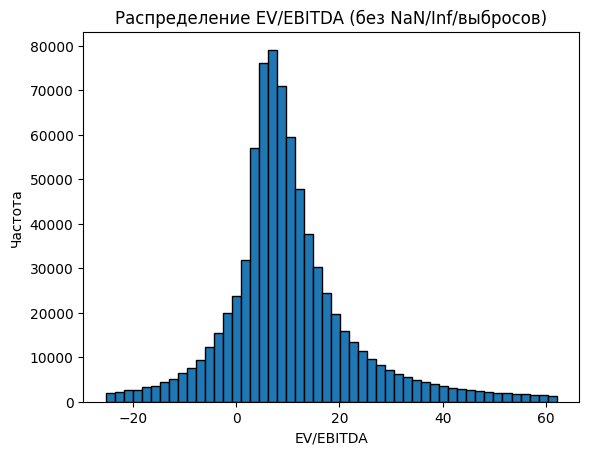

In [41]:
import matplotlib.pyplot as plt

# фильтруем null / nan / inf
clean = without_dups.filter(
    pl.col("ratio_ev_ebitda_ratio").is_not_null() 
    & pl.col("ratio_ev_ebitda_ratio").is_finite()
    & (pl.col("ratio_ev_ebitda_ratio") != 0)
)

# считаем границы по квантилям
low, high = clean.select([
    pl.col("ratio_ev_ebitda_ratio").quantile(0.05).alias("low"),
    pl.col("ratio_ev_ebitda_ratio").quantile(0.95).alias("high")
]).row(0)

# убираем выбросы
filtered = clean.filter(
    (pl.col("ratio_ev_ebitda_ratio") >= low) & (pl.col("ratio_ev_ebitda_ratio") <= high)
)

# в numpy
vals = filtered["ratio_ev_ebitda_ratio"].to_numpy()

# рисуем распределение
plt.hist(vals, bins=50, edgecolor="black")
plt.xlabel("EV/EBITDA")
plt.ylabel("Частота")
plt.title("Распределение EV/EBITDA (без NaN/Inf/выбросов)")
plt.show()

In [33]:
vals.min()

-5.264141948038288e+23

In [14]:
%pip install "vl-convert-python>=1.6.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.0/30.0 MB 18.7 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [230]:
dff = pl.DataFrame(
    {
        'name':['01','02','03','04'],
        "a": [1, 2, 3, 1],
        "b": ["x", "y", "z", "x"],
    }
)
dff.filter(
    pl.struct(['a','b']).is_duplicated()
)

name,a,b
str,i64,str
"""01""",1,"""x"""
"""04""",1,"""x"""


In [42]:
combined_df

NameError: name 'combined_df' is not defined

In [217]:
df_result[['ticker','exchange','date','ratio_market_capitalization']].write_csv('data/company_market_cap.csv')

In [220]:
df_result[[col for col in df_result.columns if 'egio' in col]]

bs_accounts_payable,bs_accounts_receivable,bs_accrued_expenses,bs_accrued_interest_payable,bs_accrued_interest_receivable,bs_additional_paid_in_capital,bs_allowance_for_loan_losses,bs_book_value_per_share,bs_buildings,bs_cash_cash_equivalents,bs_cash_equivalents,bs_cash_short_term_investments,bs_cash_growth,bs_common_stock,bs_comprehensive_income,bs_comprehensive_income_other,bs_construction_in_progress,bs_current_debt,bs_current_income_taxes_payable,bs_current_portion_of_leases,bs_current_portion_of_long_term_debt,bs_current_unearned_revenue,bs_debt_growth,bs_deferred_long_term_charges,bs_deferred_long_term_tax_assets,bs_deferred_policy_acquisition_cost,bs_deferred_revenue,bs_distributions_in_excess_of_earnings,bs_federal_home_loan_bank_debt_long_term,bs_filing_date_shares_outstanding,bs_goodwill,bs_goodwill_and_intangibles,bs_gross_loans,bs_institutional_deposits,bs_insurance_annuity_liabilities,bs_interest_bearing_deposits,bs_inventory,…,capex_revenue_ratio,fcff_calc,delta_nwc,fcff_revenue_ratio,fcff_calc_growth_1_years,fcff_calc_growth_2_years,pl_total_revenue_growth_2_years,pl_total_revenue_growth_1_years,pl_ebitda_growth_1_years,pl_ebitda_growth_2_years,pl_net_income_growth_1_years,pl_net_income_growth_2_years,cf_capital_expenditures_growth_1_years,cf_capital_expenditures_growth_2_years,country_damodaran,industry_damodaran,wacc,index_return_wow,index_weekly_vol_2q,index_vol_1y_annualized,index_weekly_vol_zscore,index_bubble_signal,index_return_qoq,index_return_yoy,index_return_3y_avg,index_return_3y,index_pct_from_3y_low,index_pct_to_3y_high,index_ma_8q,index_market_regime,index_rs_index,index_rs_zscore,index_momentum_accel,index_high_vol_regime,index_sharp_drop,index_new_high,index_seasonal_factor
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,i64,i64,i64,f64


In [1]:
import polars as pl

In [2]:
df = pl.read_parquet('data/ttm_extra_for_model.parquet')

In [4]:
df.filter(
    pl.col('year')>2022
).write_parquet('data/ttm_extra_for_model_.parquet')